In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from scipy.stats import wilcoxon
import utils
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu, wilcoxon
import mne
import matplotlib.pyplot as plt
from nilearn import plotting
from matplotlib import colors
import joblib

subjects = ['485', '486', '487', '488', '497', '498', '499', '505', '5107', '515', '520', '545']
controls = ['394', '396', '398', '402', '404', '405', '406', '415', '416', '417'] # noisy- '423', '426', '429'
stim_side = {'485': 'R', '486': 'L', '487': 'R', '488': 'L', '489': 'R', '496': 'R', '497': 'R', '498': 'L', '499': 'L', '505': 'L', '5101': 'R', '5107': 'R', '515': 'R', '520': 'R', '538': 'R', '541': 'L', '544':'R', '545': 'R'}
frontal_chans = [f"{side}{string}{number}" for string in ['OF', 'AC', 'AF', 'FA', 'IF-dAC', 'OPR'] for number in range(1, 9) for side in ['R', 'L']]
temporal_chans = [f"{string}{number}" for string in ['RA', 'LA', 'RAH', 'LAH', 'RMH', 'LMH', 'REC', 'LEC', 'RPHG', 'LPHG'] for number in range(1, 9)]
temporal_soz = ['485', '487', '488', '489', '496', '497', '498', '515', '520', '538', '541', '544']
frontal_soz = ['486', '499', '505', '5101', '5107', '545']
soz_side = {'485': 'R', '486': 'R', '487': 'L', '488': 'R', '489': 'L', '496': 'R', '497': 'B', '498': 'B', '499': 'R', '505': 'L', '5101': 'L', '5107': 'L', '515': 'R', '520': 'B', '538': 'L', '541': 'B', '544':'L', '545': 'L'}
temporal_stim = ['489', '496', '538']

1	485
2	486
3	487
4	488
5	497
6	498
7	499
8	505
9	510
10	515
11	520
12	545

subj
stim-type
485
M
486
S
487
S
488
S
497
M
498
S
499
M
505
M
510
M
515
S
520
S
545
S

## Figure 1

Processing p485 for electrode RPSMA4...
Found 68 electrodes for p485. Looking for RPSMA4...
Processing p486 for electrode LOF4...
Found 89 electrodes for p486. Looking for LOF4...
Processing p487 for electrode ROF5...
Found 71 electrodes for p487. Looking for ROF5...
Processing p488 for electrode LOF4...
Found 87 electrodes for p488. Looking for LOF4...
Processing p497 for electrode ROF7...
Found 77 electrodes for p497. Looking for ROF7...
Processing p498 for electrode LOF6...
Found 76 electrodes for p498. Looking for LOF6...
Processing p499 for electrode LOF6...
Found 66 electrodes for p499. Looking for LOF6...
Processing p505 for electrode LOF-AC7...
Found 75 electrodes for p505. Looking for LOF-AC7...
Processing p510 for electrode ROF6...
Found 96 electrodes for p510. Looking for ROF6...
Processing p515 for electrode ROF2...
Found 65 electrodes for p515. Looking for ROF2...
Processing p520 for electrode ROF5...
Found 64 electrodes for p520. Looking for ROF5...
Processing p545 for el

AttributeError: 'GlassBrainAxes' object has no attribute 'cmap'

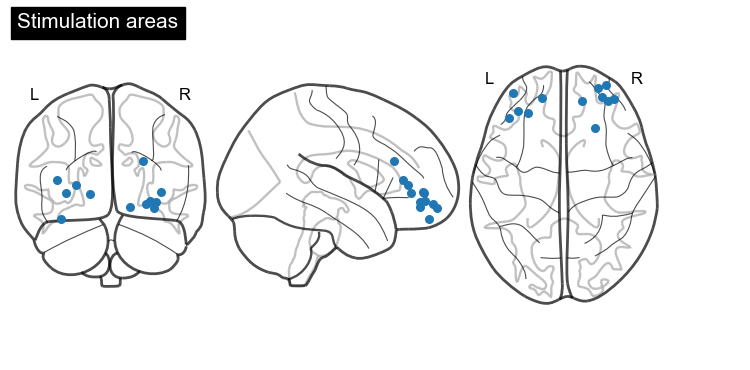

In [2]:
# --- שלב 1: הגדרת הפונקציות לקריאת וחישוב קואורדינטות ---

def read_coordinates_files(electrodes_name_file_path: str, electrodes_location_file_path: str):
    name_data = pd.read_csv(
        filepath_or_buffer=electrodes_name_file_path,
        delimiter=' ',
        usecols=[0],
        skiprows=2,
        header=None,
        dtype={0: str}
    )
    location_data = pd.read_csv(
        filepath_or_buffer=electrodes_location_file_path,
        delimiter=' ',
        skiprows=2,
        header=None,
        dtype={0: float, 1: float, 2: float}
    )

    name_to_coordinates = {}
    for names_row, location_row in zip(name_data.iterrows(), location_data.iterrows()):
        electrode_name = f'{names_row[1][0]}'
        name_to_coordinates[electrode_name] = (
            location_row[1][0],
            location_row[1][1],
            location_row[1][2]
        )
    return name_to_coordinates

def calculate_coordinates(avarage=True):
    # כאן הגדרתי גרסה פשוטה של הפונקציה שסורקת את התיקייה הכללית
    # הנתיב נלקח מהלוגיקה של הקוד הקודם שלך
    coordinates_dir = r'C:\repos\NirsLabProject\NirsLabProject\data\cordinates'
    
    _sum = {}
    count = {}
    
    # חיפוש קבצי שמות אלקטרודות
    files = [f for f in os.listdir(coordinates_dir) if f.endswith('.electrodeNames')]
    
    for file in files:
        loc_file_path = os.path.join(coordinates_dir, file)
        pial_file_path = os.path.join(coordinates_dir, file.replace('.electrodeNames', '.Pial'))
        
        if not os.path.exists(loc_file_path) or not os.path.exists(pial_file_path):
            continue
            
        electrode_name_to_location = read_coordinates_files(loc_file_path, pial_file_path)
        for electrode_name, location in electrode_name_to_location.items():
            if electrode_name not in _sum:
                _sum[electrode_name] = [0, 0, 0]
                count[electrode_name] = 0
            count[electrode_name] += 1
            _sum[electrode_name][0] += location[0]
            _sum[electrode_name][1] += location[1]
            _sum[electrode_name][2] += location[2]

    for electrode in _sum:
        _sum[electrode][0] /= count[electrode]
        _sum[electrode][1] /= count[electrode]
        _sum[electrode][2] /= count[electrode]

    return _sum

# --- שלב 2: הרצת התהליך על הנבדקים שלך ---
all_coords = calculate_coordinates(avarage=True)

# 1. הגדרת המילון - התאימי את שמות האלקטרודות לפי מה שמופיע אצלך בנתונים
subject_to_electrode = {
    'p485': 'RPSMA4',
    'p486': 'LOF4',
    'p487': 'ROF5',
    'p488': 'LOF4',
    # 'p489': 'RPHG5',
    # 'p496': 'RTOP6',
    'p497': 'ROF7',
    'p498': 'LOF6',
    'p499': 'LOF6',
    'p505': 'LOF-AC7',
    'p510': 'ROF6',
    'p515': 'ROF2',
    'p520': 'ROF5',
    # 'p538': 'RHSG4',
    'p545': 'ROF4'
}

# 2. פונקציה לשליפת המיקומים הספציפיים בלבד
def get_selected_electrodes_data(subject_map):
    coordinates_dir = r'C:\repos\NirsLabProject\NirsLabProject\data\cordinates'
    selected_data = []
    
    for subj, target_electrode in subject_map.items():
        loc_file = os.path.join(coordinates_dir, f'{subj[1:]}.electrodeNames')
        print(f"Processing {subj} for electrode {target_electrode}...")
        pial_file = os.path.join(coordinates_dir, f'{subj[1:]}.PIAL')
        
        if os.path.exists(loc_file):
            # טעינת כל האלקטרודות של הנבדק
            subj_coords = read_coordinates_files(loc_file, pial_file)
            print(f"Found {len(subj_coords)} electrodes for {subj}. Looking for {target_electrode}...")
            
            # בדיקה אם האלקטרודה המבוקשת קיימת עבורו
            if target_electrode in subj_coords:
                x, y, z = subj_coords[target_electrode]
                selected_data.append({
                    'subject': subj,
                    'electrode': target_electrode,
                    'x': x,
                    'y': y,
                    'z': z
                })
            else:
                print(f"Warning: Electrode {target_electrode} not found for subject {subj}")
    
    return pd.DataFrame(selected_data)

# 3. הרצה וויזואליזציה
df_selected = get_selected_electrodes_data(subject_to_electrode)

# חילוץ קואורדינטות
coords = df_selected[['x', 'y', 'z']].values

# ציור ב-Nilearn (תצוגה אורתוגונלית שמראה את המיקום המדויק בתוך המוח)
plotting.plot_connectome(
    adjacency_matrix=np.zeros((len(coords), len(coords))),
    node_coords=coords,
    node_color='tab:blue', 
    node_size=30,
    display_mode='ortho',
    title="Stimulation areas"
)

In [3]:
# 1. הגדרת צבע כחול עם שקיפות (Alpha = 0.5)
# אפשר לשנות את ה-0.5 לערך נמוך יותר לשקיפות גבוהה יותר
node_color_transparent = colors.to_rgba('tab:blue', alpha=0.8)

# 2. ציור ושמירה כקובץ PDF
plotting.plot_connectome(
    adjacency_matrix=np.zeros((len(coords), len(coords))),
    node_coords=coords,
    node_color=[node_color_transparent] * len(coords), # רשימת צבעים לכל נקודה
    node_size=30,
    display_mode='ortho',
    colorbar=False,           
    output_file='stimulation_areas_frontal.pdf' # שמירה כקובץ PDF וקטורי
)

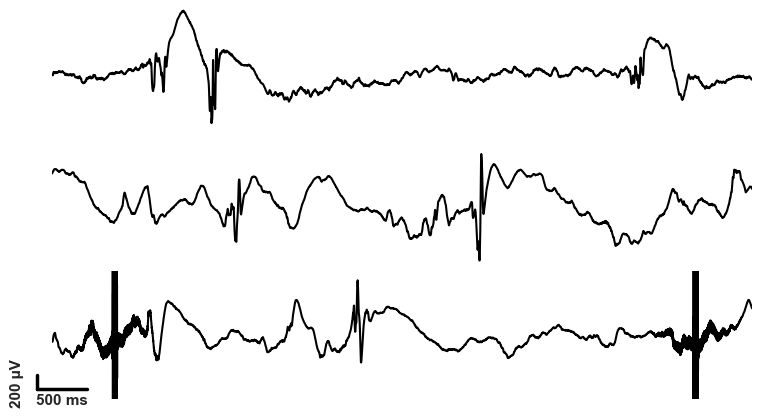

In [4]:
# --------------------
# Parameters
# --------------------
edf_path = r"D:\Maya\p505\P505_fixed.edf"
channel_name = "LEC1"
duration = 7  
amp_bar_val = 200 # µV
time_bar_sec = 0.5 

start_times = [
    1 * 3600 + 12 * 60 + 29.5,                                     
    1 * 3600 + 34 * 60 + 9.5,                 
    3 * 3600 + 11 * 60 + 9.5                  
]

# --------------------
# Load and Prepare Data
# --------------------
raw = mne.io.read_raw_edf(edf_path, verbose=False) # בלי preload
raw.pick([channel_name])

segments = []
for t_start in start_times:
    crop = raw.copy().crop(tmin=t_start, tmax=t_start + duration)
    data = crop.get_data()[0] * 1e6
    data = data - np.mean(data)
    segments.append(data)

# חישוב גבולות
y_min_data = min([np.min(s) for s in segments])
y_max_data = max([np.max(s) for s in segments])

y_range_total = 1900 
y_min_global = -y_range_total / 2
y_max_global = y_range_total / 2

# --------------------
# Plot
# --------------------
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 5), sharey=True)

for i, data in enumerate(segments):
    ax = axes[i]
    times = np.linspace(0, duration, len(data))
    ax.plot(times, data, color="black", linewidth=1.5)
    
    ax.set_ylim(y_min_global, y_max_global)
    ax.set_xlim(0, duration)
    ax.set_axis_off()

# --------------------
# Scale Bar "L" Shape
# --------------------
ax_bottom = axes[2]

corner_x = -0.15 
corner_y = -800 

# 1. הבר האנכי
ax_bottom.plot([corner_x, corner_x], [corner_y, corner_y + amp_bar_val],
               color="black", linewidth=2.5, clip_on=False)

# 2. הבר האופקי
ax_bottom.plot([corner_x, corner_x + time_bar_sec], [corner_y, corner_y],
               color="black", linewidth=2.5, clip_on=False)

# 3. כיתובים מעודכנים
# כיתוב למתח - מסובב ב-90 מעלות
ax_bottom.text(corner_x - 0.2, corner_y + (amp_bar_val / 2), f"{amp_bar_val} µV", 
               va="center", ha="center", fontsize=11, fontweight='bold', rotation=90)

# כיתוב לזמן - שונה ל-500 ms
ax_bottom.text(corner_x + (time_bar_sec / 2), corner_y - 60, "500 ms", 
               va="top", ha="center", fontsize=11, fontweight='bold')

plt.subplots_adjust(left=0.2, hspace=0.02, bottom=0.1) 
plt.show()

## Figure 2

In [192]:
data_stim = joblib.load(r"C:\repos\spikes_stim\paper\for_avg_props_raw_stim_frontal.pkl")
data_control = joblib.load(r"C:\repos\spikes_stim\paper\for_avg_props_raw_controls_10.pkl")
data_no_base = joblib.load(r"C:\repos\spikes_stim\paper\no_base_515_545.pkl")

In [14]:
def get_clean_matrix(raw_data_list, mode='baseline', max_points=30, threshold=1000):
    all_rows = []
    for subj_rates in raw_data_list:
        subj_rates = np.array(subj_rates)[:max_points]
        if len(subj_rates) < 2: continue
        
        if mode == 'baseline':
            b = subj_rates[0]
            if b == 0: continue
            vals = ((subj_rates - b) / b) * 100
        else: # consecutive
            prev = subj_rates[:-1]
            denom = np.where(prev == 0, 1e-9, prev)
            vals = np.insert(((subj_rates[1:] - prev) / denom) * 100, 0, 0)
        
        padded = np.full(max_points, np.nan)
        padded[:len(vals)] = vals
        all_rows.append(padded)
    
    df_wide = pd.DataFrame(all_rows)
    for col in df_wide.columns[1:]:
        q1, q3 = df_wide[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_wide.loc[(df_wide[col] < q1 - threshold*iqr) | (df_wide[col] > q3 + threshold*iqr), col] = np.nan
    return df_wide

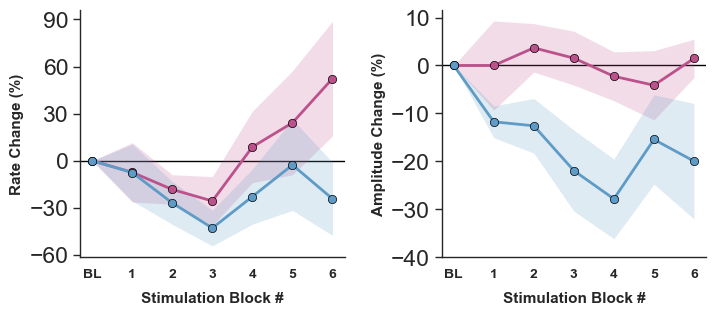

In [176]:
# --- 1. הכנת הנתונים (Rate & Amplitude) ---
# נתונים לגרף שמאל (Rate)
df_rate_stim = get_clean_matrix(data_stim['rates']['all'], mode='baseline', threshold=1000)
df_rate_ctrl = get_clean_matrix(data_control['rates']['all'], mode='baseline', threshold=1000)

# נתונים לגרף ימין (Amplitude)
df_amp_stim = get_clean_matrix(data_stim['relative_spike_amplitude']['all'], mode='baseline', threshold=1000)
df_amp_ctrl = get_clean_matrix(data_control['relative_spike_amplitude']['all'], mode='baseline', threshold=1000)

stim_idx = [1, 3, 5, 7, 9, 11]

def prepare_group_line(df, idx_list):
    mean_s = df.mean()
    sem_s = df.sem()
    y = np.array([0] + mean_s.iloc[idx_list].tolist())
    err = np.array([0] + sem_s.iloc[idx_list].tolist())
    return y, err

# הכנת הנתונים הסופיים
y_rate_stim, err_rate_stim = prepare_group_line(df_rate_stim, stim_idx)
y_rate_ctrl, err_rate_ctrl = prepare_group_line(df_rate_ctrl, stim_idx)

y_amp_stim, err_amp_stim = prepare_group_line(df_amp_stim, stim_idx)
y_amp_ctrl, err_amp_ctrl = prepare_group_line(df_amp_ctrl, stim_idx)

x_axis = np.arange(len(y_rate_stim))

# --- 2. פונקציית עזר לציור קו עם הצללה ---
def plot_shaded_line(ax, x, y, err, color, label, zorder):
    # צל
    ax.fill_between(x, y - err, y + err, color=color, alpha=0.2, linewidth=0, zorder=zorder-1)
    # קו ונקודות
    ax.plot(x, y, color=color, linewidth=2, marker='o', markersize=6, 
            markeredgecolor='black', markeredgewidth=0.5, zorder=zorder, label=label)

# --- 3. יצירת הגרף המאוחד (1 שורה, 2 עמודות) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3.5))

stim_blue = '#5e9bc7'
ctrl_pink = '#bb528c'

# גרף שמאל - Rate Change
plot_shaded_line(ax1, x_axis, y_rate_stim, err_rate_stim, stim_blue, 'Stim', zorder=5)
plot_shaded_line(ax1, x_axis, y_rate_ctrl, err_rate_ctrl, ctrl_pink, 'Control', zorder=4)

# גרף ימין - Amplitude Change
plot_shaded_line(ax2, x_axis, y_amp_stim, err_amp_stim, stim_blue, 'Stim', zorder=5)
plot_shaded_line(ax2, x_axis, y_amp_ctrl, err_amp_ctrl, ctrl_pink, 'Control', zorder=4)

# עיצוב משותף לשני הצירים
for ax in [ax1, ax2]:
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    
    # החזרת הטיקים: left=True מבטיח שהקווים הקטנים יופיעו על ציר ה-Y
    ax.tick_params(axis='both', which='major', direction='out', length=5, width=1, left=True)
    
    ax.set_xticks(x_axis)
    ax.set_xticklabels(['BL'] + [str(i) for i in range(1, len(x_axis))], fontsize=10, fontweight='bold')
    ax.set_xlabel('Stimulation Block #', fontsize=11, fontweight='bold', labelpad=8)

# הגדרות ספציפיות
ax1.set_ylabel('Rate Change (%)', fontsize=11, fontweight='bold')
ax1.set_yticks(np.arange(-60, 91, 30))

ax2.set_ylabel('Amplitude Change (%)', fontsize=11, fontweight='bold')
# הגדרת Ticks לאמפליטודה במידה ותרצי (למשל קפיצות של 20)
ax2.set_yticks(np.arange(-40, 20, 10)) 

plt.tight_layout()
plt.savefig('combined_rate_amp_cumulative_shade.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

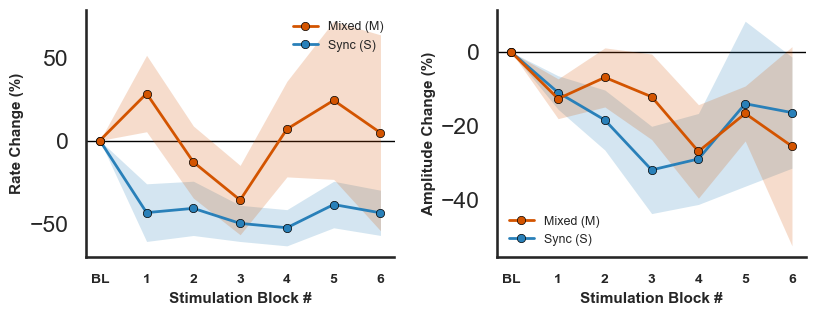

In [300]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. מיפוי לפי הסדר שסיפקת ---
# הרשימה: ['485', '486', '487', '488', '497', '498', '499', '505', '510', '520']
# M (Mixed): 485, 497, 499, 505, 510 -> אינדקסים 0, 4, 6, 7, 8
# S (Sync):  486, 487, 488, 498, 520 -> אינדקסים 1, 2, 3, 5, 9

m_indices = [0, 4, 6, 7, 8]  # Mixed
s_indices = [1, 2, 3, 5, 9]  # Sync

# --- 2. עיבוד הנתונים לקבוצות ---
df_rate_stim = get_clean_matrix(data_stim['rates']['all'], mode='baseline', threshold=1000)
df_amp_stim = get_clean_matrix(data_stim['relative_spike_amplitude']['all'], mode='baseline', threshold=1000)

y_rate_m, err_rate_m = prepare_group_line(df_rate_stim.iloc[m_indices], stim_idx)
y_rate_s, err_rate_s = prepare_group_line(df_rate_stim.iloc[s_indices], stim_idx)

y_amp_m, err_amp_m = prepare_group_line(df_amp_stim.iloc[m_indices], stim_idx)
y_amp_s, err_amp_s = prepare_group_line(df_amp_stim.iloc[s_indices], stim_idx)

x_axis = np.arange(len(y_rate_m))

# --- 3. ויזואליזציה ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.5, 3.5))

color_mixed = '#d35400' # כתום עמוק ל-Mixed
color_sync  = '#2980b9' # כחול ל-Sync

# גרף שמאל - Rate
plot_shaded_line(ax1, x_axis, y_rate_m, err_rate_m, color_mixed, 'Mixed (M)', zorder=5)
plot_shaded_line(ax1, x_axis, y_rate_s, err_rate_s, color_sync, 'Sync (S)', zorder=4)

# גרף ימין - Amplitude
plot_shaded_line(ax2, x_axis, y_amp_m, err_amp_m, color_mixed, 'Mixed (M)', zorder=5)
plot_shaded_line(ax2, x_axis, y_amp_s, err_amp_s, color_sync, 'Sync (S)', zorder=4)

# עיצוב
for ax in [ax1, ax2]:
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(x_axis)
    ax.set_xticklabels(['BL'] + [str(i) for i in range(1, len(x_axis))], fontsize=10, fontweight='bold')
    ax.set_xlabel('Stimulation Block #', fontsize=11, fontweight='bold')
    ax.legend(frameon=False, fontsize=9)

ax1.set_ylabel('Rate Change (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Amplitude Change (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

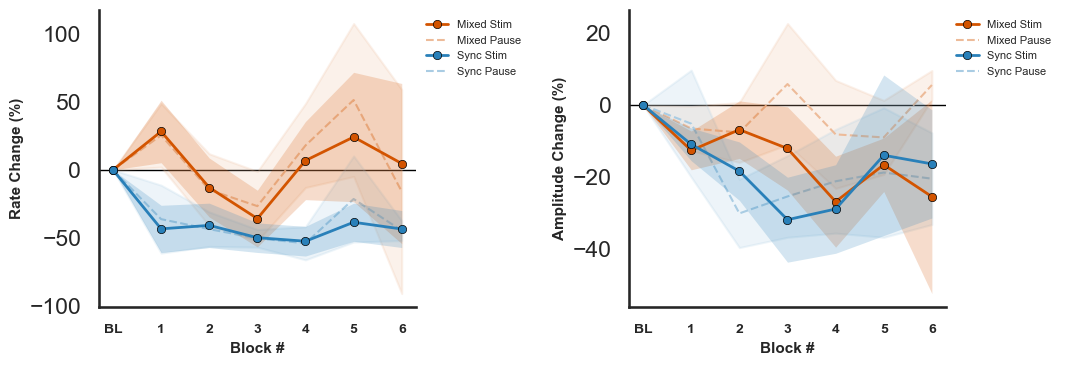

In [318]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. הגדרות ומיפוי ---
m_indices = [0, 4, 6, 7, 8]  
s_indices = [1, 2, 3, 5, 9]  
stim_idx = [1, 3, 5, 7, 9, 11]    
pause_idx = [2, 4, 6, 8, 10, 12]  

# --- 2. עיבוד נתונים ---
# Mixed
y_rate_m_stim, err_rate_m_stim = prepare_group_line(df_rate_stim.iloc[m_indices], stim_idx)
y_rate_m_pause, err_rate_m_pause = prepare_group_line(df_rate_stim.iloc[m_indices], pause_idx)

y_amp_m_stim, err_amp_m_stim = prepare_group_line(df_amp_stim.iloc[m_indices], stim_idx)
y_amp_m_pause, err_amp_m_pause = prepare_group_line(df_amp_stim.iloc[m_indices], pause_idx) # תיקון כאן

# Sync
y_rate_s_stim, err_rate_s_stim = prepare_group_line(df_rate_stim.iloc[s_indices], stim_idx)
y_rate_s_pause, err_rate_s_pause = prepare_group_line(df_rate_stim.iloc[s_indices], pause_idx)

y_amp_s_stim, err_amp_s_stim = prepare_group_line(df_amp_stim.iloc[s_indices], stim_idx)
y_amp_s_pause, err_amp_s_pause = prepare_group_line(df_amp_stim.iloc[s_indices], pause_idx) # תיקון כאן

x_axis = np.arange(len(y_rate_m_stim))

# --- 3. ויזואליזציה ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

color_m, color_m_light = '#d35400', '#edbb99'
color_s, color_s_light = '#2980b9', '#a9cce3'

def plot_group_data(ax, x, y_s, err_s, y_p, err_p, color, light_color, label):
    plot_shaded_line(ax, x, y_s, err_s, color, f'{label} Stim', zorder=5)
    ax.plot(x, y_p, color=light_color, linestyle='--', linewidth=1.5, label=f'{label} Pause', zorder=3)
    ax.fill_between(x, y_p - err_p, y_p + err_p, color=light_color, alpha=0.2, zorder=2)

# גרף שמאל - Rate Change
plot_group_data(ax1, x_axis, y_rate_m_stim, err_rate_m_stim, y_rate_m_pause, err_rate_m_pause, color_m, color_m_light, 'Mixed')
plot_group_data(ax1, x_axis, y_rate_s_stim, err_rate_s_stim, y_rate_s_pause, err_rate_s_pause, color_s, color_s_light, 'Sync')

# גרף ימין - Amplitude Change
plot_group_data(ax2, x_axis, y_amp_m_stim, err_amp_m_stim, y_amp_m_pause, err_amp_m_pause, color_m, color_m_light, 'Mixed')
plot_group_data(ax2, x_axis, y_amp_s_stim, err_amp_s_stim, y_amp_s_pause, err_amp_s_pause, color_s, color_s_light, 'Sync')

# עיצוב
for ax in [ax1, ax2]:
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(x_axis)
    ax.set_xticklabels(['BL'] + [str(i) for i in range(1, len(x_axis))], fontsize=10, fontweight='bold')
    ax.set_xlabel('Block #', fontsize=11, fontweight='bold')
    ax.legend(frameon=False, fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))

ax1.set_ylabel('Rate Change (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Amplitude Change (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

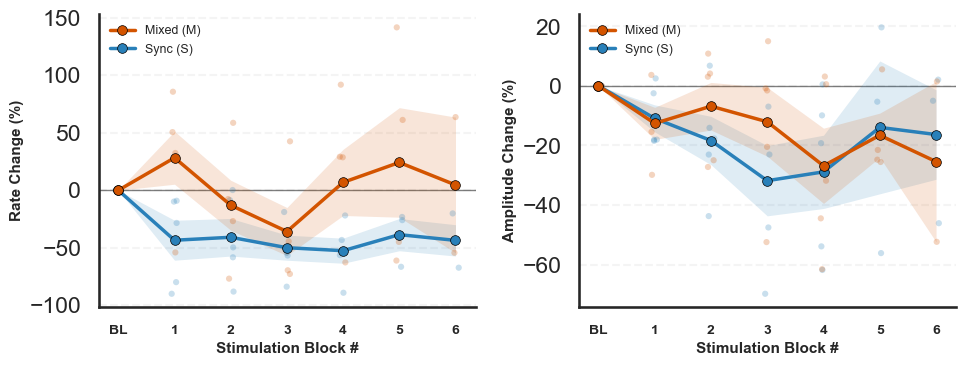

In [303]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# פונקציה מעודכנת שכוללת גם את הנקודות הגולמיות של הנבדקים
def plot_shaded_with_raw_points(ax, x, y, err, color, label, zorder, raw_df, idx_list):
    # 1. הצללה של ה-SEM
    ax.fill_between(x, y - err, y + err, color=color, alpha=0.15, linewidth=0, zorder=zorder-1)
    
    # 2. קו ממוצע עבה יותר
    ax.plot(x, y, color=color, linewidth=2.5, marker='o', markersize=7, 
            markeredgecolor='black', markeredgewidth=0.5, zorder=zorder+2, label=label)
    
    # 3. הוספת נקודות גולמיות לכל נבדק
    for i in range(len(raw_df)):
        # מחלצים את שורת הנבדק ומנרמלים ל-0 בבלוק הראשון
        subj_values = raw_df.iloc[i]
        subj_y = np.array([0] + subj_values.iloc[idx_list].tolist())
        
        # הוספת פיזור אופקי קטן (Jitter) כדי למנוע חפיפה
        jitter = np.random.uniform(-0.06, 0.06, size=len(x))
        ax.scatter(x + jitter, subj_y, color=color, alpha=0.25, s=20, zorder=zorder+1, edgecolors='none')

# --- יצירת הגרף המאוחד ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

color_mixed = '#d35400' 
color_sync  = '#2980b9' 

# גרף שמאל - Rate Change
plot_shaded_with_raw_points(ax1, x_axis, y_rate_m, err_rate_m, color_mixed, 'Mixed (M)', 5, df_rate_m, stim_idx)
plot_shaded_with_raw_points(ax1, x_axis, y_rate_s, err_rate_s, color_sync, 'Sync (S)', 4, df_rate_s, stim_idx)

# גרף ימין - Amplitude Change
plot_shaded_with_raw_points(ax2, x_axis, y_amp_m, err_amp_m, color_mixed, 'Mixed (M)', 5, df_amp_m, stim_idx)
plot_shaded_with_raw_points(ax2, x_axis, y_amp_s, err_amp_s, color_sync, 'Sync (S)', 4, df_amp_s, stim_idx)

# עיצוב משותף
for ax in [ax1, ax2]:
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=1, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(x_axis)
    ax.set_xticklabels(['BL'] + [str(i) for i in range(1, len(x_axis))], fontsize=10, fontweight='bold')
    ax.set_xlabel('Stimulation Block #', fontsize=11, fontweight='bold')
    ax.legend(frameon=False, fontsize=9)
    # הוספת גריד עדין לרוחב כדי להקל על קריאת הערכים
    ax.grid(axis='y', linestyle='--', alpha=0.2)

ax1.set_ylabel('Rate Change (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Amplitude Change (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

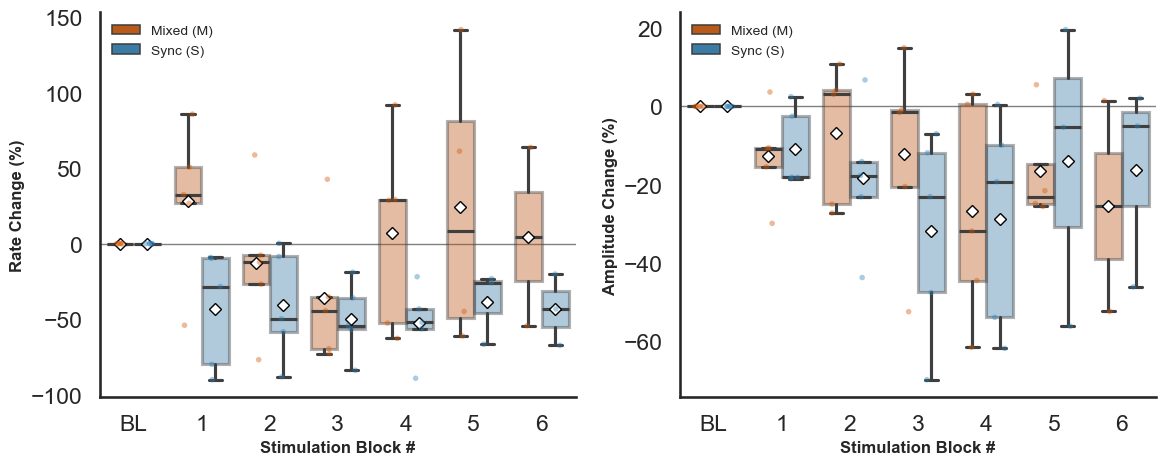

In [302]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. הכנת הנתונים לפורמט "Long" שמתאים לבוקספלוט ---
def melt_for_boxplot(df, idx_list, label):
    # מוסיפים עמודת בייסליין של 0
    plot_df = df.iloc[:, idx_list].copy()
    plot_df.insert(0, 'BL', 0)
    
    # הופכים מפורמט רחב לארוך (Melt)
    melted = plot_df.melt(var_name='Block', value_name='Change')
    melted['Group'] = label
    
    # עדכון שמות הבלוקים ל-1, 2, 3...
    block_map = {old: str(i) for i, old in enumerate(plot_df.columns)}
    block_map[plot_df.columns[0]] = 'BL'
    melted['Block'] = melted['Block'].map(block_map)
    
    return melted

# הכנת הנתונים לכל קבוצה (M ו-S)
df_rate_long = pd.concat([
    melt_for_boxplot(df_rate_m, stim_idx, 'Mixed (M)'),
    melt_for_boxplot(df_rate_s, stim_idx, 'Sync (S)')
])

df_amp_long = pd.concat([
    melt_for_boxplot(df_amp_m, stim_idx, 'Mixed (M)'),
    melt_for_boxplot(df_amp_s, stim_idx, 'Sync (S)')
])

# --- 2. ויזואליזציה ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

color_mixed = '#d35400' 
color_sync  = '#2980b9'
palette = {'Mixed (M)': color_mixed, 'Sync (S)': color_sync}

# הגדרות בוקספלוט
box_props = {'showmeans': True, 'meanprops': {"marker":"D","markerfacecolor":"white", "markeredgecolor":"black", "markersize":6},
             'boxprops': {'alpha': 0.4}, 'flierprops': {'marker': ''}} # הסתרת אאוטליירים כפולים

# גרף שמאל - Rate Change
sns.boxplot(data=df_rate_long, x='Block', y='Change', hue='Group', ax=ax1, palette=palette, **box_props)
sns.stripplot(data=df_rate_long, x='Block', y='Change', hue='Group', ax=ax1, palette=palette, 
              dodge=True, alpha=0.4, s=4, jitter=0.15)

# גרף ימין - Amplitude Change
sns.boxplot(data=df_amp_long, x='Block', y='Change', hue='Group', ax=ax2, palette=palette, **box_props)
sns.stripplot(data=df_amp_long, x='Block', y='Change', hue='Group', ax=ax2, palette=palette, 
              dodge=True, alpha=0.4, s=4, jitter=0.15)

# עיצוב משותף
for ax in [ax1, ax2]:
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=0, alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold')
    
    # סידור ה-Legend (כדי שלא יופיע פעמיים בגלל ה-stripplot)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], frameon=False, fontsize=10)

ax1.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Amplitude Change (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

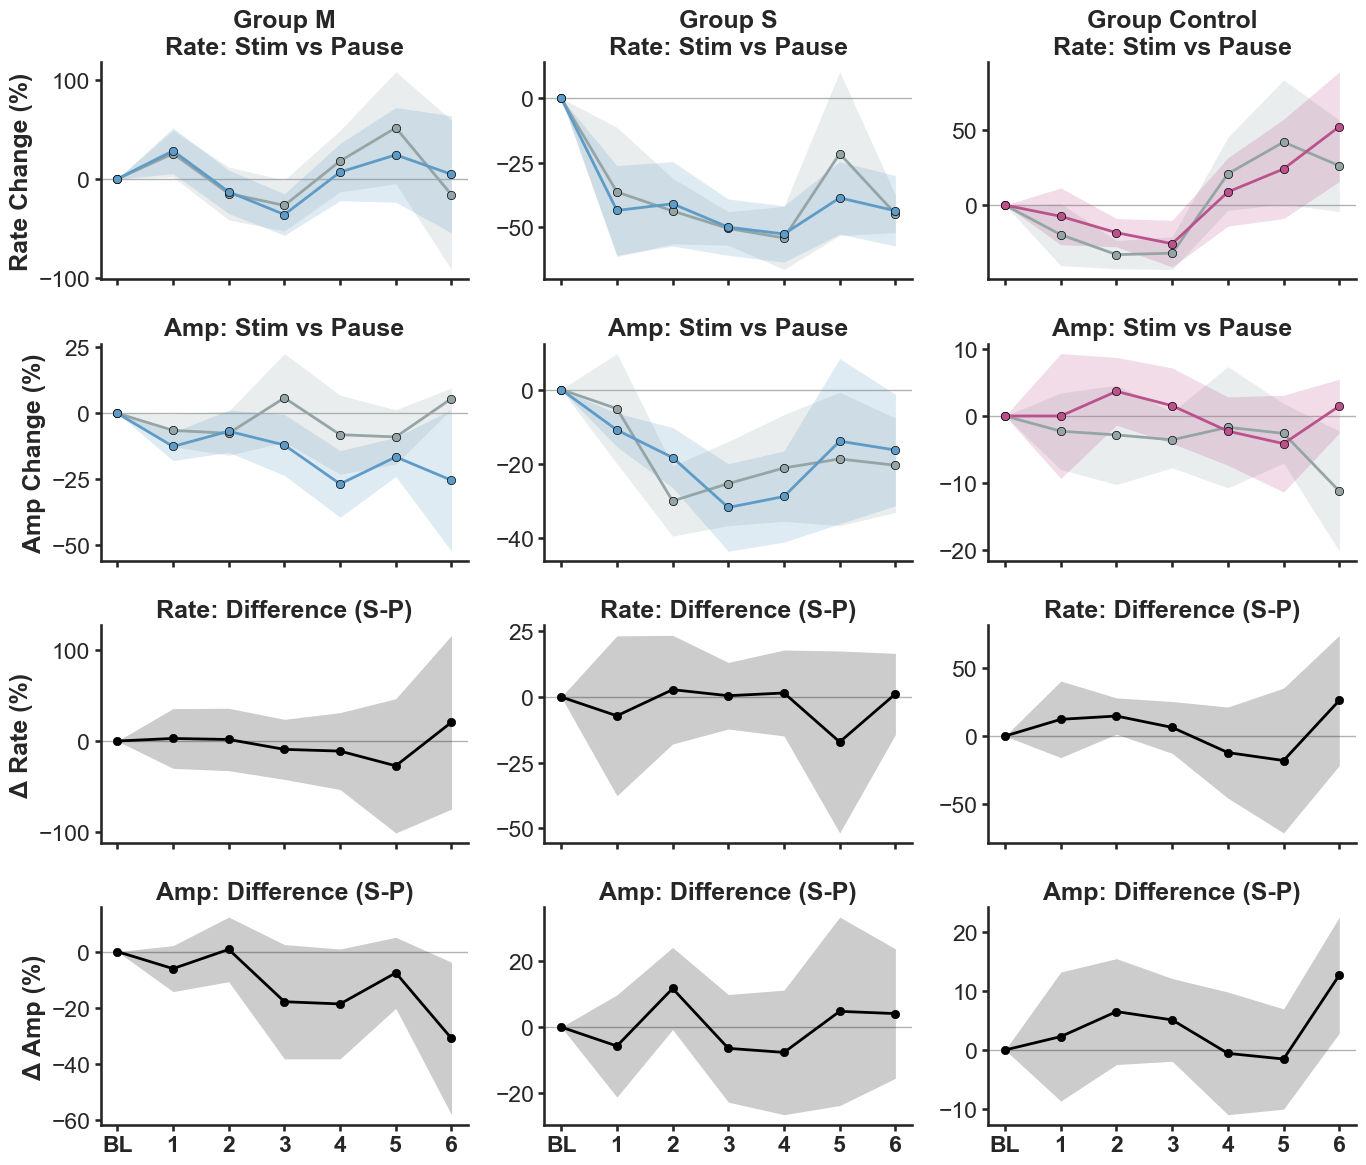

In [321]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. אינדקסים ושיוך נבדקים ---
m_indices = [0, 4, 6, 7, 8]  # Mixed
s_indices = [1, 2, 3, 5, 9]  # Sync
stim_idx = [1, 3, 5, 7, 9, 11]
pause_idx = [2, 4, 6, 8, 10, 12]

# --- 2. הכנת המטריצות הגולמיות ---
# מחקר (Stim)
df_rate_stim = get_clean_matrix(data_stim['rates']['all'], mode='baseline', threshold=1000)
df_amp_stim = get_clean_matrix(data_stim['relative_spike_amplitude']['all'], mode='baseline', threshold=1000)
# ביקורת (Control)
df_rate_ctrl = get_clean_matrix(data_control['rates']['all'], mode='baseline', threshold=1000)
df_amp_ctrl = get_clean_matrix(data_control['relative_spike_amplitude']['all'], mode='baseline', threshold=1000)

# --- 3. הכנת הנתונים לכל תא בגרף ---
results = {}
# לוגיקה לעיבוד: עבור M ו-S משתמשים ב-df_rate_stim, עבור Control ב-df_rate_ctrl
group_map = {
    'M': (df_rate_stim.iloc[m_indices], df_amp_stim.iloc[m_indices]),
    'S': (df_rate_stim.iloc[s_indices], df_amp_stim.iloc[s_indices]),
    'Control': (df_rate_ctrl, df_amp_ctrl)
}

for g_name, (df_r, df_a) in group_map.items():
    # Rate
    results[f'{g_name}_Rate_s'] = prepare_group_line(df_r, stim_idx)
    results[f'{g_name}_Rate_p'] = prepare_group_line(df_r, pause_idx)
    # Amp
    results[f'{g_name}_Amp_s'] = prepare_group_line(df_a, stim_idx)
    results[f'{g_name}_Amp_p'] = prepare_group_line(df_a, pause_idx)
    
    # חישוב הפרשים (Diff = Stim - Pause)
    for metric in ['Rate', 'Amp']:
        y_s, e_s = results[f'{g_name}_{metric}_s']
        y_p, e_p = results[f'{g_name}_{metric}_p']
        results[f'{g_name}_{metric}_diff'] = (y_s - y_p, np.sqrt(e_s**2 + e_p**2))

# --- 4. ויזואליזציה ---
fig, axes = plt.subplots(4, 3, figsize=(14, 12), sharex=True)

# צבעים לפי הבקשה
blue_stim = '#5e9bc7'
pink_ctrl = '#bb528c'
grey_pause = '#95a5a6'

group_cols = ['M', 'S', 'Control']

for col, g_name in enumerate(group_cols):
    # קביעת צבע הגירוי לפי הקבוצה
    line_color = pink_ctrl if g_name == 'Control' else blue_stim
    
    # שורה 1: Rate (Stim vs Pause)
    ax = axes[0, col]
    y_s, e_s = results[f'{g_name}_Rate_s']
    y_p, e_p = results[f'{g_name}_Rate_p']
    plot_shaded_line(ax, np.arange(len(y_s)), y_s, e_s, line_color, 'Stim', zorder=5)
    plot_shaded_line(ax, np.arange(len(y_p)), y_p, e_p, grey_pause, 'Pause', zorder=4)
    ax.set_title(f'Group {g_name}\nRate: Stim vs Pause', fontweight='bold')

    # שורה 2: Amp (Stim vs Pause)
    ax = axes[1, col]
    y_s, e_s = results[f'{g_name}_Amp_s']
    y_p, e_p = results[f'{g_name}_Amp_p']
    plot_shaded_line(ax, np.arange(len(y_s)), y_s, e_s, line_color, 'Stim', zorder=5)
    plot_shaded_line(ax, np.arange(len(y_p)), y_p, e_p, grey_pause, 'Pause', zorder=4)
    ax.set_title(f'Amp: Stim vs Pause', fontweight='bold')

    # שורה 3: Rate Difference
    ax = axes[2, col]
    y_d, e_d = results[f'{g_name}_Rate_diff']
    plot_shaded_line(ax, np.arange(len(y_d)), y_d, e_d, 'black', 'Δ Rate', zorder=5)
    ax.set_title(f'Rate: Difference (S-P)', fontweight='bold')

    # שורה 4: Amp Difference
    ax = axes[3, col]
    y_d, e_d = results[f'{g_name}_Amp_diff']
    plot_shaded_line(ax, np.arange(len(y_d)), y_d, e_d, 'black', 'Δ Amp', zorder=5)
    ax.set_title(f'Amp: Difference (S-P)', fontweight='bold')

# --- עיצוב גלובלי ---
for ax in axes.flat:
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(np.arange(len(y_s)))
    ax.set_xticklabels(['BL'] + [str(i) for i in range(1, len(y_s))], fontweight='bold')
    ax.tick_params(left=True, bottom=True, direction='out', length=4)

# תוויות ציר Y לשורה הראשונה בכל סוג
axes[0, 0].set_ylabel('Rate Change (%)', fontweight='bold')
axes[1, 0].set_ylabel('Amp Change (%)', fontweight='bold')
axes[2, 0].set_ylabel('Δ Rate (%)', fontweight='bold')
axes[3, 0].set_ylabel('Δ Amp (%)', fontweight='bold')

plt.tight_layout()
plt.show()

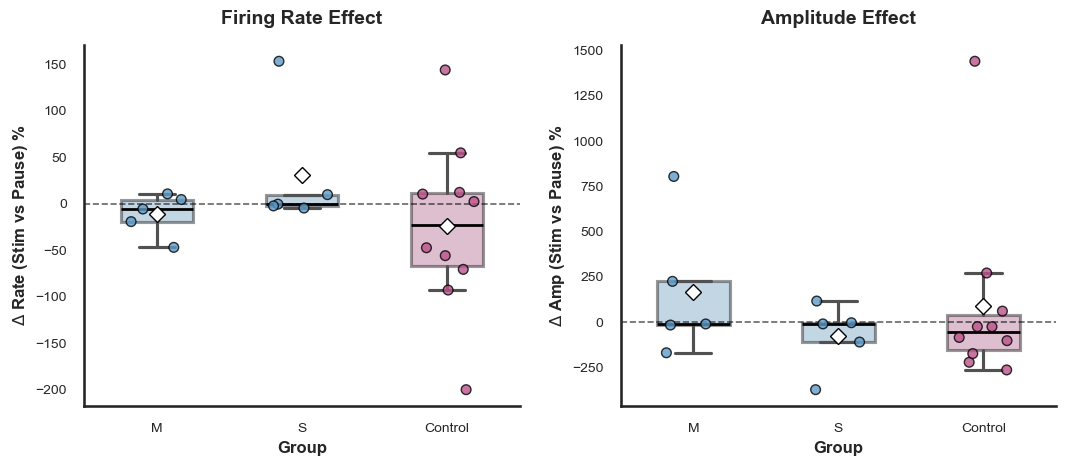

In [322]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compute_subject_effect(df_m):
    """
    מחשב ערך אחוז שינוי בודד לכל נבדק:
    ((ממוצע כל הגירויים) - (ממוצע כל ההפסקות)) / (ממוצע כל ההפסקות) * 100
    """
    # זיהוי עמודות גירוי (אי-זוגיות) ועמודות הפסקה (זוגיות, ללא עמודה 0)
    all_cols = np.arange(df_m.shape[1])
    stim_cols = [c for c in all_cols if c % 2 != 0]
    pause_cols = [c for c in all_cols if c % 2 == 0 and c != 0]
    
    # חישוב ממוצע לכל שורה (נבדק)
    stim_means = df_m.iloc[:, stim_cols].mean(axis=1)
    pause_means = df_m.iloc[:, pause_cols].mean(axis=1)
    
    # חישוב אחוז השינוי
    pct_change = ((stim_means - pause_means) / pause_means) * 100
    return pct_change.dropna()

# 1. הכנת נתונים לכל קבוצה ומדד
groups_data = {
    'M': (df_rate_stim.iloc[m_indices], df_amp_stim.iloc[m_indices]),
    'S': (df_rate_stim.iloc[s_indices], df_amp_stim.iloc[s_indices]),
    'Control': (df_rate_ctrl, df_amp_ctrl)
}

plot_data_rate = []
plot_data_amp = []

for g_name, (df_r, df_a) in groups_data.items():
    # Rate
    rate_effects = compute_subject_effect(df_r)
    for val in rate_effects:
        plot_data_rate.append({'Group': g_name, 'Pct_Change': val})
    
    # Amp
    amp_effects = compute_subject_effect(df_a)
    for val in amp_effects:
        plot_data_amp.append({'Group': g_name, 'Pct_Change': val})

df_plot_rate = pd.DataFrame(plot_data_rate)
df_plot_amp = pd.DataFrame(plot_data_amp)

# 2. ויזואליזציה
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

# הגדרת צבעים (כחול לקבוצות המחקר, ורוד לקונטרול)
palette = {'M': '#5e9bc7', 'S': '#5e9bc7', 'Control': '#bb528c'}
order = ['M', 'S', 'Control']

def draw_group_boxplot(ax, df, title, ylabel):
    # קו אפס להשוואה
    ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6, zorder=1)
    
    # בוקספלוט
    sns.boxplot(data=df, x='Group', y='Pct_Change', order=order, palette=palette, 
                ax=ax, width=0.5, showmeans=True,
                meanprops={'marker':'D','markerfacecolor':'white','markeredgecolor':'black','markersize':8},
                boxprops=dict(alpha=0.4, edgecolor='black'),
                medianprops=dict(color='black', linewidth=2),
                showfliers=False)
    
    # נקודות נבדקים (Stripplot)
    sns.stripplot(data=df, x='Group', y='Pct_Change', order=order, palette=palette,
                  ax=ax, size=7, alpha=0.8, jitter=0.2, linewidth=1, edgecolor='black')
    
    ax.set_title(title, fontweight='bold', fontsize=14, pad=15)
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=12)
    ax.set_xlabel('Group', fontweight='bold', fontsize=12)
    
    # עיצוב צירים
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=10)

# ציור שני המדדים
draw_group_boxplot(ax1, df_plot_rate, 'Firing Rate Effect', '$\Delta$ Rate (Stim vs Pause) %')
draw_group_boxplot(ax2, df_plot_amp, 'Amplitude Effect', '$\Delta$ Amp (Stim vs Pause) %')

plt.tight_layout()
plt.show()

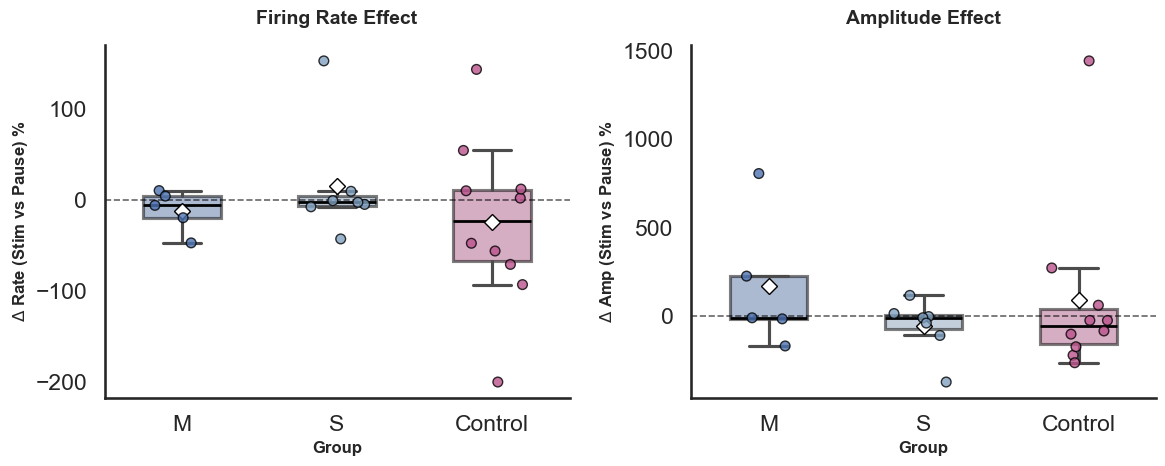

In [323]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compute_subject_effect(df_m):
    """
    מחשב ערך אחוז שינוי בודד לכל נבדק:
    ((ממוצע כל הגירויים) - (ממוצע כל ההפסקות)) / (ממוצע כל ההפסקות) * 100
    """
    all_cols = np.arange(df_m.shape[1])
    stim_cols = [c for c in all_cols if c % 2 != 0]
    pause_cols = [c for c in all_cols if c % 2 == 0 and c != 0]
    
    stim_means = df_m.iloc[:, stim_cols].mean(axis=1)
    pause_means = df_m.iloc[:, pause_cols].mean(axis=1)
    
    pct_change = ((stim_means - pause_means) / pause_means) * 100
    return pct_change.dropna()

# --- 1. הכנת הנתונים כולל הנבדקים החדשים מתוך data_no_base ---

# שליפת המטריצות עבור הנבדקים החדשים (קבוצה S)
df_rate_no_base = get_clean_matrix(data_no_base['rates']['all'], mode='baseline', threshold=1000)
df_amp_no_base = get_clean_matrix(data_no_base['relative_spike_amplitude']['all'], mode='baseline', threshold=1000)

# איחוד הנתונים של קבוצה S (המקוריים מתוך data_stim + החדשים מתוך data_no_base)
df_rate_s_combined = pd.concat([df_rate_stim.iloc[s_indices], df_rate_no_base])
df_amp_s_combined = pd.concat([df_amp_stim.iloc[s_indices], df_amp_no_base])

# בניית המילון לעיבוד עם החלוקה החדשה
groups_data = {
    'M': (df_rate_stim.iloc[m_indices], df_amp_stim.iloc[m_indices]),
    'S': (df_rate_s_combined, df_amp_s_combined),
    'Control': (df_rate_ctrl, df_amp_ctrl)
}

plot_data_rate = []
plot_data_amp = []

for g_name, (df_r, df_a) in groups_data.items():
    rate_effects = compute_subject_effect(df_r)
    for val in rate_effects:
        plot_data_rate.append({'Group': g_name, 'Pct_Change': val})
    
    amp_effects = compute_subject_effect(df_a)
    for val in amp_effects:
        plot_data_amp.append({'Group': g_name, 'Pct_Change': val})

df_plot_rate = pd.DataFrame(plot_data_rate)
df_plot_amp = pd.DataFrame(plot_data_amp)

# --- 2. ויזואליזציה ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# פלטה: כחול עמוק (M), כחול פלדה (S), ורוד עמוק (Control)
palette = {'M': '#4C72B0', 'S': '#81A1C1', 'Control': '#bb528c'}
order = ['M', 'S', 'Control']

def draw_group_boxplot(ax, df, title, ylabel):
    ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6, zorder=1)
    
    sns.boxplot(data=df, x='Group', y='Pct_Change', order=order, palette=palette, 
                ax=ax, width=0.5, showmeans=True,
                meanprops={'marker':'D','markerfacecolor':'white','markeredgecolor':'black','markersize':8},
                boxprops=dict(alpha=0.5, edgecolor='black'),
                medianprops=dict(color='black', linewidth=2),
                showfliers=False)
    
    sns.stripplot(data=df, x='Group', y='Pct_Change', order=order, palette=palette,
                  ax=ax, size=7, alpha=0.8, jitter=0.2, linewidth=1, edgecolor='black')
    
    ax.set_title(title, fontweight='bold', fontsize=14, pad=15)
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=12)
    ax.set_xlabel('Group', fontweight='bold', fontsize=12)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

draw_group_boxplot(ax1, df_plot_rate, 'Firing Rate Effect', '$\Delta$ Rate (Stim vs Pause) %')
draw_group_boxplot(ax2, df_plot_amp, 'Amplitude Effect', '$\Delta$ Amp (Stim vs Pause) %')

plt.tight_layout()
plt.show()

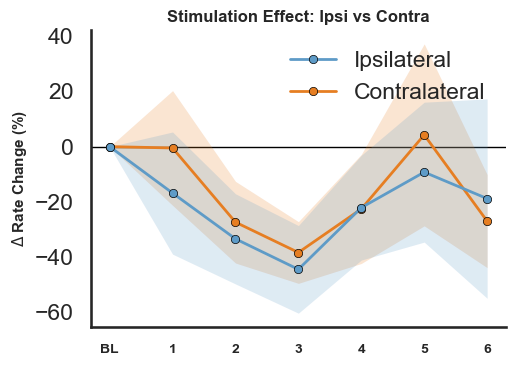

In [181]:
# 1. הכנת המשתנים (חילוץ הנתונים מהמטריצות)
# איפסי
y_ipsi_rate, err_ipsi_rate = prepare_group_line(
    get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=1000), stim_idx)
# קונטרה
y_contra_rate, err_contra_rate = prepare_group_line(
    get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=1000), stim_idx)

# 2. יצירת הגרף
fig, ax = plt.subplots(figsize=(5.5, 4))

# שימוש בפונקציית plot_shaded_line שהגדרנו קודם
plot_shaded_line(ax, x_axis, y_ipsi_rate, err_ipsi_rate, '#5e9bc7', 'Ipsilateral', zorder=5)
plot_shaded_line(ax, x_axis, y_contra_rate, err_contra_rate, '#e67e22', 'Contralateral', zorder=4)

# עיצוב הציר
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=1)
ax.set_ylabel(r'$\Delta$ Rate Change (%)', fontsize=11, fontweight='bold')
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL'] + [str(i) for i in range(1, len(x_axis))], fontsize=10, fontweight='bold')
ax.set_title('Stimulation Effect: Ipsi vs Contra', fontsize=12, fontweight='bold')
ax.legend(frameon=False)

for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

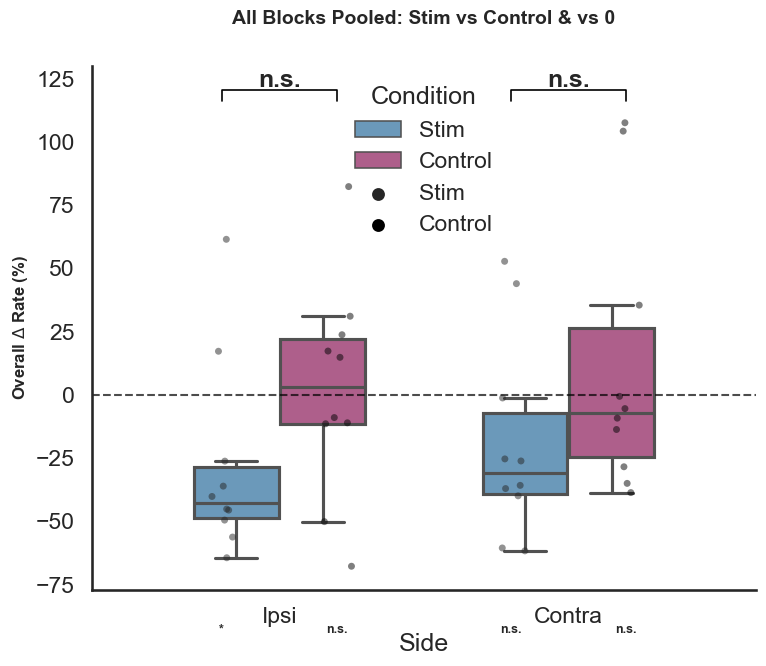

In [199]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# 1. חילוץ ה-DataFrames (כל הבלוקים כלולים)
df_si = get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=1000)
df_sc = get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=1000)
df_ci = get_clean_matrix(data_control['rates']['ipsi'], mode='baseline', threshold=1000)
df_cc = get_clean_matrix(data_control['rates']['contra'], mode='baseline', threshold=1000)

# 2. חישוב ממוצע לכל נבדק לאורך כל הבלוקים הזמינים
v_si = df_si.mean(axis=1).dropna().values
v_sc = df_sc.mean(axis=1).dropna().values
v_ci = df_ci.mean(axis=1).dropna().values
v_cc = df_cc.mean(axis=1).dropna().values

# 3. ארגון הנתונים לציור
plot_list = []
for v in v_si: plot_list.append({'Value': v, 'Side': 'Ipsi', 'Condition': 'Stim'})
for v in v_sc: plot_list.append({'Value': v, 'Side': 'Contra', 'Condition': 'Stim'})
for v in v_ci: plot_list.append({'Value': v, 'Side': 'Ipsi', 'Condition': 'Control'})
for v in v_cc: plot_list.append({'Value': v, 'Side': 'Contra', 'Condition': 'Control'})
df_plot = pd.DataFrame(plot_list)

# 4. פונקציית עזר לכוכביות
def get_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'n.s.'

# 5. יצירת הגרף
fig, ax = plt.subplots(figsize=(8, 7))
colors = {'Stim': '#5e9bc7', 'Control': '#bb528c'}

sns.boxplot(x='Side', y='Value', hue='Condition', data=df_plot, palette=colors, ax=ax, width=0.6, fliersize=0)
sns.stripplot(x='Side', y='Value', hue='Condition', data=df_plot, color='black', alpha=0.5, dodge=True, ax=ax)

ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# --- הוספת סטטיסטיקה ---
y_max = df_plot['Value'].max()
y_min = df_plot['Value'].min()
h = abs(y_max - y_min) * 0.05

# א. מבחן בין Stim ל-Control (למעלה)
for i, side in enumerate(['Ipsi', 'Contra']):
    s_vals = df_plot[(df_plot['Side'] == side) & (df_plot['Condition'] == 'Stim')]['Value']
    c_vals = df_plot[(df_plot['Side'] == side) & (df_plot['Condition'] == 'Control')]['Value']
    
    _, p_comp = stats.ttest_ind(s_vals, c_vals)
    
    # ציור קו ההשוואה
    ax.plot([i-0.2, i-0.2, i+0.2, i+0.2], [y_max + h, y_max + 1.5*h, y_max + 1.5*h, y_max + h], color='black', lw=1.2)
    ax.text(i, y_max + 1.6*h, get_stars(p_comp), ha='center', fontweight='bold')

# ב. מבחן מול 0 (למטה, מתחת לכל בוקס)
# סדר הבוקסים ב-hue הוא Stim ואז Control
for i, side in enumerate(['Ipsi', 'Contra']):
    for j, (cond, vals) in enumerate([('Stim', [v_si, v_sc][i]), ('Control', [v_ci, v_cc][i])]):
        _, p_vs_0 = stats.ttest_1samp(vals, 0)
        x_pos = i - 0.2 if j == 0 else i + 0.2
        ax.text(x_pos, y_min - 3*h, get_stars(p_vs_0), ha='center', fontsize=9, fontweight='bold')

# עיצוב סופי
ax.set_ylabel(r'Overall $\Delta$ Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('All Blocks Pooled: Stim vs Control & vs 0', fontsize=14, fontweight='bold', pad=30)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
ax.legend(title='Condition', frameon=False)

plt.tight_layout()
plt.show()

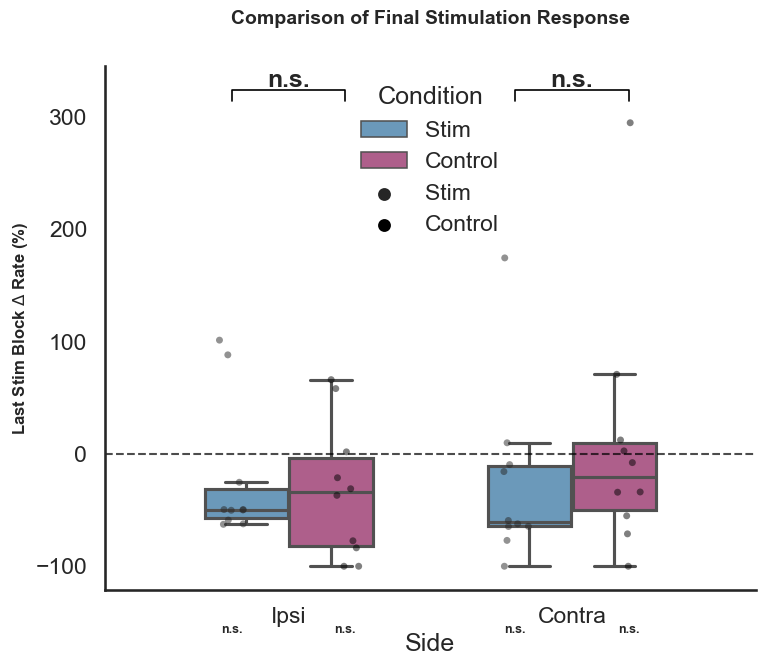

In [206]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# --- 1. פונקציית עזר לשליפת בלוק הגירוי האחרון לכל נבדק ---
def get_last_stim_value(df):
    """
    עוברת על כל שורה ושולפת את הערך מהעמודה האי-זוגית האחרונה (גירוי) שאינה NaN.
    """
    last_stim_vals = []
    # אינדקסים של בלוקי גירוי הם 1, 3, 5, 7...
    stim_cols = [c for c in range(1, df.shape[1], 2)]
    
    for _, row in df.iterrows():
        # סינון עמודות הגירוי שיש בהן ערך לנבדק זה
        valid_stim_data = row[stim_cols].dropna()
        if not valid_stim_data.empty:
            # לקיחת הערך האחרון ברשימה
            last_stim_vals.append(valid_stim_data.values[-1])
            
    return np.array(last_stim_vals)

# --- 2. חילוץ ה-DataFrames ---
df_si = get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=1000)
df_sc = get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=1000)
df_ci = get_clean_matrix(data_control['rates']['ipsi'], mode='baseline', threshold=1000)
df_cc = get_clean_matrix(data_control['rates']['contra'], mode='baseline', threshold=1000)

# --- 3. שליפת הערך של הגירוי האחרון בלבד לכל נבדק ---
v_si = get_last_stim_value(df_si)
v_sc = get_last_stim_value(df_sc)
v_ci = get_last_stim_value(df_ci)
v_cc = get_last_stim_value(df_cc)

# --- 4. ארגון הנתונים לציור ---
plot_list = []
for v in v_si: plot_list.append({'Value': v, 'Side': 'Ipsi', 'Condition': 'Stim'})
for v in v_sc: plot_list.append({'Value': v, 'Side': 'Contra', 'Condition': 'Stim'})
for v in v_ci: plot_list.append({'Value': v, 'Side': 'Ipsi', 'Condition': 'Control'})
for v in v_cc: plot_list.append({'Value': v, 'Side': 'Contra', 'Condition': 'Control'})
df_plot = pd.DataFrame(plot_list)

# --- 5. יצירת הגרף והסטטיסטיקה ---
fig, ax = plt.subplots(figsize=(8, 7))
colors = {'Stim': '#5e9bc7', 'Control': '#bb528c'}

sns.boxplot(x='Side', y='Value', hue='Condition', data=df_plot, palette=colors, ax=ax, width=0.6, fliersize=0)
sns.stripplot(x='Side', y='Value', hue='Condition', data=df_plot, color='black', alpha=0.5, dodge=True, ax=ax)

ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# סטטיסטיקה
y_max = df_plot['Value'].max()
y_min = df_plot['Value'].min()
h = abs(y_max - y_min) * 0.05

def get_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'n.s.'

for i, side in enumerate(['Ipsi', 'Contra']):
    # השוואה בין Stim ל-Control
    s_vals = df_plot[(df_plot['Side'] == side) & (df_plot['Condition'] == 'Stim')]['Value']
    c_vals = df_plot[(df_plot['Side'] == side) & (df_plot['Condition'] == 'Control')]['Value']
    
    if len(s_vals) > 1 and len(c_vals) > 1:
        _, p_comp = stats.ttest_ind(s_vals, c_vals)
        ax.plot([i-0.2, i-0.2, i+0.2, i+0.2], [y_max + h, y_max + 1.5*h, y_max + 1.5*h, y_max + h], color='black', lw=1.2)
        ax.text(i, y_max + 1.6*h, get_stars(p_comp), ha='center', fontweight='bold')

    # מבחן מול 0
    for j, (cond, vals) in enumerate([('Stim', [v_si, v_sc][i]), ('Control', [v_ci, v_cc][i])]):
        if len(vals) > 1:
            _, p_vs_0 = stats.ttest_1samp(vals, 0)
            x_pos = i - 0.2 if j == 0 else i + 0.2
            ax.text(x_pos, y_min - 3*h, get_stars(p_vs_0), ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel(r'Last Stim Block $\Delta$ Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Comparison of Final Stimulation Response', fontsize=14, fontweight='bold', pad=30)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
ax.legend(title='Condition', frameon=False)

plt.tight_layout()
plt.show()

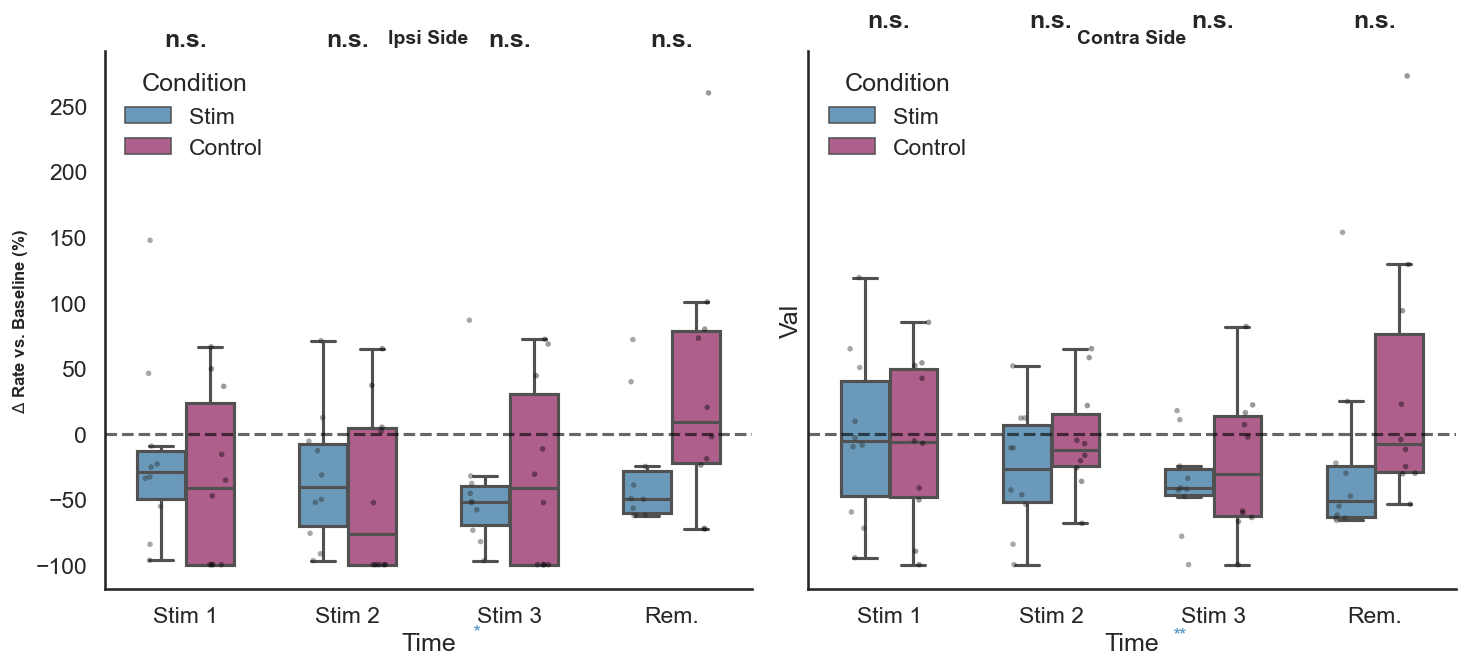

In [202]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# --- 1. פונקציית עזר לחילוץ נתוני גירוי בלבד לפי זמן ---
def get_stim_only_time_split(df_stim, df_ctrl, side_label):
    """
    מחלץ את בלוקי הגירוי: עמודות 1, 3, 5 (גירוי 1, 2, 3) והשאר (7, 9...).
    עמודה 0 היא בייסליין, לכן מתחילים מ-1.
    """
    res = []
    # אינדקסים של בלוקי הגירוי במטריצה
    stim_indices = [1, 3, 5] 
    
    for df, cond in [(df_stim, 'Stim'), (df_ctrl, 'Control')]:
        # שלושת הגירויים הראשונים
        for i, col_idx in enumerate(stim_indices):
            if df.shape[1] > col_idx:
                vals = df.iloc[:, col_idx].dropna().values
                for v in vals:
                    res.append({'Val': v, 'Time': f'Stim {i+1}', 'Cond': cond, 'Side': side_label})
        
        # כל שאר בלוקי הגירוי (מאינדקס 7 והלאה, בקפיצות של 2)
        if df.shape[1] > 7:
            # לוקחים רק את העמודות האי-זוגיות שנותרו
            other_stim_cols = [c for c in range(7, df.shape[1], 2)]
            remainder_vals = df.iloc[:, other_stim_cols].mean(axis=1).dropna().values
            for v in remainder_vals:
                res.append({'Val': v, 'Time': 'Rem.', 'Cond': cond, 'Side': side_label})
    return res

# --- 2. הכנת הנתונים ---
df_si = get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=1000)
df_ci = get_clean_matrix(data_control['rates']['ipsi'], mode='baseline', threshold=1000)
df_sc = get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=1000)
df_cc = get_clean_matrix(data_control['rates']['contra'], mode='baseline', threshold=1000)

data_all = get_time_split_data_v2 = get_stim_only_time_split(df_si, df_ci, 'Ipsi') + \
           get_stim_only_time_split(df_sc, df_cc, 'Contra')

df_plot = pd.DataFrame(data_all)

# --- 3. יצירת הגרף ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
colors = {'Stim': '#5e9bc7', 'Control': '#bb528c'}
time_order = ['Stim 1', 'Stim 2', 'Stim 3', 'Rem.']

for ax, side in zip([ax1, ax2], ['Ipsi', 'Contra']):
    subset = df_plot[df_plot['Side'] == side]
    
    # בוקספלוט ונקודות
    sns.boxplot(x='Time', y='Val', hue='Cond', data=subset, order=time_order, 
                palette=colors, ax=ax, width=0.6, fliersize=0)
    sns.stripplot(x='Time', y='Val', hue='Cond', data=subset, order=time_order,
                  color='black', alpha=0.4, dodge=True, ax=ax, size=4)
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.6)
    ax.set_title(f'{side} Side', fontweight='bold', fontsize=14)
    
    # --- סטטיסטיקה ---
    y_max = subset['Val'].max()
    y_min = subset['Val'].min()
    h = abs(y_max - y_min) * 0.05
    
    for i, t in enumerate(time_order):
        # שליפת ערכים למבחנים
        s_vals = subset[(subset['Time'] == t) & (subset['Cond'] == 'Stim')]['Val'].values
        c_vals = subset[(subset['Time'] == t) & (subset['Cond'] == 'Control')]['Val'].values
        
        if len(s_vals) > 1:
            # 1. מבחן Stim vs Control (למעלה)
            if len(c_vals) > 1:
                _, p_comp = stats.ttest_ind(s_vals, c_vals)
                stars = '***' if p_comp < 0.001 else '**' if p_comp < 0.01 else '*' if p_comp < 0.05 else 'n.s.'
                ax.text(i, y_max + 2*h, stars, ha='center', fontweight='bold')

            # 2. מבחן Stim vs 0 (מתחת לבוקס הכחול)
            _, p_vs_0_s = stats.ttest_1samp(s_vals, 0)
            stars_0_s = '***' if p_vs_0_s < 0.001 else '**' if p_vs_0_s < 0.01 else '*' if p_vs_0_s < 0.05 else ''
            ax.text(i - 0.2, y_min - 3*h, stars_0_s, ha='center', color=colors['Stim'], fontweight='bold', fontsize=12)

            # 3. מבחן Control vs 0 (מתחת לבוקס הוורוד)
            if len(c_vals) > 1:
                _, p_vs_0_c = stats.ttest_1samp(c_vals, 0)
                stars_0_c = '***' if p_vs_0_c < 0.001 else '**' if p_vs_0_c < 0.01 else '*' if p_vs_0_c < 0.05 else ''
                ax.text(i + 0.2, y_min - 3*h, stars_0_c, ha='center', color=colors['Control'], fontweight='bold', fontsize=12)

# עיצוב סופי
ax1.set_ylabel(r'$\Delta$ Rate vs. Baseline (%)', fontsize=12, fontweight='bold')
for ax in [ax1, ax2]:
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    # ניקוי מקרא כפול מה-stripplot אם מופיע
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Condition', frameon=False)

plt.tight_layout()
plt.show()

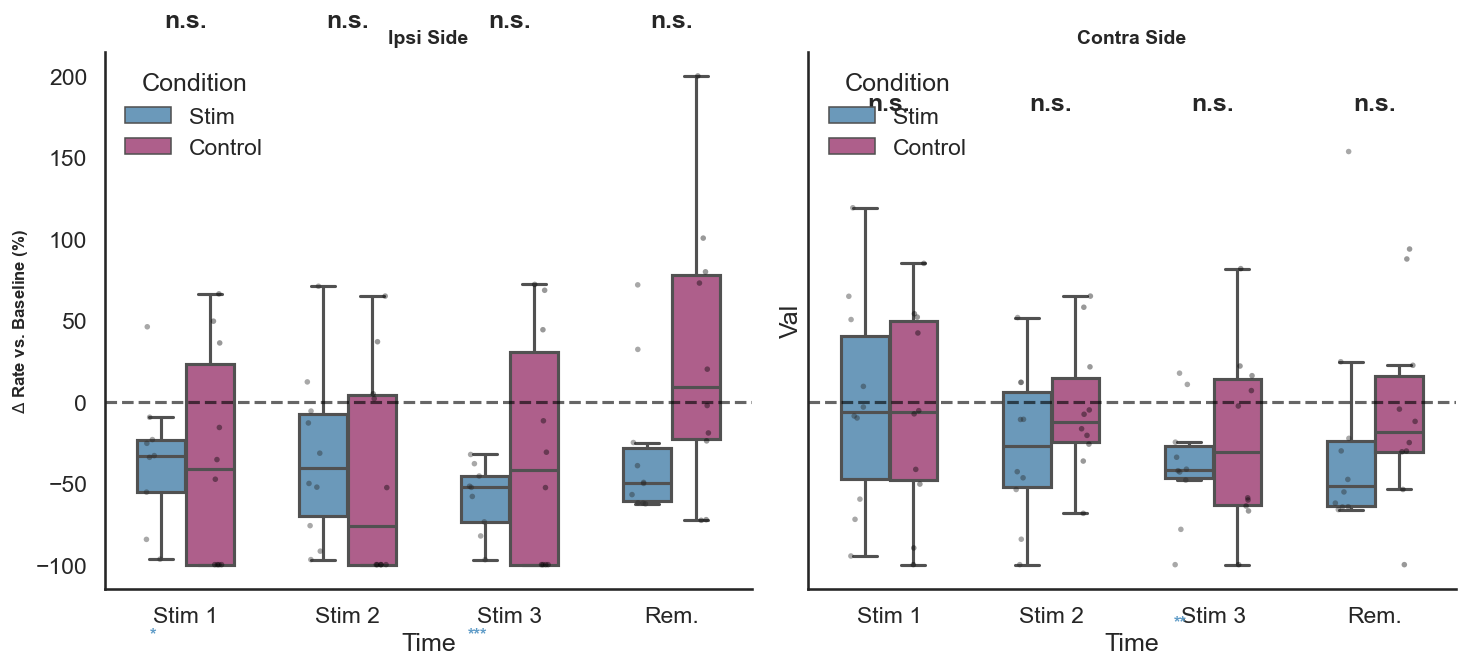

In [205]:
# --- 1. פונקציית עזר לחילוץ נתוני גירוי בלבד לפי זמן ---
def get_stim_only_time_split(df_stim, df_ctrl, side_label):
    """
    מחלץ את בלוקי הגירוי: עמודות 1, 3, 5 (גירוי 1, 2, 3) והשאר (7, 9...).
    עמודה 0 היא בייסליין, לכן מתחילים מ-1.
    """
    res = []
    # אינדקסים של בלוקי הגירוי במטריצה
    stim_indices = [1, 3, 5] 
    
    for df, cond in [(df_stim, 'Stim'), (df_ctrl, 'Control')]:
        # שלושת הגירויים הראשונים
        for i, col_idx in enumerate(stim_indices):
            if df.shape[1] > col_idx:
                vals = df.iloc[:, col_idx].dropna().values
                for v in vals:
                    res.append({'Val': v, 'Time': f'Stim {i+1}', 'Cond': cond, 'Side': side_label})
        
        # כל שאר בלוקי הגירוי (מאינדקס 7 והלאה, בקפיצות של 2)
        if df.shape[1] > 7:
            # לוקחים רק את העמודות האי-זוגיות שנותרו
            other_stim_cols = [c for c in range(7, df.shape[1], 2)]
            remainder_vals = df.iloc[:, other_stim_cols].mean(axis=1).dropna().values
            for v in remainder_vals:
                res.append({'Val': v, 'Time': 'Rem.', 'Cond': cond, 'Side': side_label})
    return res

# --- 2. הכנת הנתונים ---
df_si = get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=3)
df_ci = get_clean_matrix(data_control['rates']['ipsi'], mode='baseline', threshold=3)
df_sc = get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=3)
df_cc = get_clean_matrix(data_control['rates']['contra'], mode='baseline', threshold=3)

data_all = get_time_split_data_v2 = get_stim_only_time_split(df_si, df_ci, 'Ipsi') + \
           get_stim_only_time_split(df_sc, df_cc, 'Contra')

df_plot = pd.DataFrame(data_all)

# --- 3. יצירת הגרף ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
colors = {'Stim': '#5e9bc7', 'Control': '#bb528c'}
time_order = ['Stim 1', 'Stim 2', 'Stim 3', 'Rem.']

for ax, side in zip([ax1, ax2], ['Ipsi', 'Contra']):
    subset = df_plot[df_plot['Side'] == side]
    
    # בוקספלוט ונקודות
    sns.boxplot(x='Time', y='Val', hue='Cond', data=subset, order=time_order, 
                palette=colors, ax=ax, width=0.6, fliersize=0)
    sns.stripplot(x='Time', y='Val', hue='Cond', data=subset, order=time_order,
                  color='black', alpha=0.4, dodge=True, ax=ax, size=4)
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.6)
    ax.set_title(f'{side} Side', fontweight='bold', fontsize=14)
    
    # --- סטטיסטיקה ---
    y_max = subset['Val'].max()
    y_min = subset['Val'].min()
    h = abs(y_max - y_min) * 0.05
    
    for i, t in enumerate(time_order):
        # שליפת ערכים למבחנים
        s_vals = subset[(subset['Time'] == t) & (subset['Cond'] == 'Stim')]['Val'].values
        c_vals = subset[(subset['Time'] == t) & (subset['Cond'] == 'Control')]['Val'].values
        
        if len(s_vals) > 1:
            # 1. מבחן Stim vs Control (למעלה)
            if len(c_vals) > 1:
                _, p_comp = stats.ttest_ind(s_vals, c_vals)
                stars = '***' if p_comp < 0.001 else '**' if p_comp < 0.01 else '*' if p_comp < 0.05 else 'n.s.'
                ax.text(i, y_max + 2*h, stars, ha='center', fontweight='bold')

            # 2. מבחן Stim vs 0 (מתחת לבוקס הכחול)
            _, p_vs_0_s = stats.ttest_1samp(s_vals, 0)
            stars_0_s = '***' if p_vs_0_s < 0.001 else '**' if p_vs_0_s < 0.01 else '*' if p_vs_0_s < 0.05 else ''
            ax.text(i - 0.2, y_min - 3*h, stars_0_s, ha='center', color=colors['Stim'], fontweight='bold', fontsize=12)

            # 3. מבחן Control vs 0 (מתחת לבוקס הוורוד)
            if len(c_vals) > 1:
                _, p_vs_0_c = stats.ttest_1samp(c_vals, 0)
                stars_0_c = '***' if p_vs_0_c < 0.001 else '**' if p_vs_0_c < 0.01 else '*' if p_vs_0_c < 0.05 else ''
                ax.text(i + 0.2, y_min - 3*h, stars_0_c, ha='center', color=colors['Control'], fontweight='bold', fontsize=12)

# עיצוב סופי
ax1.set_ylabel(r'$\Delta$ Rate vs. Baseline (%)', fontsize=12, fontweight='bold')
for ax in [ax1, ax2]:
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    # ניקוי מקרא כפול מה-stripplot אם מופיע
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Condition', frameon=False)

plt.tight_layout()
plt.show()

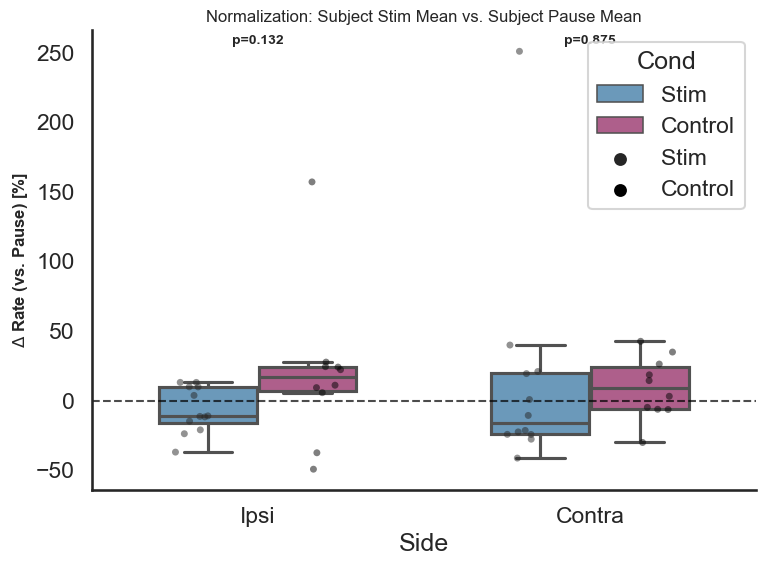

In [195]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# 1. הגדרת אינדקסים
stim_idx = [1, 3, 5, 7, 9, 11]
pause_idx = [0, 2, 4, 6, 8, 10]

def get_normalized_subject_means(data_dict, side):
    """
    הופך רשימה ל-DF, מנרמל כל נבדק לממוצע ההפסקות שלו, ומחזיר ממוצע לכל נבדק בבלוקי הגירוי.
    """
    # שליפת הנתונים והפיכתם ל-DataFrame (למקרה שהם רשימה)
    raw_data = data_dict['rates'][side]
    matrix = pd.DataFrame(raw_data)
    
    # חישוב ממוצע ההפסקות לכל נבדק (שורה)
    # שימוש ב-values.mean כדי לעקוף בעיות אינדקסים אם ישנן
    pause_means = matrix.iloc[:, pause_idx].mean(axis=1)
    
    # נרמול: אחוז שינוי מההפסקה
    # מונעים חלוקה ב-0 על ידי החלפת 0 ב-NaN זמני
    pause_means = pause_means.replace(0, np.nan)
    
    norm_matrix = matrix.iloc[:, stim_idx].div(pause_means, axis=0).sub(1).mul(100)
    
    # ניקוי ערכים לא תקינים וממוצע לכל נבדק
    return norm_matrix.mean(axis=1).dropna().values

# 2. איסוף נתונים (איחוד קבוצות)
try:
    v_si_stim = np.concatenate([
        get_normalized_subject_means(data_stim, 'ipsi'),
        get_normalized_subject_means(data_no_base, 'ipsi')
    ])
    v_sc_stim = np.concatenate([
        get_normalized_subject_means(data_stim, 'contra'),
        get_normalized_subject_means(data_no_base, 'contra')
    ])

    v_si_ctrl = get_normalized_subject_means(data_control, 'ipsi')
    v_sc_ctrl = get_normalized_subject_means(data_control, 'contra')

    # 3. בניית DataFrame לציור
    plot_list = []
    for v in v_si_stim: plot_list.append({'Val': v, 'Side': 'Ipsi', 'Cond': 'Stim'})
    for v in v_sc_stim: plot_list.append({'Val': v, 'Side': 'Contra', 'Cond': 'Stim'})
    for v in v_si_ctrl: plot_list.append({'Val': v, 'Side': 'Ipsi', 'Cond': 'Control'})
    for v in v_sc_ctrl: plot_list.append({'Val': v, 'Side': 'Contra', 'Cond': 'Control'})
    df_plot = pd.DataFrame(plot_list)

    # 4. יצירת הגרף
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = {'Stim': '#5e9bc7', 'Control': '#bb528c'}

    sns.boxplot(x='Side', y='Val', hue='Cond', data=df_plot, palette=colors, ax=ax, width=0.6, fliersize=0)
    sns.stripplot(x='Side', y='Val', hue='Cond', data=df_plot, color='black', alpha=0.5, dodge=True, ax=ax)

    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # סטטיסטיקה פשוטה מעל הגרף (Stim vs Control)
    for i, side in enumerate(['Ipsi', 'Contra']):
        s_vals = df_plot[(df_plot['Side'] == side) & (df_plot['Cond'] == 'Stim')]['Val']
        c_vals = df_plot[(df_plot['Side'] == side) & (df_plot['Cond'] == 'Control')]['Val']
        t_stat, p_val = stats.ttest_ind(s_vals, c_vals)
        
        y_max = df_plot['Val'].max()
        ax.text(i, y_max + 5, f'p={p_val:.3f}', ha='center', fontsize=10, fontweight='bold')

    ax.set_ylabel(r'$\Delta$ Rate (vs. Pause) [%]', fontsize=12, fontweight='bold')
    ax.set_title('Normalization: Subject Stim Mean vs. Subject Pause Mean', fontsize=12)
    
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error occurred: {e}")

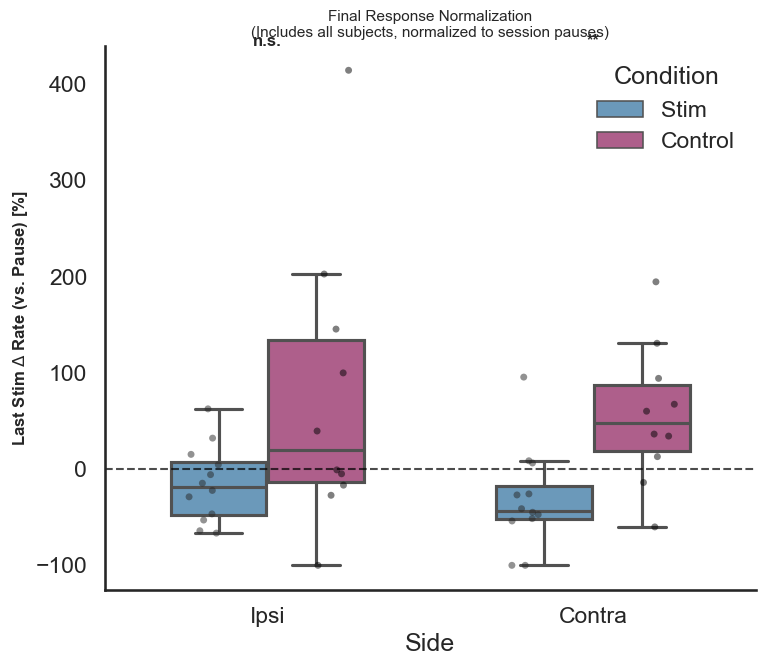

In [207]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# 1. הגדרת אינדקסים
stim_idx_full = [1, 3, 5, 7, 9, 11]
pause_idx = [0, 2, 4, 6, 8, 10]

def get_last_stim_normalized(data_dict, side):
    """
    מנרמל את כל המטריצה לממוצע ההפסקות של כל נבדק,
    ואז שולף לכל נבדק רק את ערך הגירוי האחרון שקיים עבורו.
    """
    # הפיכה ל-DF (טיפול במקרה של רשימות)
    raw_data = data_dict['rates'][side]
    matrix = pd.DataFrame(raw_data)
    
    # חישוב ממוצע ההפסקות לכל נבדק (שורה)
    pause_means = matrix.iloc[:, pause_idx].mean(axis=1)
    pause_means = pause_means.replace(0, np.nan) # מניעת חלוקה ב-0
    
    # נרמול המטריצה כולה (אחוז שינוי מההפסקה)
    norm_matrix = matrix.div(pause_means, axis=0).sub(1).mul(100)
    
    # שליפת ערך הגירוי האחרון הקיים מתוך העמודות האי-זוגיות
    last_vals = []
    # נתמקד רק בעמודות שהן פוטנציאלית "גירוי"
    stim_cols = [c for c in stim_idx_full if c < matrix.shape[1]]
    
    for _, row in norm_matrix.iterrows():
        valid_stim = row[stim_cols].dropna()
        if not valid_stim.empty:
            last_vals.append(valid_stim.values[-1])
            
    return np.array(last_vals)

# 2. איסוף נתונים (כולל נבדקי ה-no_base)
try:
    v_si_stim = np.concatenate([
        get_last_stim_normalized(data_stim, 'ipsi'),
        get_last_stim_normalized(data_no_base, 'ipsi')
    ])
    v_sc_stim = np.concatenate([
        get_last_stim_normalized(data_stim, 'contra'),
        get_last_stim_normalized(data_no_base, 'contra')
    ])

    v_si_ctrl = get_last_stim_normalized(data_control, 'ipsi')
    v_sc_ctrl = get_last_stim_normalized(data_control, 'contra')

    # 3. בניית DataFrame לציור
    plot_list = []
    for v in v_si_stim: plot_list.append({'Val': v, 'Side': 'Ipsi', 'Cond': 'Stim'})
    for v in v_sc_stim: plot_list.append({'Val': v, 'Side': 'Contra', 'Cond': 'Stim'})
    for v in v_si_ctrl: plot_list.append({'Val': v, 'Side': 'Ipsi', 'Cond': 'Control'})
    for v in v_sc_ctrl: plot_list.append({'Val': v, 'Side': 'Contra', 'Cond': 'Control'})
    df_plot = pd.DataFrame(plot_list)

    # 4. יצירת הגרף והסטטיסטיקה
    fig, ax = plt.subplots(figsize=(8, 7))
    colors = {'Stim': '#5e9bc7', 'Control': '#bb528c'}

    sns.boxplot(x='Side', y='Val', hue='Cond', data=df_plot, palette=colors, ax=ax, width=0.6, fliersize=0)
    sns.stripplot(x='Side', y='Val', hue='Cond', data=df_plot, color='black', alpha=0.5, dodge=True, ax=ax)

    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # חישובי סטטיסטיקה להצגה
    y_max = df_plot['Val'].max()
    y_min = df_plot['Val'].min()
    h = abs(y_max - y_min) * 0.05

    for i, side in enumerate(['Ipsi', 'Contra']):
        s_vals = df_plot[(df_plot['Side'] == side) & (df_plot['Cond'] == 'Stim')]['Val']
        c_vals = df_plot[(df_plot['Side'] == side) & (df_plot['Cond'] == 'Control')]['Val']
        
        # מבחן Stim vs Control
        _, p_comp = stats.ttest_ind(s_vals, c_vals)
        stars = '***' if p_comp < 0.001 else '**' if p_comp < 0.01 else '*' if p_comp < 0.05 else 'n.s.'
        ax.text(i, y_max + h, stars, ha='center', fontweight='bold', fontsize=12)
        
        # מבחן Stim vs 0 (למטה)
        _, p_vs_0 = stats.ttest_1samp(s_vals, 0)
        stars_0 = '***' if p_vs_0 < 0.001 else '**' if p_vs_0 < 0.01 else '*' if p_vs_0 < 0.05 else ''
        ax.text(i - 0.2, y_min - 3*h, stars_0, ha='center', color=colors['Stim'], fontweight='bold')

    ax.set_ylabel(r'Last Stim $\Delta$ Rate (vs. Pause) [%]', fontsize=12, fontweight='bold')
    ax.set_title('Final Response Normalization\n(Includes all subjects, normalized to session pauses)', fontsize=11)
    
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    
    # תיקון מקרא
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Condition', frameon=False)
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error occurred: {e}")

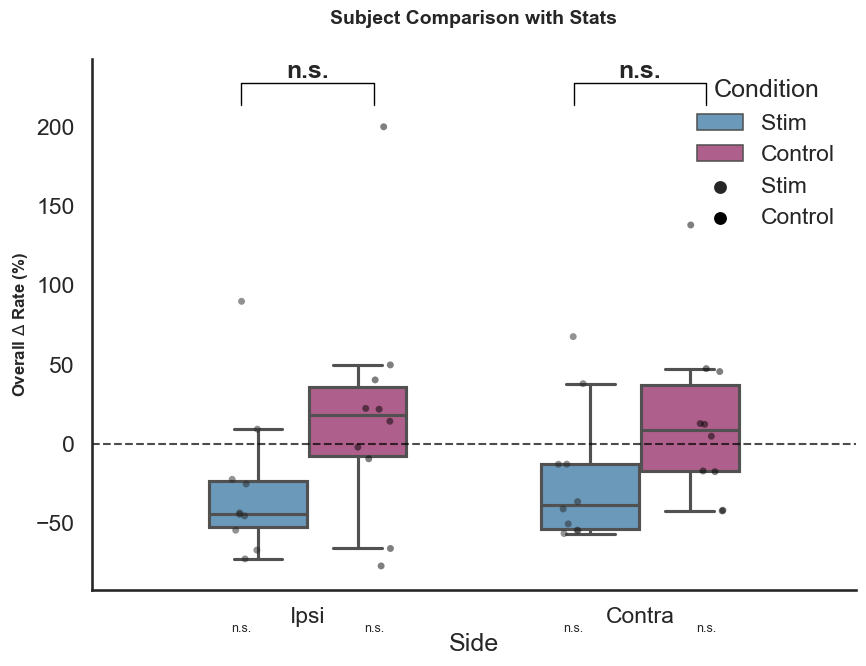

In [190]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# --- 1. הכנת הנתונים (שימוש במבנה המדויק שלך) ---
stim_idx = [1, 3, 5, 7, 9, 11]

df_si = get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=1000)
df_sc = get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=1000)
df_ci = get_clean_matrix(data_control['rates']['ipsi'], mode='baseline', threshold=1000)
df_cc = get_clean_matrix(data_control['rates']['contra'], mode='baseline', threshold=1000)

# חילוץ ממוצעים לנבדק
v_si = df_si.iloc[:, stim_idx].mean(axis=1).dropna().values
v_sc = df_sc.iloc[:, stim_idx].mean(axis=1).dropna().values
v_ci = df_ci.iloc[:, stim_idx].mean(axis=1).dropna().values
v_cc = df_cc.iloc[:, stim_idx].mean(axis=1).dropna().values

# ארגון ב-DataFrame
df_plot = pd.DataFrame(
    [{'Val': v, 'Side': 'Ipsi', 'Cond': 'Stim'} for v in v_si] +
    [{'Val': v, 'Side': 'Contra', 'Cond': 'Stim'} for v in v_sc] +
    [{'Val': v, 'Side': 'Ipsi', 'Cond': 'Control'} for v in v_ci] +
    [{'Val': v, 'Side': 'Contra', 'Cond': 'Control'} for v in v_cc]
)

# --- 2. חישוב סטטיסטיקה ---
def get_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'n.s.'

# מבחן מול 0 (One-sample t-test)
p_vals_vs_0 = {
    ('Ipsi', 'Stim'): stats.ttest_1samp(v_si, 0)[1],
    ('Contra', 'Stim'): stats.ttest_1samp(v_sc, 0)[1],
    ('Ipsi', 'Control'): stats.ttest_1samp(v_ci, 0)[1],
    ('Contra', 'Control'): stats.ttest_1samp(v_cc, 0)[1]
}

# מבחן בין Stim ל-Control (Independent t-test)
p_comp_ipsi = stats.ttest_ind(v_si, v_ci)[1]
p_comp_contra = stats.ttest_ind(v_sc, v_cc)[1]

# --- 3. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(9, 7))
colors = {'Stim': '#5e9bc7', 'Control': '#bb528c'}

sns.boxplot(x='Side', y='Val', hue='Cond', data=df_plot, palette=colors, ax=ax, width=0.6, fliersize=0)
sns.stripplot(x='Side', y='Val', hue='Cond', data=df_plot, color='black', alpha=0.5, dodge=True, ax=ax)

ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# --- 4. הוספת אנוטציות סטטיסטיות ---
y_max = df_plot['Val'].max()
y_min = df_plot['Val'].min()
margin = abs(y_max - y_min) * 0.05

# אנוטציה להשוואה בין Stim ל-Control בתוך כל צד (הקו העליון)
for i, side in enumerate(['Ipsi', 'Contra']):
    p = p_comp_ipsi if side == 'Ipsi' else p_comp_contra
    x_pos = i
    # מיקום הברים מעל כל זוג בוקסים
    ax.plot([x_pos-0.2, x_pos-0.2, x_pos+0.2, x_pos+0.2], 
            [y_max + margin, y_max + 2*margin, y_max + 2*margin, y_max + margin], color='black', lw=1)
    ax.text(x_pos, y_max + 2.2*margin, get_stars(p), ha='center', fontweight='bold')

# אנוטציה למבחן מול 0 (למטה מתחת לכל בוקס)
for i, side in enumerate(['Ipsi', 'Contra']):
    for j, cond in enumerate(['Stim', 'Control']):
        p = p_vals_vs_0[(side, cond)]
        x_offset = -0.2 if j == 0 else 0.2
        ax.text(i + x_offset, y_min - 3*margin, get_stars(p), ha='center', fontsize=9)

ax.set_ylabel(r'Overall $\Delta$ Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Subject Comparison with Stats', fontsize=14, fontweight='bold', pad=25)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
ax.legend(title='Condition', frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

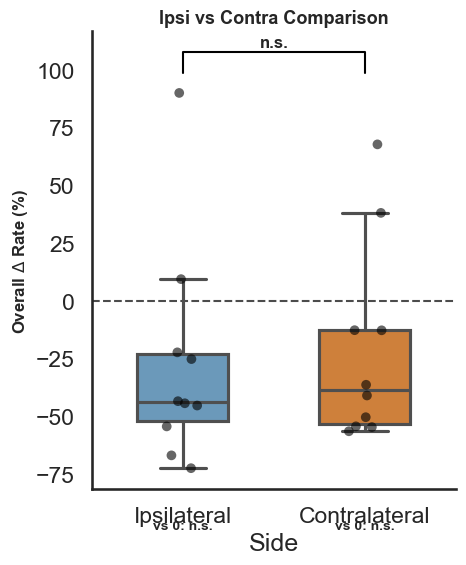

In [185]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# --- 1. הגדרת המשתנים שחסרו (ה-DataFrames) ---
# אנחנו מוציאים את הנתונים עבור 'ipsi' ועבור 'contra' מתוך ה-data_stim
df_rate_ipsi_stim = get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=1000)
df_rate_contra_stim = get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=1000)

# הגדרת האינדקסים של הבלוקים (אם לא הוגדר קודם)
stim_idx = [1, 3, 5, 7, 9, 11]

# --- 2. הפונקציה לציור הבוקספלוט עם הסטטיסטיקה ---
def plot_subject_comparison_with_stats(df_ipsi, df_contra, idx_list):
    # חילוץ ממוצעים לכל נבדק
    ipsi_vals = df_ipsi.iloc[:, idx_list].mean(axis=1).dropna().values
    contra_vals = df_contra.iloc[:, idx_list].mean(axis=1).dropna().values
    
    # חישוב סטטיסטיקה מול 0 (One-sample t-test)
    t_ipsi, p_ipsi = stats.ttest_1samp(ipsi_vals, 0)
    t_contra, p_contra = stats.ttest_1samp(contra_vals, 0)
    
    # חישוב סטטיסטיקה בין הקבוצות (Independent t-test)
    t_comp, p_comp = stats.ttest_ind(ipsi_vals, contra_vals)
    
    # הכנת הנתונים לציור
    plot_data = pd.DataFrame({
        'Change': np.concatenate([ipsi_vals, contra_vals]),
        'Side': ['Ipsilateral'] * len(ipsi_vals) + ['Contralateral'] * len(contra_vals)
    })

    fig, ax = plt.subplots(figsize=(5, 6))
    
    # ציור בוקספלוט ונקודות
    sns.boxplot(x='Side', y='Change', data=plot_data, palette=['#5e9bc7', '#e67e22'], 
                ax=ax, width=0.5, fliersize=0, zorder=1)
    sns.stripplot(x='Side', y='Change', data=plot_data, color='black', 
                  alpha=0.6, size=7, ax=ax, zorder=2)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)

    # פונקציית עזר לכוכביות
    def get_stars(p):
        if p < 0.001: return '***'
        if p < 0.01: return '**'
        if p < 0.05: return '*'
        return 'n.s.'

    # אנוטציה להשוואה בין הקבוצות (קו עליון)
    y_max = plot_data['Change'].max()
    margin = plot_data['Change'].std() * 0.2
    ax.plot([0, 0, 1, 1], [y_max + margin, y_max + 2*margin, y_max + 2*margin, y_max + margin], color='black', lw=1.5)
    ax.text(0.5, y_max + 2.1*margin, get_stars(p_comp), ha='center', va='bottom', fontsize=12, fontweight='bold')

    # אנוטציות למבחן מול 0 (למטה)
    y_min = plot_data['Change'].min() - 3*margin
    ax.text(0, y_min, f"vs 0: {get_stars(p_ipsi)}", ha='center', fontsize=10, fontweight='bold')
    ax.text(1, y_min, f"vs 0: {get_stars(p_contra)}", ha='center', fontsize=10, fontweight='bold')

    # עיצוב
    ax.set_ylabel(r'Overall $\Delta$ Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Ipsi vs Contra Comparison', fontsize=13, fontweight='bold')
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# --- 3. הרצה ---
plot_subject_comparison_with_stats(df_rate_ipsi_stim, df_rate_contra_stim, stim_idx)

--- Statistics for STIM ---
Stim 1 - Between Groups p: 0.4256
Stim 2 - Between Groups p: 0.3410
Stim 3 - Between Groups p: 0.9697
Last Blocks - Between Groups p: 0.1041


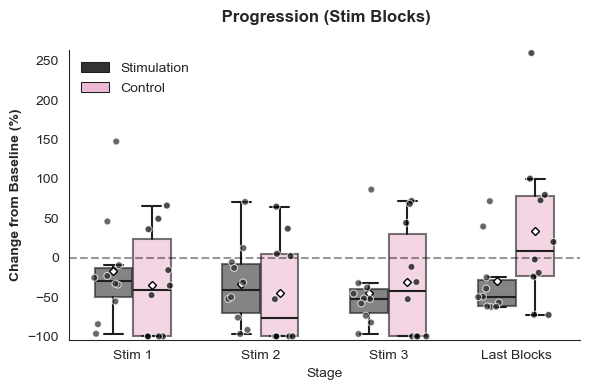

In [27]:

def prepare_final_data(data_source, hemi_type='ipsi', block_type='stim', group_label='Group'):
    all_subjects = []
    raw_data = data_source['rates'][hemi_type]
    
    for name, subj_rates in zip(subjects, raw_data):
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        if block_type == 'stim':
            vals = subj_rates[1::2]
            stages = ['Stim 1', 'Stim 2', 'Stim 3', 'Last Blocks']
        else:
            vals = subj_rates[2::2]
            stages = ['Pause 1', 'Pause 2', 'Pause 3', 'Last Blocks']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        row = [pct_changes[0], pct_changes[1], pct_changes[2], 
               np.nanmean(pct_changes[3:]) if len(pct_changes) > 3 else np.nan]
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Group'] = group_label
    return df_wide, df_long

def plot_final_comparison_with_brackets(block_to_plot='stim'):
    # 1. הכנת הנתונים (מבוסס על prepare_final_data מהשלב הקודם)
    df_w_stim, df_l_stim = prepare_final_data(data_stim, 'ipsi', block_to_plot, 'Stimulation')
    df_w_ctrl, df_l_ctrl = prepare_final_data(data_control, 'ipsi', block_to_plot, 'Control')
    df_combined = pd.concat([df_l_stim, df_l_ctrl])
    
    plt.figure(figsize=(6, 4))
    sns.set_style("white")
    
    pal = {'Stimulation': '#333333', 'Control': '#f4b1d2'}
    
    # 2. ציור הבוקספלוט
    ax = sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                     palette=pal, width=0.6, fliersize=0, zorder=2,
                     boxprops=dict(alpha=0.6), 
                     showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                                "markeredgecolor":"black", "markersize":4})
    
    # 3. נקודות דגימה בולטות
    sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                  dodge=True, color='black', alpha=0.7, size=5, jitter=0.2, zorder=3,
                  linewidth=0.8, edgecolor='white')

    # 4. הגדרות גובה לסטטיסטיקה
    y_within = 150 # גובה כוכביות מול בייסליין
    y_between_start = 175 # גובה התחלה לסוגר בין קבוצות
    stages = df_combined['Stage'].unique()
    offsets = [-0.15, 0.15]
    
    print(f"--- Statistics for {block_to_plot.upper()} ---")
    for i, stage in enumerate(stages):
        d_s = df_w_stim[stage].dropna()
        d_c = df_w_ctrl[stage].dropna()
        
        # א. סטטיסטיקה בתוך קבוצה (מול 0) - בגובה 150
        for idx, (data, grp_name) in enumerate([(d_s, 'Stimulation'), (d_c, 'Control')]):
            if len(data) >= 5:
                _, p_w = wilcoxon(data)
                if p_w < 0.05:
                    star_w = '***' if p_w < 0.001 else '**' if p_w < 0.01 else '*'
                    plt.text(i + offsets[idx], y_within, star_w, ha='center', 
                             fontweight='bold', color=pal[grp_name], fontsize=12)

        # ב. סטטיסטיקה בין קבוצות + קו מחבר
        if len(d_s) > 0 and len(d_c) > 0:
            _, p_bet = mannwhitneyu(d_s, d_c)
            print(f"{stage} - Between Groups p: {p_bet:.4f}")
            
            if p_bet < 0.05:
                star_b = '***' if p_bet < 0.001 else '**' if p_bet < 0.01 else '*'
                # ציור הסוגר (Bracket)
                x1, x2 = i + offsets[0], i + offsets[1]
                h = 5 # גובה ה"כתפיים" של הסוגר
                plt.plot([x1, x1, x2, x2], [y_between_start, y_between_start+h, y_between_start+h, y_between_start], 
                         lw=1.2, color='#555555')
                plt.text((x1+x2)/2, y_between_start + h + 2, star_b, ha='center', 
                         va='bottom', color='black', fontweight='bold', fontsize=12)

    # 5. עיצוב צירים ומקרא
    plt.axhline(0, color='black', linestyle='--', alpha=0.4)
    plt.ylim(-105, 264) # הגדלת הטווח כדי שיהיה מקום לסוגרים
    plt.ylabel("Change from Baseline (%)", fontweight='bold')
    plt.title(f" Progression ({block_to_plot.capitalize()} Blocks)", fontweight='bold', pad=20)
    
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], frameon=False, loc='upper left')
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_final_comparison_with_brackets('stim')

--- Statistics for STIM ---


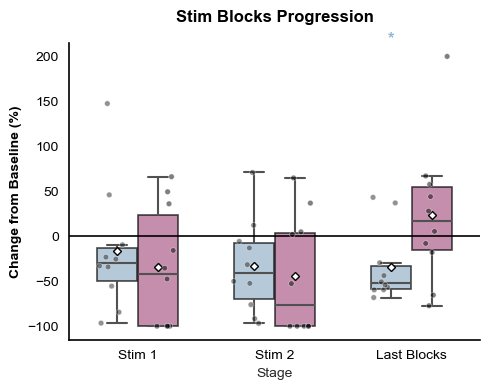

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, mannwhitneyu

def prepare_final_data(data_source, hemi_type='ipsi', block_type='stim', group_label='Group'):
    all_subjects = []
    raw_data = data_source['rates'][hemi_type]
    
    # השתמשתי ב-enumerate במקום subjects כדי למנוע בעיות אם הרשימה לא באותו אורך
    for i, subj_rates in enumerate(raw_data):
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        if block_type == 'stim':
            vals = subj_rates[1::2]
            # הגדרת 3 עמודות בלבד
            stages = ['Stim 1', 'Stim 2', 'Last Blocks']
        else:
            vals = subj_rates[2::2]
            stages = ['Pause 1', 'Pause 2', 'Last Blocks']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        
        # לוגיקה מעודכנת: 
        # נקודה 1, נקודה 2, וממוצע של כל השאר (החל מאינדקס 2, שזה הגירוי השלישי)
        row = [pct_changes[0], 
               pct_changes[1], 
               np.nanmean(pct_changes[2:])]
        
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    
    # ללא סינון חריגים (כפי שביקשת)
    
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Group'] = group_label
    return df_wide, df_long

def plot_final_comparison_with_brackets(block_to_plot='stim'):
    # 1. הכנת הנתונים
    df_w_stim, df_l_stim = prepare_final_data(data_stim, 'ipsi', block_to_plot, 'Stimulation')
    df_w_ctrl, df_l_ctrl = prepare_final_data(data_control, 'ipsi', block_to_plot, 'Control')
    df_combined = pd.concat([df_l_stim, df_l_ctrl])
    
    plt.figure(figsize=(5, 4))
    sns.set_style("white")
    
    # צבעים מעודכנים
    pal = {'Stimulation': '#8db4d3', 'Control': '#bb528c'}
    
    # 2. ציור הבוקספלוט
    ax = sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                     palette=pal, width=0.6, fliersize=0, zorder=2,
                     boxprops=dict(alpha=0.7, edgecolor='black', linewidth=1.2), 
                     showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                                "markeredgecolor":"black", "markersize":4})
    
    # 3. נקודות דגימה
    sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                  dodge=True, color='black', alpha=0.5, size=4, jitter=0.2, zorder=3,
                  linewidth=0.5, edgecolor='white')

    # 4. הגדרות סטטיסטיקה (מותאמות לערכים ללא סינון)
    y_max = df_combined['Change_Percent'].max()
    y_within = y_max + 15
    y_between_start = y_max + 45
    
    stages = df_combined['Stage'].unique()
    offsets = [-0.15, 0.15]
    
    print(f"--- Statistics for {block_to_plot.upper()} ---")
    for i, stage in enumerate(stages):
        d_s = df_w_stim[stage].dropna()
        d_c = df_w_ctrl[stage].dropna()
        
        # א. בתוך קבוצה
        for idx, (data, grp_name) in enumerate([(d_s, 'Stimulation'), (d_c, 'Control')]):
            if len(data) >= 5:
                _, p_w = wilcoxon(data)
                if p_w < 0.05:
                    star_w = '***' if p_w < 0.001 else '**' if p_w < 0.01 else '*'
                    plt.text(i + offsets[idx], y_within, star_w, ha='center', 
                             fontweight='bold', color=pal[grp_name], fontsize=12)

        # ב. בין קבוצות
        if len(d_s) > 0 and len(d_c) > 0:
            _, p_bet = mannwhitneyu(d_s, d_c)
            if p_bet < 0.05:
                star_b = '***' if p_bet < 0.001 else '**' if p_bet < 0.01 else '*'
                x1, x2 = i + offsets[0], i + offsets[1]
                h = 10
                plt.plot([x1, x1, x2, x2], [y_between_start, y_between_start+h, y_between_start+h, y_between_start], 
                         lw=1.2, color='black')
                plt.text((x1+x2)/2, y_between_start + h, star_b, ha='center', 
                         va='bottom', color='black', fontweight='bold', fontsize=12)

    # 5. עיצוב צירים שחור מוחלט
    plt.axhline(0, color='black', linestyle='-', linewidth=1.2)
    
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.tick_params(axis='both', which='major', direction='out', length=4, width=1.2, colors='black')
    
    plt.ylabel("Change from Baseline (%)", fontweight='bold', color='black')
    plt.title(f"{block_to_plot.capitalize()} Blocks Progression", fontweight='bold', color='black', pad=15)
    
    if ax.get_legend(): ax.get_legend().remove()
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_final_comparison_with_brackets('stim')

--- Statistics for STIM ---


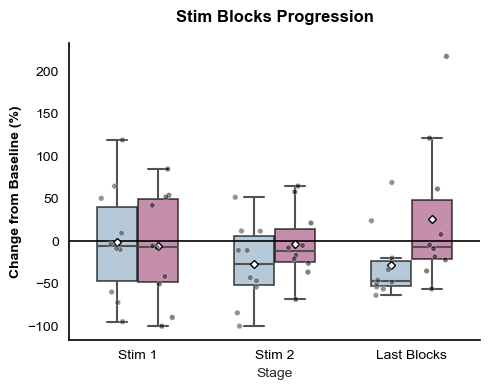

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, mannwhitneyu

def prepare_final_data(data_source, hemi_type='ipsi', block_type='stim', group_label='Group'):
    all_subjects = []
    raw_data = data_source['rates'][hemi_type]
    
    # השתמשתי ב-enumerate במקום subjects כדי למנוע בעיות אם הרשימה לא באותו אורך
    for i, subj_rates in enumerate(raw_data):
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        if block_type == 'stim':
            vals = subj_rates[1::2]
            # הגדרת 3 עמודות בלבד
            stages = ['Stim 1', 'Stim 2', 'Last Blocks']
        else:
            vals = subj_rates[2::2]
            stages = ['Pause 1', 'Pause 2', 'Last Blocks']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        
        # לוגיקה מעודכנת: 
        # נקודה 1, נקודה 2, וממוצע של כל השאר (החל מאינדקס 2, שזה הגירוי השלישי)
        row = [pct_changes[0], 
               pct_changes[1], 
               np.nanmean(pct_changes[2:])]
        
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    
    # ללא סינון חריגים (כפי שביקשת)
    
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Group'] = group_label
    return df_wide, df_long

def plot_final_comparison_with_brackets(block_to_plot='stim'):
    # 1. הכנת הנתונים
    df_w_stim, df_l_stim = prepare_final_data(data_stim, 'contra', block_to_plot, 'Stimulation')
    df_w_ctrl, df_l_ctrl = prepare_final_data(data_control, 'contra', block_to_plot, 'Control')
    df_combined = pd.concat([df_l_stim, df_l_ctrl])
    
    plt.figure(figsize=(5, 4))
    sns.set_style("white")
    
    # צבעים מעודכנים
    pal = {'Stimulation': '#8db4d3', 'Control': '#bb528c'}
    
    # 2. ציור הבוקספלוט
    ax = sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                     palette=pal, width=0.6, fliersize=0, zorder=2,
                     boxprops=dict(alpha=0.7, edgecolor='black', linewidth=1.2), 
                     showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                                "markeredgecolor":"black", "markersize":4})
    
    # 3. נקודות דגימה
    sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                  dodge=True, color='black', alpha=0.5, size=4, jitter=0.2, zorder=3,
                  linewidth=0.5, edgecolor='white')

    # 4. הגדרות סטטיסטיקה (מותאמות לערכים ללא סינון)
    y_max = df_combined['Change_Percent'].max()
    y_within = y_max + 15
    y_between_start = y_max + 45
    
    stages = df_combined['Stage'].unique()
    offsets = [-0.15, 0.15]
    
    print(f"--- Statistics for {block_to_plot.upper()} ---")
    for i, stage in enumerate(stages):
        d_s = df_w_stim[stage].dropna()
        d_c = df_w_ctrl[stage].dropna()
        
        # א. בתוך קבוצה
        for idx, (data, grp_name) in enumerate([(d_s, 'Stimulation'), (d_c, 'Control')]):
            if len(data) >= 5:
                _, p_w = wilcoxon(data)
                if p_w < 0.05:
                    star_w = '***' if p_w < 0.001 else '**' if p_w < 0.01 else '*'
                    plt.text(i + offsets[idx], y_within, star_w, ha='center', 
                             fontweight='bold', color=pal[grp_name], fontsize=12)

        # ב. בין קבוצות
        if len(d_s) > 0 and len(d_c) > 0:
            _, p_bet = mannwhitneyu(d_s, d_c)
            if p_bet < 0.05:
                star_b = '***' if p_bet < 0.001 else '**' if p_bet < 0.01 else '*'
                x1, x2 = i + offsets[0], i + offsets[1]
                h = 10
                plt.plot([x1, x1, x2, x2], [y_between_start, y_between_start+h, y_between_start+h, y_between_start], 
                         lw=1.2, color='black')
                plt.text((x1+x2)/2, y_between_start + h, star_b, ha='center', 
                         va='bottom', color='black', fontweight='bold', fontsize=12)

    # 5. עיצוב צירים שחור מוחלט
    plt.axhline(0, color='black', linestyle='-', linewidth=1.2)
    
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.tick_params(axis='both', which='major', direction='out', length=4, width=1.2, colors='black')
    
    plt.ylabel("Change from Baseline (%)", fontweight='bold', color='black')
    plt.title(f"{block_to_plot.capitalize()} Blocks Progression", fontweight='bold', color='black', pad=15)
    
    if ax.get_legend(): ax.get_legend().remove()
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_final_comparison_with_brackets('stim')

In [29]:
# all data from 2 groups including pause
import statsmodels.formula.api as smf

def get_raw_long(data_dict, group_name):
    # כאן אני לוקח את הרשימה הגולמית של הבלוקים
    # ההנחה היא שכל איבר ברשימה הוא נבדק, ובו מערך של ערכי Rate לכל בלוק
    raw_data = data_dict['rates']['all']
    
    rows = []
    for sub_idx, sub_rates in enumerate(raw_data):
        # sub_rates הוא מערך של ערכים עבור נבדק אחד (למשל 13 בלוקים: BL, S1, P1...)
        for block_idx, value in enumerate(sub_rates):
            # הגדרת סוג הבלוק
            if block_idx == 0:
                condition = 'Baseline'
                is_stim = 0
            elif block_idx % 2 != 0:
                condition = 'Stim'
                is_stim = 1
            else:
                condition = 'Pause'
                is_stim = 0
                
            rows.append({
                'Subject_ID': f"{group_name}_{sub_idx}",
                'Group': group_name,
                'Block_Idx': block_idx,
                'Condition': condition,
                'Is_Stim': is_stim,
                'Rate': value
            })
            
    return pd.DataFrame(rows)

# איחוד הקבוצות
df_raw_ctrl = get_raw_long(data_control, 'Control')
df_raw_stim = get_raw_long(data_stim, 'Stimulation')
full_df_raw = pd.concat([df_raw_ctrl, df_raw_stim])

In [30]:
full_df_raw

,Subject_ID,Group,Block_Idx,Condition,Is_Stim,Rate
0,Control_0,Control,0,Baseline,0,26.064516
1,Control_0,Control,1,Stim,1,23.800000
2,Control_0,Control,2,Pause,0,7.400000
3,Control_0,Control,3,Stim,1,19.400000
4,Control_0,Control,4,Pause,0,25.800000
...,...,...,...,...,...,...
145,Stimulation_9,Stimulation,4,Pause,0,16.424214
146,Stimulation_9,Stimulation,5,Stim,1,10.781379
147,Stimulation_9,Stimulation,6,Pause,0,15.264337
148,Stimulation_9,Stimulation,7,Stim,1,11.916605


In [40]:
# מודל ללא פרמטר זמן (Block_Idx)
# בודק רק את האינטראקציה בין הקבוצה לבין מצב הגירוי/הפסקה
model_simple = smf.mixedlm(
    "Rate ~ C(Group, Treatment('Control')) * Is_Stim", 
    full_df_raw, 
    groups=full_df_raw["Subject_ID"]
)

result_simple = model_simple.fit()
print(result_simple.summary())

                             Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              Rate     
No. Observations:                320                  Method:                          REML     
No. Groups:                      20                   Scale:                           19.9637  
Min. group size:                 9                    Log-Likelihood:                  -967.5740
Max. group size:                 31                   Converged:                       Yes      
Mean group size:                 16.0                                                           
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              6.649

In [31]:
# מודל עם פרמטר זמן (Block_Idx)
df_final = full_df_raw.dropna(subset=['Rate'])

# מודל Mixed Effects
# Rate ~ Group * Is_Stim + (1 | Subject_ID)
# אנחנו מוסיפים גם את Block_Idx כמשתנה בקרה (Covariate) כדי לשלוט על דעיכה טבעית בזמן
model_raw = smf.mixedlm("Rate ~ C(Group, Treatment('Control')) * Is_Stim + Block_Idx", 
                        df_final, 
                        groups="Subject_ID")

result_raw = model_raw.fit()
print(result_raw.summary())

                             Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              Rate     
No. Observations:                320                  Method:                          REML     
No. Groups:                      20                   Scale:                           19.6977  
Min. group size:                 9                    Log-Likelihood:                  -967.5064
Max. group size:                 31                   Converged:                       Yes      
Mean group size:                 16.0                                                           
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              7.433

In [42]:
import pandas as pd
import statsmodels.formula.api as smf

def get_amplitude_long(data_dict, group_name, is_no_base=False):
    # שימוש בפיצ'ר האמפליטודה
    raw_data = data_dict['relative_spike_amplitude']['all']
    rows = []
    
    for sub_idx, sub_amps in enumerate(raw_data):
        for block_idx, value in enumerate(sub_amps):
            # אם זה no_base, אנחנו עדיין שומרים את הבלוקים אבל נדע שהם ללא בייסליין אמין
            # המודל MixedLM יטפל בזה דרך ה-Random Intercept
            if is_no_base and block_idx == 0:
                continue
                
            condition = 'Stim' if block_idx % 2 != 0 else 'Pause'
            if block_idx == 0: condition = 'Baseline'
            
            rows.append({
                'Subject_ID': f"{group_name}_{'NB_' if is_no_base else ''}{sub_idx}",
                'Group': group_name,
                'Block_Idx': block_idx,
                'Is_Stim': 1 if block_idx % 2 != 0 else 0,
                'Amplitude': value
            })
    return pd.DataFrame(rows)

# יצירת ה-DF המאוחד
df_amp_ctrl = get_amplitude_long(data_control, 'Control')
df_amp_stim = get_amplitude_long(data_stim, 'Stimulation')
full_df_amp = pd.concat([df_amp_ctrl, df_amp_stim]).dropna(subset=['Amplitude'])

In [43]:
# מודל פשוט: Amplitude ~ Group * Is_Stim
model_amp_simple = smf.mixedlm(
    "Amplitude ~ C(Group, Treatment('Control')) * Is_Stim", 
    full_df_amp, 
    groups=full_df_amp["Subject_ID"]
)

result_amp_simple = model_amp_simple.fit()
print("--- Simple Amplitude Model ---")
print(result_amp_simple.summary())

--- Simple Amplitude Model ---
                             Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              Amplitude
No. Observations:                314                  Method:                          REML     
No. Groups:                      20                   Scale:                           0.4614   
Min. group size:                 9                    Log-Likelihood:                  -359.0134
Max. group size:                 31                   Converged:                       Yes      
Mean group size:                 15.7                                                           
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                    

In [44]:
# בניית המודל: האם האמפליטודה מושפעת מהאינטראקציה בין קבוצה לגירוי?
model_amp = smf.mixedlm("Amplitude ~ C(Group, Treatment('Control')) * Is_Stim + Block_Idx", 
                        full_df_amp, 
                        groups="Subject_ID")

result_amp = model_amp.fit()
print(result_amp.summary())

                             Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              Amplitude
No. Observations:                314                  Method:                          REML     
No. Groups:                      20                   Scale:                           0.4490   
Min. group size:                 9                    Log-Likelihood:                  -358.3087
Max. group size:                 31                   Converged:                       Yes      
Mean group size:                 15.7                                                           
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              3.860

## include 515 545

In [210]:
import pandas as pd
import statsmodels.formula.api as smf

def get_raw_long(data_dict, group_name, include_baseline=True, id_prefix=""):
    raw_data = data_dict['rates']['all']
    
    rows = []
    for sub_idx, sub_rates in enumerate(raw_data):
        # יצירת מזהה נבדק ייחודי (למשל Stimulation_1 או Stimulation_NoBase_1)
        sub_id = f"{group_name}_{id_prefix}{sub_idx}"
        
        for block_idx, value in enumerate(sub_rates):
            # דילוג על בייסליין לנבדקים המוגדרים ללא בייסליין
            if not include_baseline and block_idx == 0:
                continue
                
            # הגדרת סוג הבלוק
            if block_idx == 0:
                condition = 'Baseline'
                is_stim = 0
            elif block_idx % 2 != 0:
                condition = 'Stim'
                is_stim = 1
            else:
                condition = 'Pause'
                is_stim = 0
                
            rows.append({
                'Subject_ID': sub_id,
                'Group': group_name, # כאן כולם יקבלו את אותו שם קבוצה
                'Block_Idx': block_idx,
                'Condition': condition,
                'Is_Stim': is_stim,
                'Rate': value
            })
            
    return pd.DataFrame(rows)

# 1. הקבוצות הרגילות
df_raw_ctrl = get_raw_long(data_control, 'Control')
df_raw_stim = get_raw_long(data_stim, 'Stimulation')

# 2. הנבדקים ללא בייסליין - נכנסים תחת קבוצת 'Stimulation' 
# אבל מקבלים קידומת ל-ID כדי שלא יתנגשו עם הנבדקים הקיימים
df_raw_no_base = get_raw_long(data_no_base, 'Stimulation', include_baseline=False, id_prefix="NB_")

# 3. איחוד סופי
full_df_raw = pd.concat([df_raw_ctrl, df_raw_stim, df_raw_no_base], ignore_index=True)

# בדיקה מהירה שהכל תקין
print(f"Groups in data: {full_df_raw['Group'].unique()}")
print(f"Number of subjects in Stimulation group: {full_df_raw[full_df_raw['Group']=='Stimulation']['Subject_ID'].nunique()}")

Groups in data: ['Control' 'Stimulation']
Number of subjects in Stimulation group: 12


In [211]:
full_df_raw

,Subject_ID,Group,Block_Idx,Condition,Is_Stim,Rate
0,Control_0,Control,0,Baseline,0,26.064516
1,Control_0,Control,1,Stim,1,23.800000
2,Control_0,Control,2,Pause,0,7.400000
3,Control_0,Control,3,Stim,1,19.400000
4,Control_0,Control,4,Pause,0,25.800000
...,...,...,...,...,...,...
337,Stimulation_NB_1,Stimulation,6,Pause,0,1.678896
338,Stimulation_NB_1,Stimulation,7,Stim,1,2.950402
339,Stimulation_NB_1,Stimulation,8,Pause,0,1.357743
340,Stimulation_NB_1,Stimulation,9,Stim,1,0.520380


In [212]:
# מודל ללא פרמטר זמן (Block_Idx)
# בודק רק את האינטראקציה בין הקבוצה לבין מצב הגירוי/הפסקה
model_simple = smf.mixedlm(
    "Rate ~ C(Group, Treatment('Control')) * Is_Stim", 
    full_df_raw, 
    groups=full_df_raw["Subject_ID"]
)

result_simple = model_simple.fit()
print(result_simple.summary())

                             Mixed Linear Model Regression Results
Model:                          MixedLM              Dependent Variable:              Rate      
No. Observations:               342                  Method:                          REML      
No. Groups:                     22                   Scale:                           18.9586   
Min. group size:                9                    Log-Likelihood:                  -1027.0272
Max. group size:                31                   Converged:                       Yes       
Mean group size:                15.5                                                            
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              6.649

In [241]:
# מודל עם פרמטר זמן (Block_Idx)
df_final = full_df_raw.dropna(subset=['Rate'])

# מודל Mixed Effects
# Rate ~ Group * Is_Stim + (1 | Subject_ID)
# אנחנו מוסיפים גם את Block_Idx כמשתנה בקרה (Covariate) כדי לשלוט על דעיכה טבעית בזמן
model_raw = smf.mixedlm("Rate ~ C(Group, Treatment('Control')) * Is_Stim + Block_Idx", 
                        df_final, 
                        groups="Subject_ID")

result_raw = model_raw.fit()
print(result_raw.summary())

                             Mixed Linear Model Regression Results
Model:                          MixedLM              Dependent Variable:              Rate      
No. Observations:               342                  Method:                          REML      
No. Groups:                     22                   Scale:                           18.6777   
Min. group size:                9                    Log-Likelihood:                  -1026.6607
Max. group size:                31                   Converged:                       Yes       
Mean group size:                15.5                                                            
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              7.459

In [218]:
import pandas as pd
import statsmodels.formula.api as smf

def get_raw_long(data_dict, group_name, include_baseline=True, id_prefix=""):
    raw_data = data_dict['relative_spike_amplitude']['all']
    
    rows = []
    for sub_idx, sub_rates in enumerate(raw_data):
        # יצירת מזהה נבדק ייחודי (למשל Stimulation_1 או Stimulation_NoBase_1)
        sub_id = f"{group_name}_{id_prefix}{sub_idx}"
        
        for block_idx, value in enumerate(sub_rates):
            # דילוג על בייסליין לנבדקים המוגדרים ללא בייסליין
            if not include_baseline and block_idx == 0:
                continue
                
            # הגדרת סוג הבלוק
            if block_idx == 0:
                condition = 'Baseline'
                is_stim = 0
            elif block_idx % 2 != 0:
                condition = 'Stim'
                is_stim = 1
            else:
                condition = 'Pause'
                is_stim = 0
                
            rows.append({
                'Subject_ID': sub_id,
                'Group': group_name, # כאן כולם יקבלו את אותו שם קבוצה
                'Block_Idx': block_idx,
                'Condition': condition,
                'Is_Stim': is_stim,
                'Amplitude': value
            })
            
    return pd.DataFrame(rows)

# 1. הקבוצות הרגילות
df_raw_ctrl = get_raw_long(data_control, 'Control')
df_raw_stim = get_raw_long(data_stim, 'Stimulation')

# 2. הנבדקים ללא בייסליין - נכנסים תחת קבוצת 'Stimulation' 
# אבל מקבלים קידומת ל-ID כדי שלא יתנגשו עם הנבדקים הקיימים
df_raw_no_base = get_raw_long(data_no_base, 'Stimulation', include_baseline=False, id_prefix="NB_")

# 3. איחוד סופי
full_df_amp = pd.concat([df_raw_ctrl, df_raw_stim, df_raw_no_base], ignore_index=True).dropna(subset=['Amplitude'])

# בדיקה מהירה שהכל תקין
print(f"Groups in data: {full_df_raw['Group'].unique()}")
print(f"Number of subjects in Stimulation group: {full_df_raw[full_df_raw['Group']=='Stimulation']['Subject_ID'].nunique()}")

Groups in data: ['Control' 'Stimulation']
Number of subjects in Stimulation group: 12


In [233]:
full_df_amp

,Subject_ID,Group,Block_Idx,Condition,Is_Stim,Amplitude
0,Control_0,Control,0,Baseline,0,3.420317
1,Control_0,Control,1,Stim,1,3.269595
2,Control_0,Control,2,Pause,0,3.022124
3,Control_0,Control,3,Stim,1,3.279077
4,Control_0,Control,4,Pause,0,3.537442
...,...,...,...,...,...,...
337,Stimulation_NB_1,Stimulation,6,Pause,0,4.165183
338,Stimulation_NB_1,Stimulation,7,Stim,1,5.031972
339,Stimulation_NB_1,Stimulation,8,Pause,0,2.591881
340,Stimulation_NB_1,Stimulation,9,Stim,1,7.080193


In [219]:
# מודל פשוט: Amplitude ~ Group * Is_Stim
model_amp_simple = smf.mixedlm(
    "Amplitude ~ C(Group, Treatment('Control')) * Is_Stim", 
    full_df_amp, 
    groups=full_df_amp["Subject_ID"]
)

result_amp_simple = model_amp_simple.fit()
print(result_amp_simple.summary())

                             Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              Amplitude
No. Observations:                336                  Method:                          REML     
No. Groups:                      22                   Scale:                           0.4991   
Min. group size:                 9                    Log-Likelihood:                  -398.7827
Max. group size:                 31                   Converged:                       Yes      
Mean group size:                 15.3                                                           
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              3.686

In [235]:
model_amp = smf.mixedlm("Amplitude ~ C(Group, Treatment('Control')) * Is_Stim + Block_Idx", 
                        full_df_amp, 
                        groups="Subject_ID")

result_amp = model_amp.fit()
print(result_amp.summary())

                             Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              Amplitude
No. Observations:                336                  Method:                          REML     
No. Groups:                      22                   Scale:                           0.4868   
Min. group size:                 9                    Log-Likelihood:                  -398.1328
Max. group size:                 31                   Converged:                       Yes      
Mean group size:                 15.3                                                           
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              3.863

In [240]:
import numpy as np

# 1. חילוץ שמות המקדמים
fe_names = result_amp.model.exog_names

# 2. יצירת וקטור ה-Contrast
# שים לב לשימוש ב-np.atleast_2d כדי להפוך אותו למטריצה (1, N)
contrast = np.zeros(len(fe_names))
contrast[fe_names.index("Is_Stim")] = 1
contrast[fe_names.index("C(Group, Treatment('Control'))[T.Stimulation]:Is_Stim")] = 1

# הפיכה למטריצה דו-ממדית כדי למנוע את ה-IndexError
contrast_matrix = np.atleast_2d(contrast)

# 3. הרצת הבדיקה
print("--- Simple Effect of Stimulation vs Pause WITHIN the Stimulation Group ---")
simple_effect = result_amp.t_test(contrast_matrix)
print(simple_effect.summary()) # הוספתי .summary() כדי שזה יודפס יפה כטבלה

--- Simple Effect of Stimulation vs Pause WITHIN the Stimulation Group ---
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -0.2367      0.107     -2.213      0.027      -0.446      -0.027


In [242]:
# עבור ה-Rate
fe_names_rate = result_raw.model.exog_names
contrast_rate = np.zeros(len(fe_names_rate))
contrast_rate[fe_names_rate.index("Is_Stim")] = 1
contrast_rate[fe_names_rate.index("C(Group, Treatment('Control'))[T.Stimulation]:Is_Stim")] = 1

print("\n--- Simple Effect for RATE ---")
print(result_raw.t_test(np.atleast_2d(contrast_rate)).summary())


--- Simple Effect for RATE ---
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0            -1.8158      0.661     -2.749      0.006      -3.111      -0.521


In [261]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

def compute_pct_change_refined(df, dv_column):
    """
    מחשב אחוז שינוי מהבלוק הקודם בתוך כל נבדק.
    """
    # מיון כדי להבטיח שה-shift יתבצע לפי סדר הבלוקים
    out = df.sort_values(['Subject_ID', 'Block_Idx']).copy()
    
    # חישוב הערך הקודם
    out['prev_value'] = out.groupby('Subject_ID')[dv_column].shift(1)
    
    # חישוב אחוז השינוי
    out['pct_change'] = ((out[dv_column] - out['prev_value']) / out['prev_value']) * 100
    
    # ניקוי ערכים חסרים (הבלוק הראשון של כל נבדק) וערכים אינסופיים
    out = out.dropna(subset=['pct_change'])
    out = out[np.isfinite(out['pct_change'])].copy()
    
    return out

# הפעלה על הנתונים שלך
df_rate_pct = compute_pct_change_refined(full_df_raw, 'Rate')
df_amp_pct  = compute_pct_change_refined(full_df_amp, 'Amplitude')

In [266]:
df_rate_pct[df_rate_pct['Group'] == 'Stimulation']

,Subject_ID,Group,Block_Idx,Condition,Is_Stim,Rate,prev_value,pct_change
171,Stimulation_0,Stimulation,1,Stim,1,5.796996,12.610973,-54.032124
172,Stimulation_0,Stimulation,2,Pause,0,7.005146,5.796996,20.840950
173,Stimulation_0,Stimulation,3,Stim,1,2.921098,7.005146,-58.300682
174,Stimulation_0,Stimulation,4,Pause,0,2.064271,2.921098,-29.332349
175,Stimulation_0,Stimulation,5,Stim,1,3.434616,2.064271,66.383964
...,...,...,...,...,...,...,...,...
337,Stimulation_NB_1,Stimulation,6,Pause,0,1.678896,2.421267,-30.660443
338,Stimulation_NB_1,Stimulation,7,Stim,1,2.950402,1.678896,75.734664
339,Stimulation_NB_1,Stimulation,8,Pause,0,1.357743,2.950402,-53.981095
340,Stimulation_NB_1,Stimulation,9,Stim,1,0.520380,1.357743,-61.673138


In [268]:

import statsmodels.formula.api as smf

def run_focused_immediate_effect(df_raw, df_amp):
    """
    מריץ ניתוח אחוז שינוי (מעברים) רק לקבוצת הגירוי עבור קצב ואמפליטודה.
    מודל 3B: השוואת קפיצת גירוי מול קפיצת פאוזה.
    """
    
    results = {}
    datasets = {'Rate': df_raw, 'Amplitude': df_amp}
    
    for label, df in datasets.items():
        # 1. סינון לקבוצת הגירוי בלבד
        df_stim = df[df['Group'] == 'Stimulation'].copy()
        
        # 2. חישוב אחוז שינוי מהבלוק הקודם (Within-subject)
        df_stim = df_stim.sort_values(['Subject_ID', 'Block_Idx'])
        df_stim['prev_val'] = df_stim.groupby('Subject_ID')[label].shift(1)
        df_stim['pct_change'] = ((df_stim[label] - df_stim['prev_val']) / df_stim['prev_val']) * 100
        
        # 3. ניקוי ערכים חסרים ואינסופיים
        df_pct = df_stim.dropna(subset=['pct_change'])
        df_pct = df_pct[np.isfinite(df_pct['pct_change'])].copy()
        
        print(f"\n{'='*20} {label.upper()} - IMMEDIATE EFFECT (3B) {'='*20}")
        
        # 4. הרצת המודל: האם אחוז השינוי תלוי בסוג המעבר (Stim vs Pause)?
        # ה-Intercept מייצג את השינוי במעבר ל-Pause (התאוששות)
        # המקדם Is_Stim מייצג את ההפרש במעבר לגירוי (צניחה)
        model = smf.mixedlm("pct_change ~ Is_Stim", df_pct, groups=df_pct["Subject_ID"])
        res = model.fit()
        
        print(res.summary())
        results[label] = res
        
    return results

# הרצת הקוד
immediate_results = run_focused_immediate_effect(full_df_raw, full_df_amp)


==================== RATE - IMMEDIATE EFFECT (3B) ====================


C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_change
No. Observations: 160     Method:             REML      
No. Groups:       12      Scale:              7645.0892 
Min. group size:  8       Log-Likelihood:     -934.9779 
Max. group size:  30      Converged:          Yes       
Mean group size:  13.3                                  
--------------------------------------------------------
              Coef.  Std.Err.   z   P>|z|  [0.025 0.975]
--------------------------------------------------------
Intercept     16.083   10.611 1.516 0.130  -4.715 36.881
Is_Stim        0.833   13.836 0.060 0.952 -26.285 27.952
Group Var      0.000    6.975                           


==================== AMPLITUDE - IMMEDIATE EFFECT (3B) ====================
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_change
No. Observations: 159     Method:             REML      
No. Groups:       12      Scal

C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [269]:
# מודל הפוך שבו ה-Intercept הוא הגירוי
model_rev = smf.mixedlm("pct_change ~ C(Is_Stim, Treatment(1))", 
                        df_amp_pct[df_amp_pct['Group'] == 'Stimulation'], 
                        groups=df_amp_pct[df_amp_pct['Group'] == 'Stimulation']["Subject_ID"])

res_rev = model_rev.fit()
print(res_rev.summary().tables[1])

                                Coef. Std.Err.       z  P>|z|   [0.025  0.975]
Intercept                      -7.822    3.495  -2.238  0.025  -14.672  -0.973
C(Is_Stim, Treatment(1))[T.0]  18.846    4.935   3.819  0.000    9.174  28.517
Group Var                       0.000                                         


C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [271]:
# אפקט מצטבר
import statsmodels.formula.api as smf

# נשתמש בנתוני ה-Rate המקוריים (לא אחוז שינוי) עבור קבוצת הגירוי בלבד
df_stim_only_rate = full_df_raw[full_df_raw['Group'] == 'Stimulation'].copy()

print("--- Option 1: Interaction between Stimulation and Time ---")
model_1 = smf.mixedlm("Rate ~ Is_Stim * Block_Idx", 
                      df_stim_only_rate, 
                      groups=df_stim_only_rate["Subject_ID"])
res_1 = model_1.fit()
print(res_1.summary())

--- Option 1: Interaction between Stimulation and Time ---
            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   Rate     
No. Observations:   172       Method:               REML     
No. Groups:         12        Scale:                18.8180  
Min. group size:    9         Log-Likelihood:       -521.2462
Max. group size:    31        Converged:            Yes      
Mean group size:    14.3                                     
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept           9.021    3.082  2.927 0.003  2.980 15.062
Is_Stim             0.557    1.052  0.530 0.596 -1.505  2.619
Block_Idx          -0.013    0.073 -0.183 0.855 -0.157  0.131
Is_Stim:Block_Idx  -0.285    0.098 -2.912 0.004 -0.477 -0.093
Group Var         107.720   11.058                           


In [277]:
import statsmodels.formula.api as smf

# נשתמש בנתוני האמפליטודה המקוריים עבור קבוצת הגירוי בלבד
df_stim_only_amp = full_df_amp[full_df_amp['Group'] == 'Stimulation'].copy()

print("--- Cumulative Effect Analysis: AMPLITUDE ---")
print("Model: Amplitude ~ Is_Stim * Block_Idx")

# הרצת המודל
model_amp_cum = smf.mixedlm("Amplitude ~ Is_Stim * Block_Idx", 
                            df_stim_only_amp, 
                            groups=df_stim_only_amp["Subject_ID"])

res_amp_cum = model_amp_cum.fit()
print(res_amp_cum.summary())

--- Cumulative Effect Analysis: AMPLITUDE ---
Model: Amplitude ~ Is_Stim * Block_Idx
           Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  Amplitude
No. Observations:    171      Method:              REML     
No. Groups:          12       Scale:               0.4627   
Min. group size:     9        Log-Likelihood:      -204.2767
Max. group size:     31       Converged:           Yes      
Mean group size:     14.2                                   
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          3.475    0.326 10.663 0.000  2.836  4.113
Is_Stim           -0.368    0.165 -2.233 0.026 -0.692 -0.045
Block_Idx         -0.036    0.012 -3.105 0.002 -0.059 -0.013
Is_Stim:Block_Idx  0.016    0.015  1.030 0.303 -0.014  0.046
Group Var          1.120    0.750                           


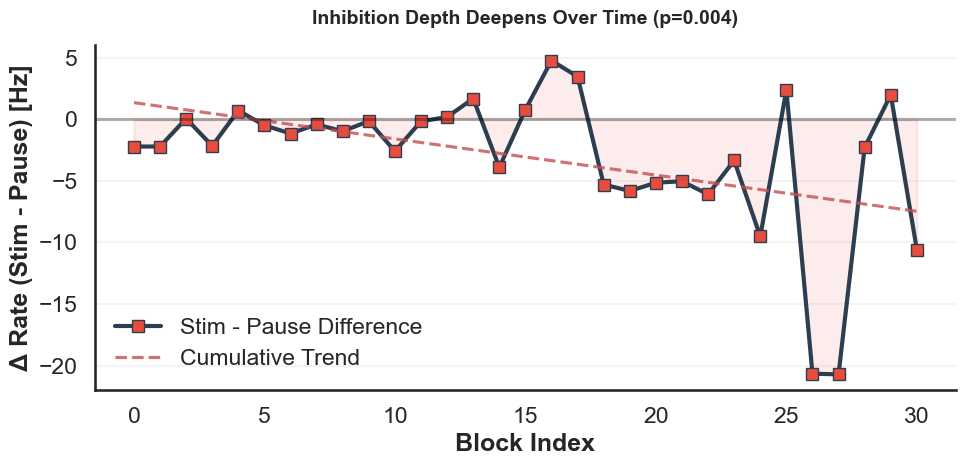

In [286]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. הכנת הנתונים וחישוב ממוצעים לכל בלוק ומצב
df_plot = full_df_raw[full_df_raw['Group'] == 'Stimulation'].copy()
stats = df_plot.groupby(['Block_Idx', 'Is_Stim'])['Rate'].mean().unstack()

# 2. טיפול בערכים חסרים - מילוי קדימה/אחורה כדי שיהיה לנו זוג להשוואה בכל נקודת זמן
# (זה מבטיח שגם אם בלוק מסוים הוא רק Stim, נשווה אותו לפאוזה הכי קרובה אליו)
stats_filled = stats.ffill().bfill()
stats_filled['Delta'] = stats_filled[1] - stats_filled[0]

# 3. ניקוי סופי של ערכים שלא הצליחו להתחבר
delta_series = stats_filled['Delta'].dropna()

# 4. ציור הגרף
plt.figure(figsize=(10, 5))

# קו הדלתא
plt.plot(delta_series.index, delta_series.values, marker='s', 
         color='#2c3e50', linewidth=3, markersize=8, 
         markerfacecolor='#e74c3c', label='Stim - Pause Difference')

# הוספת קו מגמה (Trendline) כדי להדגיש את האפקט המצטבר
z = np.polyfit(delta_series.index, delta_series.values, 1)
p = np.poly1d(z)
plt.plot(delta_series.index, p(delta_series.index), "r--", alpha=0.8, label='Cumulative Trend')

# עיצוב
plt.axhline(0, color='black', linestyle='-', alpha=0.3) # קו ה-0 (אין הבדל)
plt.fill_between(delta_series.index, 0, delta_series.values, color='#e74c3c', alpha=0.1)

plt.title('Inhibition Depth Deepens Over Time (p=0.004)', fontweight='bold', fontsize=14, pad=15)
plt.ylabel('Δ Rate (Stim - Pause) [Hz]', fontweight='bold')
plt.xlabel('Block Index', fontweight='bold')
plt.legend(frameon=False)

# ניקוי מסגרת
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.gca().spines['left'].set_visible(True)
plt.gca().spines['bottom'].set_visible(True)

plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

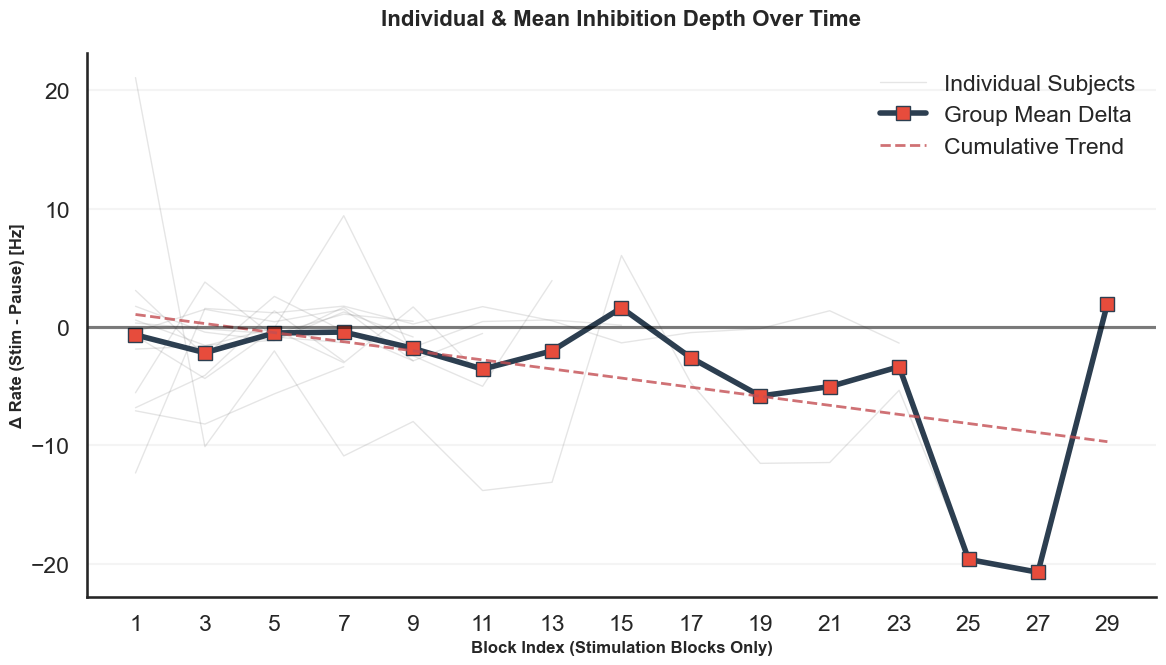

In [288]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. סינון לקבוצת הגירוי בלבד
df_stim = full_df_raw[full_df_raw['Group'] == 'Stimulation'].copy()

# 2. חישוב דלתא לכל נבדק בנפרד
subject_data = []
all_stim_indices = sorted(df_stim[df_stim['Is_Stim'] == 1]['Block_Idx'].unique())

for subj in df_stim['Subject_ID'].unique():
    subj_df = df_stim[df_stim['Subject_ID'] == subj]
    # חישוב ממוצעים לבלוק ומצב בתוך הנבדק
    subj_stats = subj_df.groupby(['Block_Idx', 'Is_Stim'])['Rate'].mean().unstack()
    
    # מילוי חוסרים בתוך הנבדק (כדי שיהיה זוג להשוואה)
    subj_stats = subj_stats.ffill().bfill()
    
    if 1 in subj_stats.columns and 0 in subj_stats.columns:
        subj_stats['Delta'] = subj_stats[1] - subj_stats[0]
        # שומרים רק את האינדקסים של הגירוי
        delta_series = subj_stats.loc[subj_stats.index.isin(all_stim_indices), 'Delta']
        if not delta_series.dropna().empty:
            subject_data.append(delta_series)

# 3. יצירת DataFrame מרכזי לחישוב ממוצע קבוצתי
all_subjects_df = pd.concat(subject_data, axis=1)
group_mean = all_subjects_df.mean(axis=1).dropna()

# 4. ציור הגרף
plt.figure(figsize=(12, 7))

# ציור קווים לנבדקים בודדים (אפור עדין)
for i, subj_series in enumerate(subject_data):
    plt.plot(subj_series.index, subj_series.values, color='gray', alpha=0.2, linewidth=1, 
             label='Individual Subjects' if i == 0 else "")

# ציור ממוצע קבוצתי (עבה ובולט)
plt.plot(group_mean.index, group_mean.values, marker='s', color='#2c3e50', 
         linewidth=4, markersize=10, markerfacecolor='#e74c3c', label='Group Mean Delta')

# הוספת קו מגמה לממוצע הקבוצתי
if not group_mean.empty:
    z = np.polyfit(group_mean.index, group_mean.values, 1)
    p = np.poly1d(z)
    plt.plot(group_mean.index, p(group_mean.index), "r--", linewidth=2, alpha=0.8, label='Cumulative Trend')

# עיצוב
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.title('Individual & Mean Inhibition Depth Over Time', fontweight='bold', fontsize=16, pad=20)
plt.ylabel('Δ Rate (Stim - Pause) [Hz]', fontweight='bold', fontsize=12)
plt.xlabel('Block Index (Stimulation Blocks Only)', fontweight='bold', fontsize=12)

# הגדרת ציר ה-X להציג רק את אינדקסי הגירוי
plt.xticks(all_stim_indices)

plt.legend(frameon=False, loc='upper right')
plt.grid(axis='y', alpha=0.2)

# ניקוי מסגרת
for spine in plt.gca().spines.values():
    spine.set_visible(False)
plt.gca().spines['left'].set_visible(True)
plt.gca().spines['bottom'].set_visible(True)

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_41232\2088633097.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_norm = df_stim.groupby('Subject_ID', group_keys=False).apply(normalize_to_start)


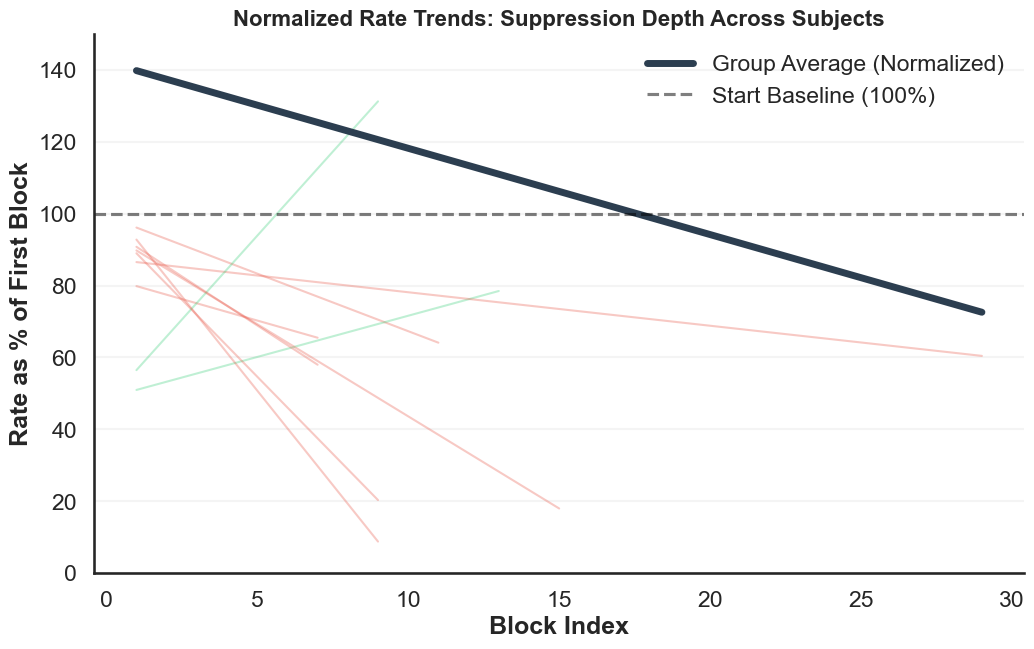

In [291]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. סינון לבלוקי גירוי בלבד
df_stim = full_df_raw[(full_df_raw['Group'] == 'Stimulation') & (full_df_raw['Is_Stim'] == 1)].copy()

# 2. נרמול: נהפוך את ה-Rate ל-% מהבלוק הראשון של כל נבדק
def normalize_to_start(group):
    first_val = group.sort_values('Block_Idx')['Rate'].iloc[0]
    group['Rate_Pct'] = (group['Rate'] / first_val) * 100
    return group

df_norm = df_stim.groupby('Subject_ID', group_keys=False).apply(normalize_to_start)

plt.figure(figsize=(12, 7))

all_normalized_trends = []

# 3. ציור קווי מגמה מנורמלים לכל נבדק
for subj in df_norm['Subject_ID'].unique():
    subj_data = df_norm[df_norm['Subject_ID'] == subj].sort_values('Block_Idx')
    if len(subj_data) > 1:
        x = subj_data['Block_Idx']
        y = subj_data['Rate_Pct']
        
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        
        color = '#e74c3c' if z[0] < 0 else '#2ecc71'
        plt.plot(x, p(x), color=color, alpha=0.3, linewidth=1.5)
        
        # נשמור את הערכים המנורמלים לחישוב ממוצע נכון
        all_normalized_trends.append(subj_data[['Block_Idx', 'Rate_Pct']])

# 4. חישוב ממוצע קבוצתי מנורמל
combined_norm = pd.concat(all_normalized_trends)
mean_norm = combined_norm.groupby('Block_Idx')['Rate_Pct'].mean().dropna()

z_mean = np.polyfit(mean_norm.index, mean_norm.values, 1)
p_mean = np.poly1d(z_mean)

plt.plot(mean_norm.index, p_mean(mean_norm.index), color='#2c3e50', linewidth=5, label='Group Average (Normalized)')

# עיצוב
plt.axhline(100, color='black', linestyle='--', alpha=0.5, label='Start Baseline (100%)')
plt.title('Normalized Rate Trends: Suppression Depth Across Subjects', fontweight='bold', fontsize=16)
plt.ylabel('Rate as % of First Block', fontweight='bold')
plt.xlabel('Block Index', fontweight='bold')
plt.ylim(0, 150) # הגבלת הציר כדי לראות את הירידה בבירור

plt.legend(frameon=False)
plt.grid(axis='y', alpha=0.2)
sns.despine()
plt.show()

Total subjects in Stimulation group: 12
Subjects included in plot (with >1 block): 12


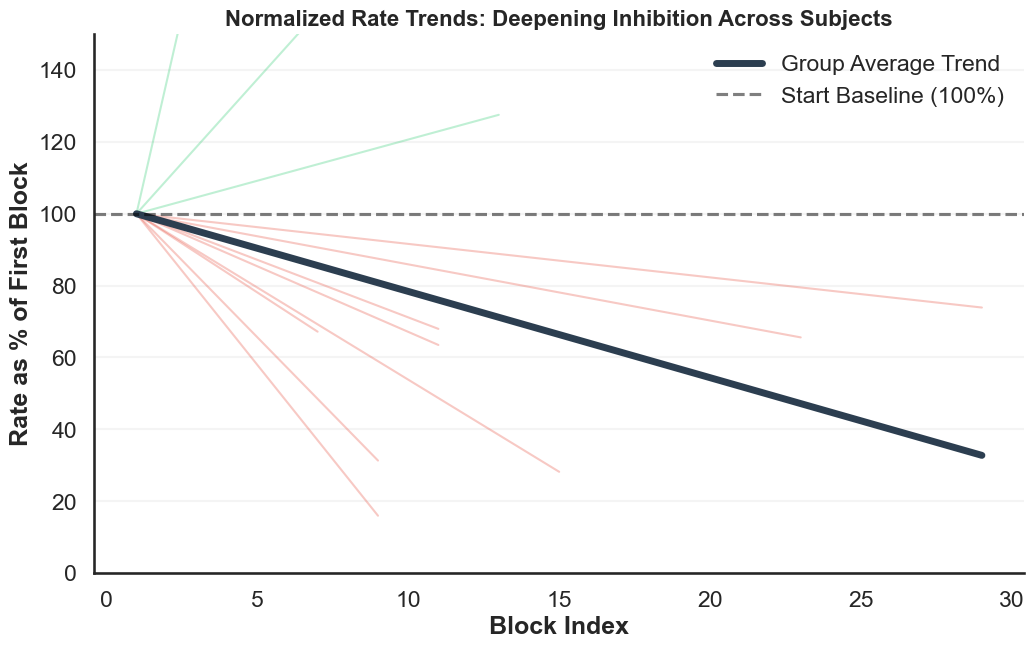

In [293]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. סינון לבלוקי גירוי בלבד
df_stim = full_df_raw[(full_df_raw['Group'] == 'Stimulation') & (full_df_raw['Is_Stim'] == 1)].copy()

# הדפסת מידע על כמות הנבדקים
initial_subjects = df_stim['Subject_ID'].unique()
print(f"Total subjects in Stimulation group: {len(initial_subjects)}")

plt.figure(figsize=(12, 7))
all_normalized_points = []
included_subjects_count = 0

# 2. ציור קווי מגמה מנורמלים
for subj in initial_subjects:
    subj_data = df_stim[df_stim['Subject_ID'] == subj].sort_values('Block_Idx')
    
    # נבדק חייב לפחות 2 נקודות כדי ליצור קו מגמה
    if len(subj_data) > 1:
        first_val = subj_data['Rate'].iloc[0]
        
        if first_val == 0: continue # מניעת חילוק ב-0
            
        subj_data['Rate_Pct'] = (subj_data['Rate'] / first_val) * 100
        
        x = subj_data['Block_Idx']
        y = subj_data['Rate_Pct']
        
        # חישוב שיפוע (Slope) בלבד
        z = np.polyfit(x, y, 1)
        slope = z[0]
        
        # --- תיקון: בניית קו שעובר ב-(first_x, 100) ---
        first_x = x.iloc[0]
        # משוואת ישר: y = slope * (x - x1) + y1
        y_trend = slope * (x - first_x) + 100
        
        color = '#e74c3c' if slope < 0 else '#2ecc71'
        plt.plot(x, y_trend, color=color, alpha=0.3, linewidth=1.5)
        
        all_normalized_points.append(subj_data[['Block_Idx', 'Rate_Pct']])
        included_subjects_count += 1

print(f"Subjects included in plot (with >1 block): {included_subjects_count}")

# 3. חישוב וציור ממוצע קבוצתי
if all_normalized_points:
    combined_norm = pd.concat(all_normalized_points)
    mean_points = combined_norm.groupby('Block_Idx')['Rate_Pct'].mean().dropna()
    
    # חישוב קו מגמה לממוצע שגם הוא מתחיל ב-100
    z_mean = np.polyfit(mean_points.index, mean_points.values, 1)
    slope_mean = z_mean[0]
    first_x_mean = mean_points.index[0]
    y_trend_mean = slope_mean * (mean_points.index - first_x_mean) + 100
    
    plt.plot(mean_points.index, y_trend_mean, color='#2c3e50', linewidth=5, label='Group Average Trend')

# עיצוב סופי
plt.axhline(100, color='black', linestyle='--', alpha=0.5, label='Start Baseline (100%)')
plt.title('Normalized Rate Trends: Deepening Inhibition Across Subjects', fontweight='bold', fontsize=16)
plt.ylabel('Rate as % of First Block', fontweight='bold')
plt.xlabel('Block Index', fontweight='bold')
plt.ylim(0, 150)
plt.legend(frameon=False)
plt.grid(axis='y', alpha=0.2)
sns.despine()
plt.show()

Subjects with baseline and stimulation data: 12


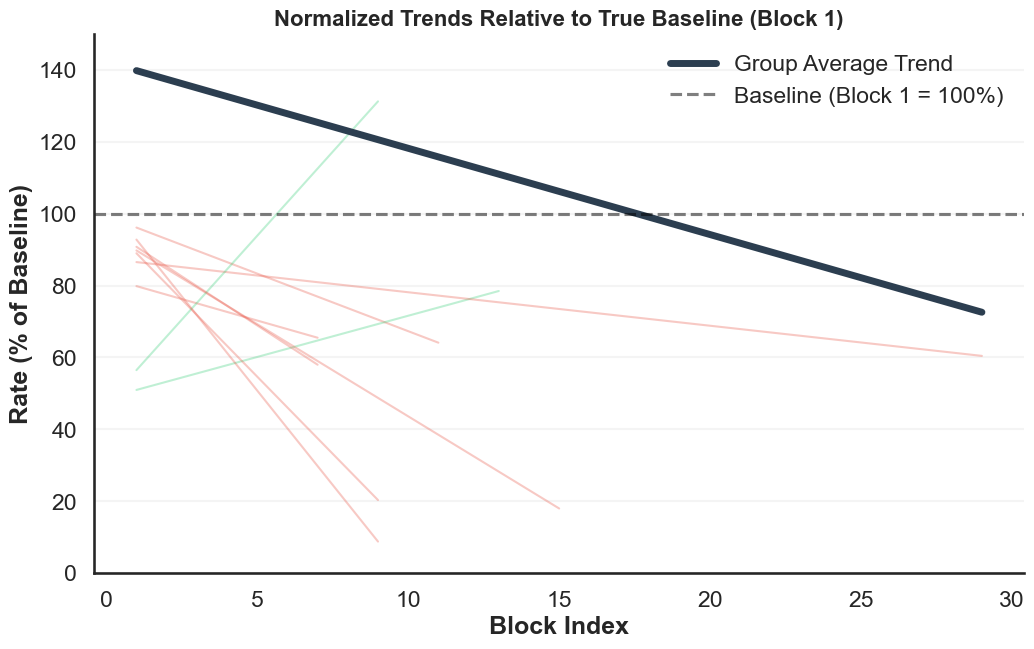

In [295]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. שליפת ערכי הבייסליין (בלוק 1) לכל נבדק
baselines = full_df_raw[full_df_raw['Block_Idx'] == 1][['Subject_ID', 'Rate']].rename(columns={'Rate': 'Baseline_Value'})

# 2. סינון לבלוקי גירוי בלבד בקבוצת הגירוי
df_stim = full_df_raw[(full_df_raw['Group'] == 'Stimulation') & (full_df_raw['Is_Stim'] == 1)].copy()

# 3. חיבור הבייסליין לנתוני הגירוי
df_norm = pd.merge(df_stim, baselines, on='Subject_ID', how='left')

plt.figure(figsize=(12, 7))
all_normalized_points = []
included_count = 0

# 4. חישוב אחוזים וציור מגמות
for subj in df_norm['Subject_ID'].unique():
    subj_data = df_norm[df_norm['Subject_ID'] == subj].sort_values('Block_Idx')
    
    # בדיקה שיש בייסליין ושיש לפחות גירוי אחד
    base_val = subj_data['Baseline_Value'].iloc[0]
    
    if pd.notnull(base_val) and base_val > 0:
        # נרמול כל ה-Rate לבייסליין (בלוק 1)
        subj_data['Rate_Pct'] = (subj_data['Rate'] / base_val) * 100
        
        x = subj_data['Block_Idx']
        y = subj_data['Rate_Pct']
        
        if len(x) > 1:
            z = np.polyfit(x, y, 1)
            slope = z[0]
            
            # יצירת קו המגמה (חופשי, לא כפוי ל-100 כי ה-100 הוא בבלוק 1 שלא בגרף)
            p = np.poly1d(z)
            
            color = '#e74c3c' if slope < 0 else '#2ecc71'
            plt.plot(x, p(x), color=color, alpha=0.3, linewidth=1.5)
            
            all_normalized_points.append(subj_data[['Block_Idx', 'Rate_Pct']])
            included_count += 1

print(f"Subjects with baseline and stimulation data: {included_count}")

# 5. קו ממוצע קבוצתי
if all_normalized_points:
    combined_norm = pd.concat(all_normalized_points)
    mean_pts = combined_norm.groupby('Block_Idx')['Rate_Pct'].mean().dropna()
    
    z_mean = np.polyfit(mean_pts.index, mean_pts.values, 1)
    p_mean = np.poly1d(z_mean)
    plt.plot(mean_pts.index, p_mean(mean_pts.index), color='#2c3e50', linewidth=5, label='Group Average Trend')

# עיצוב
plt.axhline(100, color='black', linestyle='--', alpha=0.5, label='Baseline (Block 1 = 100%)')
plt.title('Normalized Trends Relative to True Baseline (Block 1)', fontweight='bold', fontsize=16)
plt.ylabel('Rate (% of Baseline)', fontweight='bold')
plt.xlabel('Block Index', fontweight='bold')
plt.ylim(0, 150)
plt.legend(frameon=False)
plt.grid(axis='y', alpha=0.2)
sns.despine()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_41232\3920817542.py:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_ordinal = df_only_stim.groupby('Subject_ID', group_keys=False).apply(map_to_order)


Total subjects plotted: 12


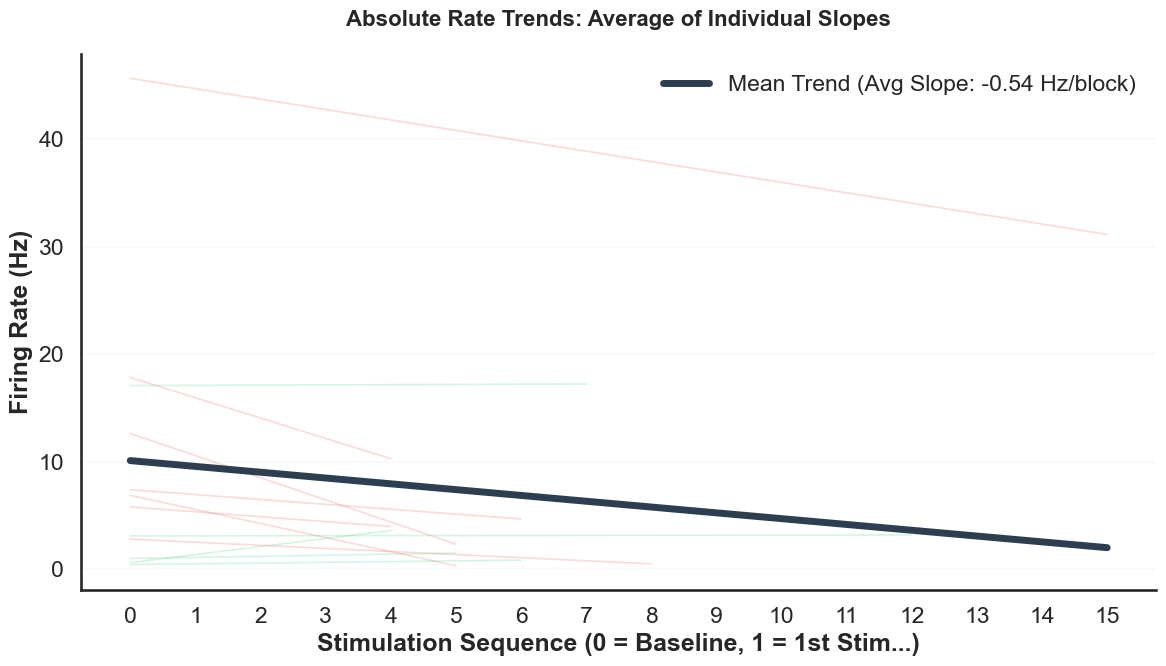

In [294]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. סינון נתונים לקבוצת הגירוי
df_stim = full_df_raw[full_df_raw['Group'] == 'Stimulation'].copy()

# 2. חילוץ בייסליין לכל נבדק (בלוק 1)
baselines = df_stim[df_stim['Block_Idx'] == 1][['Subject_ID', 'Rate']].rename(columns={'Rate': 'Baseline'})

# 3. סינון לבלוקי גירוי בלבד וסידורם בסדר רץ
df_only_stim = df_stim[df_stim['Is_Stim'] == 1].copy()
def map_to_order(group):
    group = group.sort_values('Block_Idx')
    group['Stim_Order'] = range(1, len(group) + 1)
    return group
df_ordinal = df_only_stim.groupby('Subject_ID', group_keys=False).apply(map_to_order)

# 4. מיזוג הבייסליין חזרה
df_final = pd.merge(df_ordinal, baselines, on='Subject_ID', how='left')

plt.figure(figsize=(12, 7))

slopes_list = []
start_points_list = []
included_count = 0

# 5. ציור קווי המגמה האישיים
for subj in df_final['Subject_ID'].unique():
    subj_data = df_final[df_final['Subject_ID'] == subj].sort_values('Stim_Order')
    
    # הגדרת נקודות X ו-Y (מתחיל ב-0 אם יש בייסליין, אחרת ב-1)
    has_baseline = not np.isnan(subj_data['Baseline'].iloc[0])
    
    if has_baseline:
        x_vals = np.concatenate([[0], subj_data['Stim_Order'].values])
        y_vals = np.concatenate([[subj_data['Baseline'].iloc[0]], subj_data['Rate'].values])
    else:
        x_vals = subj_data['Stim_Order'].values
        y_vals = subj_data['Rate'].values
        
    if len(x_vals) > 1:
        # חישוב שיפוע אישי
        z = np.polyfit(x_vals, y_vals, 1)
        slope = z[0]
        slopes_list.append(slope)
        start_points_list.append(y_vals[0])
        
        # בניית קו המגמה שיוצא מהנקודה הראשונה
        y_trend = slope * (x_vals - x_vals[0]) + y_vals[0]
        
        # צבע לפי כיוון השיפוע
        color = '#e74c3c' if slope < 0 else '#2ecc71'
        plt.plot(x_vals, y_trend, color=color, alpha=0.2, linewidth=1.2)
        included_count += 1

# 6. חישוב וציור הקו הממוצע (ממוצע השיפועים)
if slopes_list:
    avg_slope = np.mean(slopes_list)
    avg_start_y = np.mean(start_points_list)
    
    max_x = int(df_final['Stim_Order'].max())
    x_range = np.linspace(0, max_x, 100)
    # הקו הממוצע משתמש בממוצע השיפועים וממוצע נקודות ההתחלה
    y_mean_trend = avg_slope * x_range + avg_start_y
    
    plt.plot(x_range, y_mean_trend, color='#2c3e50', linewidth=5, 
             label=f'Mean Trend (Avg Slope: {avg_slope:.2f} Hz/block)')

print(f"Total subjects plotted: {included_count}")

# עיצוב
plt.title('Absolute Rate Trends: Average of Individual Slopes', fontweight='bold', fontsize=16, pad=20)
plt.ylabel('Firing Rate (Hz)', fontweight='bold')
plt.xlabel('Stimulation Sequence (0 = Baseline, 1 = 1st Stim...)', fontweight='bold')
plt.xticks(range(0, max_x + 1))
plt.legend(frameon=False)
plt.grid(axis='y', alpha=0.1)
sns.despine()
plt.tight_layout()
plt.show()

## Figure 3

In [60]:
no_base = joblib.load('no_base_515_545.pkl')
no_base['relative_spike_amplitude']['all']  # בדיקה שהנתונים נטענו כראוי

[[5.0776607376721845,
  0.7549513677110946,
  1.3743995776704292,
  1.2705288885251047,
  2.7550082402852976,
  1.1328717185721837,
  1.831602463115375,
  1.2882814670938028,
  1.2411934783934906,
  1.424039874317983,
  1.7952670597939915,
  1.2711867083169812,
  0.9674750126324017],
 [5.716396515969416,
  5.008920075957256,
  6.2553821296456205,
  3.2208303480034655,
  5.0335565432186,
  3.905628663282357,
  4.165182833360674,
  5.031971921366808,
  2.5918809509560026,
  7.0801932186582475,
  3.307345902800275]]

In [61]:
import pandas as pd
import statsmodels.formula.api as smf

# --- 1. איחוד ועיבוד נתונים (כולל no_base) ---

def get_long_format_data(data_dict, group_name, feature_key, is_no_base=False):
    raw_data = data_dict[feature_key]['all']
    rows = []
    for sub_idx, sub_values in enumerate(raw_data):
        for block_idx, value in enumerate(sub_values):
            rows.append({
                'Subject_ID': f"{group_name}_{'NB_' if is_no_base else ''}{sub_idx}",
                'Group': group_name,
                'Block_Idx': block_idx,
                'Is_Stim': 1 if block_idx % 2 != 0 else 0,
                'Value': value
            })
    return pd.DataFrame(rows)

# הכנת הנתונים
df_rate_all = pd.concat([
    get_long_format_data(data_stim, 'Stimulation', 'rates', False),
    get_long_format_data(no_base, 'Stimulation', 'rates', True)
])

df_amp_all = pd.concat([
    get_long_format_data(data_stim, 'Stimulation', 'relative_spike_amplitude', False),
    get_long_format_data(no_base, 'Stimulation', 'relative_spike_amplitude', True)
])

# סינון: רק בלוקים אקטיביים (>0) ואיפוס אינדקס (reset_index) - זה השלב שפותר את השגיאה
df_rate_active = df_rate_all[df_rate_all['Block_Idx'] > 0].reset_index(drop=True)
df_amp_active = df_amp_all[df_amp_all['Block_Idx'] > 0].reset_index(drop=True)

# --- 2. הרצת המודלים (ללא שגיאות אינדקס) ---

print("=== FIRING RATE RESULTS (Stimulation Only, Blocks > 0) ===")
# מודל פשוט
model_rate_simple = smf.mixedlm("Value ~ Is_Stim", df_rate_active, groups=df_rate_active["Subject_ID"]).fit()
print(model_rate_simple.summary())

# מודל עם זמן
model_rate_time = smf.mixedlm("Value ~ Is_Stim + Block_Idx", df_rate_active, groups=df_rate_active["Subject_ID"]).fit()
print(model_rate_time.summary())

=== FIRING RATE RESULTS (Stimulation Only, Blocks > 0) ===
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value    
No. Observations: 162     Method:             REML     
No. Groups:       12      Scale:              18.5625  
Min. group size:  8       Log-Likelihood:     -488.3318
Max. group size:  30      Converged:          Yes      
Mean group size:  13.5                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     8.782    2.960  2.967 0.003  2.981 14.583
Is_Stim      -1.555    0.677 -2.297 0.022 -2.882 -0.228
Group Var   102.112   10.552                           

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value    
No. Observations: 162     Method:             REML     
No. Groups:       12      Scale:              17.9030  
Min. g

In [59]:
df_rate_active

,Subject_ID,Group,Block_Idx,Is_Stim,Value
0,Stimulation_0,Stimulation,1,1,5.796996
1,Stimulation_0,Stimulation,2,0,7.005146
2,Stimulation_0,Stimulation,3,1,2.921098
3,Stimulation_0,Stimulation,4,0,2.064271
4,Stimulation_0,Stimulation,5,1,3.434616
...,...,...,...,...,...
157,Stimulation_NB_1,Stimulation,6,0,1.678896
158,Stimulation_NB_1,Stimulation,7,1,2.950402
159,Stimulation_NB_1,Stimulation,8,0,1.357743
160,Stimulation_NB_1,Stimulation,9,1,0.520380


In [55]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. איחוד מחדש של נתוני האמפליטודה (כולל no_base)
df_amp_all = pd.concat([
    get_long_format_data(data_stim, 'Stimulation', 'relative_spike_amplitude', False),
    get_long_format_data(no_base, 'Stimulation', 'relative_spike_amplitude', True)
])

# 2. סינון בלוקים אקטיביים והסרת NaN (קריטי לפני איפוס אינדקס)
df_amp_active = df_amp_all[df_amp_all['Block_Idx'] > 0].dropna(subset=['Value']).copy()

# 3. איפוס אינדקס כפול כדי להבטיח שאין שום קשר לאינדקס הישן
df_amp_active = df_amp_active.reset_index(drop=True)

print("=== AMPLITUDE RESULTS (Stimulation Only, Blocks > 0) ===")

# מודל פשוט
model_amp_simple = smf.mixedlm("Value ~ Is_Stim", 
                               df_amp_active, 
                               groups=df_amp_active["Subject_ID"]).fit()
print("\n--- Simple Model (Stim vs Pause) ---")
print(model_amp_simple.summary())

# מודל עם זמן
model_amp_time = smf.mixedlm("Value ~ Is_Stim + Block_Idx", 
                             df_amp_active, 
                             groups=df_amp_active["Subject_ID"]).fit()
print("\n--- Model with Time (Block_Idx) ---")
print(model_amp_time.summary())

=== AMPLITUDE RESULTS (Stimulation Only, Blocks > 0) ===

--- Simple Model (Stim vs Pause) ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value    
No. Observations: 161     Method:             REML     
No. Groups:       12      Scale:              0.4575   
Min. group size:  8       Log-Likelihood:     -187.0281
Max. group size:  30      Converged:          Yes      
Mean group size:  13.4                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     3.135    0.326  9.628 0.000  2.497  3.773
Is_Stim      -0.166    0.107 -1.557 0.119 -0.375  0.043
Group Var     1.198    0.806                           


--- Model with Time (Block_Idx) ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value    
No. Observations: 161     Method:            

In [56]:
df_amp_active

,Subject_ID,Group,Block_Idx,Is_Stim,Value
0,Stimulation_0,Stimulation,1,1,3.397493
1,Stimulation_0,Stimulation,2,0,3.726531
2,Stimulation_0,Stimulation,3,1,4.994247
3,Stimulation_0,Stimulation,4,0,3.772729
4,Stimulation_0,Stimulation,5,1,2.303360
...,...,...,...,...,...
156,Stimulation_NB_1,Stimulation,6,0,4.165183
157,Stimulation_NB_1,Stimulation,7,1,5.031972
158,Stimulation_NB_1,Stimulation,8,0,2.591881
159,Stimulation_NB_1,Stimulation,9,1,7.080193


In [78]:
df_amp_active.to_csv('frontal_and_control_amp_blocks_v2.csv', index=False)

In [76]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

# 1. פונקציית נירמול משופרת (פותרת את בעיית האינדקס וה-NaN)
def normalize_to_pause_mean_safe(df):
    # סינון בלוקים אקטיביים והסרת שורות ריקות ב-Value
    df_active = df[df['Block_Idx'] > 0].dropna(subset=['Value']).copy()
    
    normalized_rows = []
    for sub in df_active['Subject_ID'].unique():
        sub_data = df_active[df_active['Subject_ID'] == sub].copy()
        
        # חישוב ממוצע הפסקות לנבדק
        pause_data = sub_data[sub_data['Is_Stim'] == 0]['Value']
        if not pause_data.empty:
            pause_mean = pause_data.mean()
            if pause_mean > 0:
                sub_data['Value_Norm'] = (sub_data['Value'] / pause_mean) * 100
                normalized_rows.append(sub_data)
            
    # איחוד מחדש ואיפוס אינדקס קריטי למניעת IndexError
    return pd.concat(normalized_rows).reset_index(drop=True)

# 2. הכנת הנתונים מחדש
df_rate_norm = normalize_to_pause_mean_safe(df_rate_all)
df_amp_norm = normalize_to_pause_mean_safe(df_amp_all)

# 3. פונקציה להרצת המודלים
def run_final_models(df, label):
    print(f"\n{'='*25} {label} {'='*25}")
    
    # מודל פשוט
    try:
        res_simple = smf.mixedlm("Value_Norm ~ Is_Stim", df, groups=df["Subject_ID"]).fit()
        print("\n--- Simple Model Summary ---")
        print(res_simple.summary())
    except Exception as e:
        print(f"Simple model error: {e}")

    # מודל עם זמן
    try:
        res_time = smf.mixedlm("Value_Norm ~ Is_Stim + Block_Idx", df, groups=df["Subject_ID"]).fit()
        print("\n--- Model with Time Summary ---")
        print(res_time.summary())
    except Exception as e:
        print(f"Time model error: {e}")

# הרצה סופית
run_final_models(df_rate_norm, "FIRING RATE (NORMALIZED)")
run_final_models(df_amp_norm, "AMPLITUDE (NORMALIZED)")


========================= FIRING RATE (NORMALIZED) =========================


C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)



--- Simple Model Summary ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value_Norm
No. Observations: 162     Method:             REML      
No. Groups:       12      Scale:              2661.6424 
Min. group size:  8       Log-Likelihood:     -862.3605 
Max. group size:  30      Converged:          Yes       
Mean group size:  13.5                                  
--------------------------------------------------------
            Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------
Intercept  100.000    5.365 18.640 0.000  89.485 110.515
Is_Stim     -2.076    8.107 -0.256 0.798 -17.965  13.813
Group Var    0.000                                      


C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)



--- Model with Time Summary ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value_Norm
No. Observations: 162     Method:             REML      
No. Groups:       12      Scale:              2606.0663 
Min. group size:  8       Log-Likelihood:     -859.7603 
Max. group size:  30      Converged:          Yes       
Mean group size:  13.5                                  
--------------------------------------------------------
            Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------
Intercept  111.841    7.982 14.011 0.000  96.196 127.487
Is_Stim     -3.341    8.043 -0.415 0.678 -19.105  12.423
Block_Idx   -1.265    0.583 -2.169 0.030  -2.409  -0.122
Group Var    0.000                                      


========================= AMPLITUDE (NORMALIZED) =========================


C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(



--- Simple Model Summary ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value_Norm
No. Observations: 161     Method:             REML      
No. Groups:       12      Scale:              535.2717  
Min. group size:  8       Log-Likelihood:     -731.1107 
Max. group size:  30      Converged:          No        
Mean group size:  13.4                                  
--------------------------------------------------------
            Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------
Intercept   99.810    2.846 35.067 0.000  94.232 105.389
Is_Stim     -6.362    3.647 -1.744 0.081 -13.511   0.787
Group Var   14.415    0.951                             


--- Model with Time Summary ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value_Norm
No. Observations: 161     Method:             REML      
No. Groups:       12      Scale:            

C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2207: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2219: ConvergenceWarning: Gradient optimization failed, |grad| = 1.922572
  warnings.warn(msg, ConvergenceWarning)


In [82]:
import pandas as pd
import statsmodels.formula.api as smf

def run_hierarchical_pct_model(df_input, label):
    # 1. נרמול לכל נבדק לפי ממוצע הפסקות
    normalized_list = []
    for sub in df_input['Subject_ID'].unique():
        sub_data = df_input[df_input['Subject_ID'] == sub].copy()
        pause_mean = sub_data[sub_data['Is_Stim'] == 0]['Value'].mean()
        if pause_mean > 0:
            # הנוסחה: ((ערך - ממוצע הפסקות) / ממוצע הפסקות) * 100
            sub_data['pct_norm_block'] = ((sub_data['Value'] - pause_mean) / pause_mean) * 100
            normalized_list.append(sub_data)
    
    df_norm = pd.concat(normalized_list)
    
    # 2. התיקון הקריטי: הסרת NaNs ואיפוס אינדקס רציף (למניעת IndexError)
    df_norm = df_norm.dropna(subset=['pct_norm_block']).reset_index(drop=True)
    
    # 3. הרצת המודל
    print(f"\n{'='*20} {label} HIERARCHICAL MODEL {'='*20}")
    model = smf.mixedlm("pct_norm_block ~ Is_Stim", df_norm, groups=df_norm["Subject_ID"]).fit()
    print(model.summary())
    return model

# לשימוש על קובץ האמפליטודה:
df_amp = pd.read_csv('frontal_and_control_amp_blocks_v2.csv')
model_amp = run_hierarchical_pct_model(df_amp, "AMPLITUDE")


==================== AMPLITUDE HIERARCHICAL MODEL ====================


C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_norm_block
No. Observations: 161     Method:             REML          
No. Groups:       12      Scale:              535.2717      
Min. group size:  8       Log-Likelihood:     -731.1107     
Max. group size:  30      Converged:          No            
Mean group size:  13.4                                      
-------------------------------------------------------------
             Coef.   Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------
Intercept    -0.190     2.846  -0.067  0.947   -5.768   5.389
Is_Stim      -6.362     3.647  -1.744  0.081  -13.511   0.787
Group Var    14.415     0.951                                


C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2207: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2219: ConvergenceWarning: Gradient optimization failed, |grad| = 1.922572
  warnings.warn(msg, ConvergenceWarning)


In [102]:
df_amp

,subject_id,group_label,block_type,block_index,relative_spike_amplitude
0,485,stimulation,stimuli_block,0,3.397493
1,485,stimulation,pause_block,0,3.726531
2,485,stimulation,stimuli_block,1,4.994247
3,485,stimulation,pause_block,1,3.772729
4,485,stimulation,stimuli_block,2,2.303360
...,...,...,...,...,...
290,417,control,stimuli_block,5,2.759081
291,417,control,pause_block,5,2.953844
292,417,control,stimuli_block,6,2.794032
293,417,control,pause_block,6,2.319222


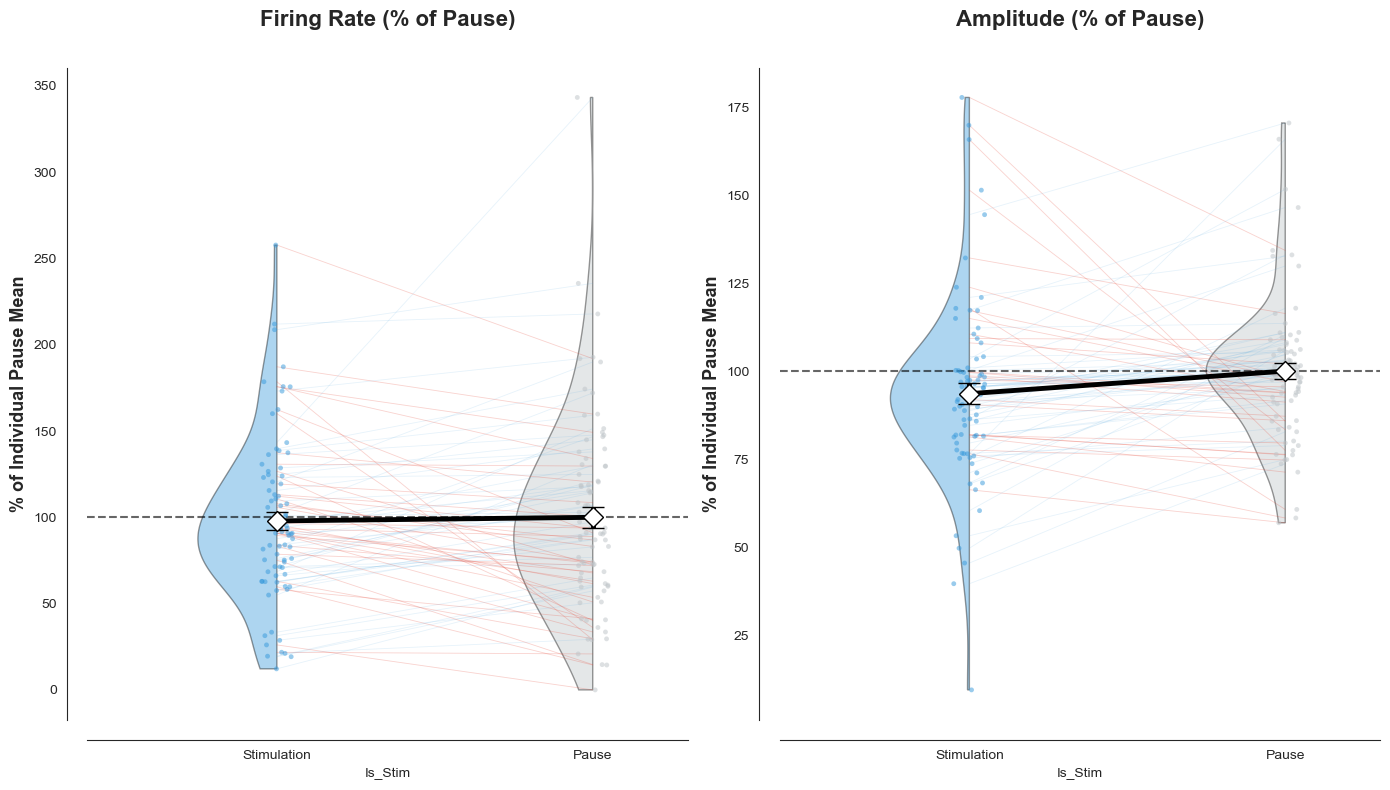

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_percentage_raincloud(df_rate, df_amp):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
    
    stim_color = '#3498db'  # כחול לגירוי
    pause_color = '#bdc3c7' # אפור להפסקה
    down_line_color = '#e74c3c'  # אדום בהיר לירידה
    up_line_color = '#5dade2'    # כחול בהיר לעלייה
    
    palette = [stim_color, pause_color]
    order = [1, 0] 
    
    for ax, df, title, ylabel in zip([ax1, ax2], 
                                     [df_rate, df_amp], 
                                     ['Firing Rate (% of Pause)', 'Amplitude (% of Pause)'],
                                     ['% of Individual Pause Mean', '% of Individual Pause Mean']):
        
        # --- 1. נירמול לאחוזים: (Value / Pause_Mean) * 100 ---
        df_norm = df.copy()
        for sub in df_norm['Subject_ID'].unique():
            sub_mask = df_norm['Subject_ID'] == sub
            pause_mean = df_norm.loc[sub_mask & (df_norm['Is_Stim'] == 0), 'Value'].mean()
            
            # מניעת חלוקה ב-0 במקרה של נוירון שקצבו אפס (נדיר אבל חשוב)
            if pause_mean != 0:
                df_norm.loc[sub_mask, 'Perc_Value'] = (df_norm.loc[sub_mask, 'Value'] / pause_mean) * 100
            else:
                df_norm.loc[sub_mask, 'Perc_Value'] = np.nan

        # 2. ציור חצאי כינור (Clouds)
        from scipy.stats import gaussian_kde
        for i, grp_val in enumerate(order):
            grp_data = df_norm[df_norm['Is_Stim'] == grp_val]['Perc_Value'].dropna()
            if len(grp_data) < 2: continue
            
            kde = gaussian_kde(grp_data, bw_method=0.4)
            y_domain = np.linspace(grp_data.min(), grp_data.max(), 500)
            density = (kde(y_domain) / kde(y_domain).max()) * 0.25
            
            x_vals = np.concatenate([np.full_like(y_domain, i), (np.full_like(y_domain[::-1], i) - density[::-1])])
            y_vals = np.concatenate([y_domain, y_domain[::-1]])
            
            poly = plt.Polygon(np.column_stack([x_vals, y_vals]), 
                               facecolor=palette[i], edgecolor='black', alpha=0.4, zorder=0)
            ax.add_patch(poly)

        # 3. ציור נקודות (Rain) - Jitter צר
        sns.stripplot(data=df_norm, x='Is_Stim', y='Perc_Value', ax=ax, 
                      order=order, palette=palette, size=3.5, alpha=0.5, 
                      zorder=1, jitter=0.05)

        # 4. חיבור בלוקים בקווים מותנים
        subjects = df_norm['Subject_ID'].unique()
        for sub in subjects:
            sub_data = df_norm[df_norm['Subject_ID'] == sub].sort_values('Block_Idx')
            for b_idx in sub_data['Block_Idx'].unique():
                if b_idx % 2 != 0: 
                    stim_val = sub_data[sub_data['Block_Idx'] == b_idx]['Perc_Value'].values
                    pause_val = sub_data[sub_data['Block_Idx'] == b_idx + 1]['Perc_Value'].values
                    if len(stim_val) > 0 and len(pause_val) > 0:
                        if pause_val[0] < stim_val[0]: 
                            l_color, l_alpha = down_line_color, 0.25
                        else: 
                            l_color, l_alpha = up_line_color, 0.15
                            
                        ax.plot([0, 1], [stim_val[0], pause_val[0]], 
                                color=l_color, alpha=l_alpha, linewidth=0.6, zorder=0)

        # 5. ממוצע קבוצתי
        g_means = [df_norm[df_norm['Is_Stim'] == 1]['Perc_Value'].mean(), 
                   df_norm[df_norm['Is_Stim'] == 0]['Perc_Value'].mean()]
        g_sems = [df_norm[df_norm['Is_Stim'] == 1]['Perc_Value'].sem(), 
                  df_norm[df_norm['Is_Stim'] == 0]['Perc_Value'].sem()]
        
        ax.errorbar([0, 1], g_means, yerr=g_sems, fmt='-D', color='black', 
                    markerfacecolor='white', markeredgecolor='black',
                    markersize=10, linewidth=3.5, capsize=8, zorder=5)
        
        # קו ה-100% (הבייסליין של ההפסקות)
        ax.axhline(100, color='black', linestyle='--', alpha=0.6, linewidth=1.5, zorder=0)

        # עיצוב
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Stimulation', 'Pause'], fontweight='bold', fontsize=12)
        ax.set_title(title, fontweight='bold', pad=30, fontsize=16)
        ax.set_ylabel(ylabel, fontweight='bold', fontsize=13)
        sns.despine(ax=ax, offset=15)
        ax.set_xlim(-0.6, 1.3)

    plt.tight_layout()
    plt.show()

# הרצה
plot_percentage_raincloud(df_rate_active, df_amp_active)

## Fig 3

Reading 0 ... 21678999  =      0.000 ... 21678.999 secs...
Segment 1 (Start: 3188s):
  - Peak Height: 791.85 µV
  - Peak Height (Z-score): 5.71 SD
------------------------------
Segment 2 (Start: 3832s):
  - Peak Height: 403.78 µV
  - Peak Height (Z-score): 2.91 SD
------------------------------
Segment 3 (Start: 4057s):
  - Peak Height: 624.31 µV
  - Peak Height (Z-score): 4.50 SD
------------------------------
Segment 4 (Start: 4494.3s):
  - Peak Height: 367.59 µV
  - Peak Height (Z-score): 2.65 SD
------------------------------


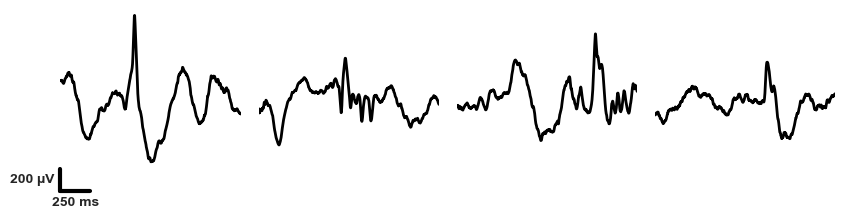

In [164]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# --------------------
# Parameters
# --------------------
subj = '515'
edf_path = rf"D:\Maya\p{subj}\P{subj}_fixed.edf"
channel_name = "RAH2"
duration = 1.5  

# הגדרות ה-Scale Bar החדשות שלך
amp_bar_val = 200     # 200 µV
time_bar_sec = 0.25   # 250 ms = 0.25 sec

start_times = [3188, 3832, 4057, 4494.3]

# --------------------
# Load and Prepare Data
# --------------------
raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
raw.pick([channel_name])
raw.load_data()

original_data_full = raw.get_data()[0] * 1e6
channel_mean = np.mean(original_data_full)
channel_std = np.std(original_data_full)
full_data_z = (original_data_full - channel_mean) / channel_std

segments_z = []
segments_uv = []

for i, t_start in enumerate(start_times):
    sfreq = raw.info['sfreq']
    start_samp = int(t_start * sfreq)
    end_samp = int((t_start + duration) * sfreq)
    
    seg_uv = original_data_full[start_samp:end_samp]
    seg_z = full_data_z[start_samp:end_samp]
    
    segments_uv.append(seg_uv)
    segments_z.append(seg_z)
    
    peak_uv = np.max(seg_uv)
    peak_z = np.max(seg_z)
    
    print(f"Segment {i+1} (Start: {t_start}s):")
    print(f"  - Peak Height: {peak_uv:.2f} µV")
    print(f"  - Peak Height (Z-score): {peak_z:.2f} SD")
    print("-" * 30)

# עכשיו אנחנו מחשבים גבולות לפי יחידות µV לצורך הציור
y_min_global = min([np.min(s) for s in segments_uv])
y_max_global = max([np.max(s) for s in segments_uv])

# --------------------
# Plot (Microvolts Units)
# --------------------
num_segments = len(segments_uv)
fig, axes = plt.subplots(nrows=1, ncols=num_segments, figsize=(2.5 * num_segments, 2.5), sharey=True)

for i, data in enumerate(segments_uv):
    ax = axes[i]
    times = np.linspace(0, duration, len(data))
    ax.plot(times, data, color="black", linewidth=2) 
    
    ax.set_ylim(y_min_global - 50, y_max_global + 50) # מרווח קטן ב-µV
    ax.set_xlim(0, duration)
    ax.set_axis_off()

# --------------------
# Scale Bar (Updated to µV and 250ms)
# --------------------
ax_ref = axes[0] 
vertical_gap = abs(y_max_global - y_min_global) * 0.2 
corner_x = 0 
corner_y = y_min_global - vertical_gap

# ציור הברים
ax_ref.plot([corner_x, corner_x], [corner_y, corner_y + amp_bar_val], 
            color="black", linewidth=3, clip_on=False, zorder=5)
ax_ref.plot([corner_x, corner_x + time_bar_sec], [corner_y, corner_y], 
            color="black", linewidth=3, clip_on=False, zorder=5)

# כיתובים מעודכנים
ax_ref.text(corner_x - 0.05, corner_y + (amp_bar_val / 2), f"{amp_bar_val} µV", 
            va="center", ha="right", fontsize=10, fontweight='bold')
ax_ref.text(corner_x + (time_bar_sec / 2), corner_y - (vertical_gap * 0.2), 
            "250 ms", va="top", ha="center", fontsize=10, fontweight='bold')

plt.subplots_adjust(bottom=0.25, wspace=0.1) 
plt.savefig("raw_examples_515_updated.pdf", bbox_inches='tight')  # שמירה ל-PDF עם הגדרות החדשות
plt.show()

Data points per block (after outlier removal):
[10, 10, 10, 10, 10, 10, 10, 10, 10, 7, 7]


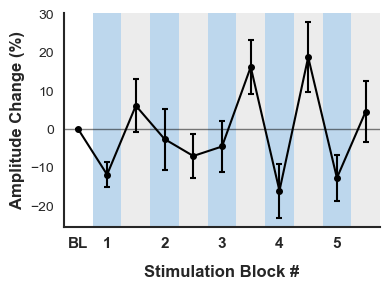

In [95]:


# --- עיבוד נתונים ---
data_list = data_stim['relative_spike_amplitude']['all']
df_cum = get_clean_matrix(data_list, mode='baseline', max_points=11, threshold=1000)   # Cumulative
df_imm = get_clean_matrix(data_list, mode='consecutive', max_points=11, threshold=1000) # Immediate

mean_cum = df_cum.mean()
sem_cum = df_cum.sem()
mean_imm = df_imm.mean()
sem_imm = df_imm.sem()
n_counts = df_cum.count() 
print("Data points per block (after outlier removal):")
print(n_counts.tolist())
x_indices = np.arange(len(mean_cum))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(4, 3))

# 1. רקע צבעוני
for j in range(1, len(mean_cum)):
    color = '#91bde1' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.6, linewidth=0)

# 2. הגדרות סטייל זהות
err_style = {'fmt': '-o', 'color': 'black', 'capsize': 2, 'markersize': 4, 
             'linewidth': 1.5, 'elinewidth': 1.5, 'capthick': 1.5}

# ציור הקווים
# ax.errorbar(x_indices, mean_cum, yerr=sem_cum, zorder=5, 
#             label='Cumulative Effect (vs. BL)', **err_style)

ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, 
            label='Immediate Effect (Block-to-Block)', **err_style)

# 3. קו אפס
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

# 4. עיצוב צירים ו-Ticks (העדכון שביקשת)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)


# תוויות ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_cum), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_cum), 2)])
ax.set_xticklabels(stim_labels, fontsize=11, fontweight='bold')

ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Amplitude Change (%)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(mean_cum) - 0.5)
ax.grid(False)

# 5. מקרא (אופציונלי להחזיר אם תרצה)
stim_patch = mpatches.Patch(color='#8db4d3', label='Stimulation Block')
pause_patch = mpatches.Patch(color='#e0e0e0', label='Pause Block')

plt.tight_layout()
plt.show()

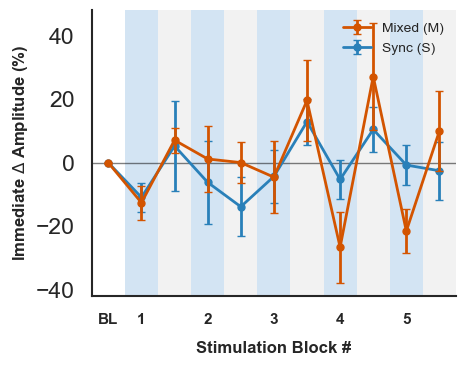

In [313]:
import matplotlib.patches as mpatches

# --- 1. הכנת הנתונים והפרדה לקבוצות ---
data_list = data_stim['relative_spike_amplitude']['all']
# קבלת המטריצה המלאה (נניח שיש בה 10 שורות לפי הסדר שציינת)
df_imm = get_clean_matrix(data_list, mode='consecutive', max_points=11, threshold=1000)

# הגדרת אינדקסים לפי הסדר: ['485', '486', '487', '488', '497', '498', '499', '505', '510', '520']
mixed_idx = [0, 4, 6, 7, 8] # נבדקי M (Mixed)
sync_idx  = [1, 2, 3, 5, 9] # נבדקי S (Sync)

# פיצול וחישוב סטטיסטיקה לכל קבוצה
def get_stats(df, indices):
    sub_df = df.iloc[indices]
    return sub_df.mean(), sub_df.sem()

mean_m, sem_m = get_stats(df_imm, mixed_idx)
mean_s, sem_s = get_stats(df_imm, sync_idx)

x_indices = np.arange(len(mean_m))

# --- 2. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(5, 4))

# רקע צבעוני (נשאר זהה)
for j in range(1, len(mean_m)):
    bg_color = '#91bde1' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=bg_color, alpha=0.4, linewidth=0)

# הגדרות סטייל לשני הקווים
# בחרתי צבעים שתואמים לבוקספלוטים הקודמים (כתום ל-Mixed, כחול ל-Sync)
style_m = {'fmt': '-o', 'color': '#d35400', 'capsize': 3, 'markersize': 5, 'linewidth': 2, 'label': 'Mixed (M)'}
style_s = {'fmt': '-o', 'color': '#2980b9', 'capsize': 3, 'markersize': 5, 'linewidth': 2, 'label': 'Sync (S)'}

# ציור הקווים
ax.errorbar(x_indices, mean_m, yerr=sem_m, zorder=5, **style_m)
ax.errorbar(x_indices, mean_s, yerr=sem_s, zorder=4, **style_s)

# --- 3. עיצוב וצירים ---
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# תוויות ציר X (דילוג על בלוקי ה-Pause כדי להציג רק מספר סבב גירוי)
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_m), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_m), 2)])
ax.set_xticklabels(stim_labels, fontsize=11, fontweight='bold')

ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Immediate $\Delta$ Amplitude (%)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(mean_m) - 0.5)

# הוספת מקרא
ax.legend(frameon=False, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

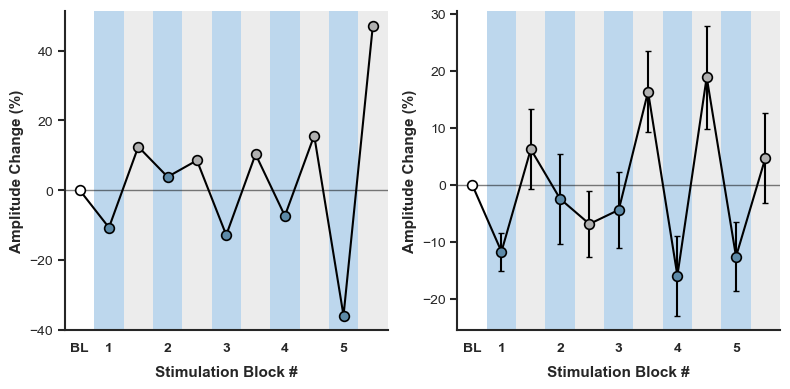

In [110]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# --- 1. הכנת נתונים ---
# א. נתוני כל הקבוצה (כפי שחושבו קודם)
# mean_imm, sem_imm

# ב. נתוני נבדק 7 (Subject 499)
raw_sub7 = data_stim['relative_spike_amplitude']['all'][7]
pct_sub7 = [0]
for i in range(1, len(raw_sub7)):
    prev = raw_sub7[i-1]
    curr = raw_sub7[i]
    pct_sub7.append(((curr - prev) / prev) * 100 if prev != 0 else 0)

# --- 2. הגדרות עיצוב משותפות ---
stim_bg = '#91bde1'
stim_marker = '#5d8aa8'
pause_bg = '#e0e0e0'
pause_marker = '#b0b0b0'

def style_ax(ax, title):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', direction='out', length=5, width=1.5, left=True)
    # ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel('Amplitude Change (%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Stimulation Block #', fontsize=11, fontweight='bold', labelpad=8)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

# --- 3. יצירת הגרף המאוחד ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

for ax, data, errors, title in zip([ax1, ax2], 
                                   [pct_sub7, mean_imm], 
                                   [None, sem_imm], 
                                   ['Representative Subject', 'Group Average']):
    
    x_idx = np.arange(len(data))
    
    # רקע וצבעי מרקרים
    marker_colors = [pause_marker]
    for j in range(1, len(data)):
        if j % 2 != 0:
            ax.axvspan(j - 0.5, j + 0.5, color=stim_bg, alpha=0.6, linewidth=0)
            marker_colors.append(stim_marker)
        else:
            ax.axvspan(j - 0.5, j + 0.5, color=pause_bg, alpha=0.6, linewidth=0)
            marker_colors.append(pause_marker)
            
    # קו זיגזג
    ax.plot(x_idx, data, color='black', linewidth=1.5, zorder=3)
    
    # Errorbars (רק לגרף הממוצע)
    if errors is not None:
        ax.errorbar(x_idx, data, yerr=errors, fmt='none', color='black', 
                    linewidth=1.5, elinewidth=1.5, capsize=2, zorder=4)
        
    # נקודות (Opaque)
    for i in range(len(x_idx)):
        # BL לבן כפי שביקשת בקוד האחרון
        f_color = 'white' if i == 0 else marker_colors[i]
        ax.plot(x_idx[i], data[i], marker='o', markersize=7, 
                markerfacecolor=f_color, markeredgecolor='black', 
                markeredgewidth=1.2, zorder=10)
    
    # עיצוב צירים
    style_ax(ax, title)
    stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(data), 2)]
    ax.set_xticks([0] + [i for i in range(1, len(data), 2)])
    ax.set_xticklabels(stim_labels, fontsize=10, fontweight='bold')
    ax.set_xlim(-0.5, len(data) - 0.5)

plt.tight_layout()
plt.savefig('zigzag_499_and_group.pdf', dpi=300)
plt.show()

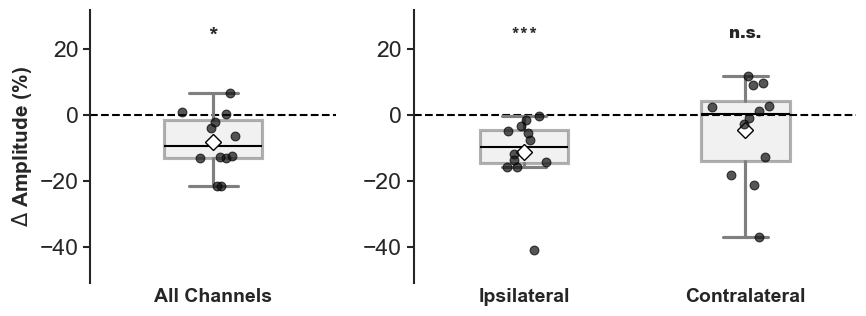

In [124]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import utils

# הגדרות בסיס
base_path = r"D:\Ofer_backup\V6_model"
target_param = "relative_spike_amplitude"

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

def compute_pct_change_pause_vs_stim(data, index_cols, feats):
    cond_order = ["pause_block", "stimuli_block"]
    data_ps = data[data["stimuli_flag"].isin(cond_order)].copy()
    data_ps = data_ps.groupby(index_cols + ["stimuli_flag"])[feats].mean().reset_index()
    df_pivot = data_ps.pivot(index=index_cols, columns="stimuli_flag", values=feats)
    pct_change_df = pd.DataFrame(index=df_pivot.index)
    for feat in feats:
        val_pause = df_pivot[(feat, "pause_block")]
        val_stim  = df_pivot[(feat, "stimuli_block")]
        ok = val_pause.notna() & (val_pause != 0) & val_stim.notna()
        pct_change_df.loc[ok, feat] = ((val_stim[ok] - val_pause[ok]) / val_pause[ok]) * 100
    return pct_change_df.melt(var_name="Parameter", value_name="Percent_Change", ignore_index=False).reset_index()

# ----------------------------------------------------
# 1. עיבוד נתונים
# ----------------------------------------------------
all_data_lat, all_data_all = [], []
subject_ids_to_run = [x for x in subjects if x not in ['5101','541', '544']]

for subj in subject_ids_to_run:
    feat_path = os.path.join(base_path, f"p{subj}", "unichannel_model", "min_amplitude_1", "features", f"p{subj}_flat_features.csv")
    if not os.path.exists(feat_path): continue
    
    df = pd.read_csv(feat_path)
    df = df.drop_duplicates(subset="group", keep="first")
    
    ann_path = fr"D:\Maya\clean Stim Project\P{subj}\P{subj}_annotations_ms.csv"
    try:
        df = utils.remove_noisy_samples_and_channels(subj, df, ann_path, ts_col="timestamp", channel_col="channel")
    except: continue
    
    df["subject_id"] = subj
    stim = stim_side.get(str(subj))
    df["chan_side"] = df["channel"].astype(str).str[0]
    df_lat = df[df["chan_side"].isin(["R", "L"])].copy()
    
    if stim:
        df_lat["lat_group"] = np.where(df_lat["chan_side"] == stim, "ipsi", "contra")
        all_data_lat.append(df_lat.groupby(["subject_id", "stimuli_flag", "lat_group"], as_index=False)[[target_param]].mean())
        all_data_all.append(df_lat.groupby(["subject_id", "stimuli_flag"], as_index=False)[[target_param]].mean())

df_plot_lat = compute_pct_change_pause_vs_stim(pd.concat(all_data_lat), ["subject_id", "lat_group"], [target_param])
df_plot_all = compute_pct_change_pause_vs_stim(pd.concat(all_data_all), ["subject_id"], [target_param])

# ----------------------------------------------------
# 2. ויזואליזציה
# ----------------------------------------------------
sns.set(style="white", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5), gridspec_kw={'width_ratios': [1, 1.8]})

min_y = min(df_plot_all["Percent_Change"].min(), df_plot_lat["Percent_Change"].min()) - 10
max_y = max(df_plot_all["Percent_Change"].max(), df_plot_lat["Percent_Change"].max()) + 20

# הגדרות בוקספלוט משותפות
box_style = dict(width=0.4, color="lightgray", showmeans=True, showfliers=False, zorder=2,
                 meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":8},
                 boxprops=dict(alpha=0.3, edgecolor="black"), medianprops=dict(color="black", linewidth=1.5))

# --- גרף שמאל ---
vals_all = df_plot_all["Percent_Change"].dropna()
ax1.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)
sns.boxplot(y=vals_all, ax=ax1, **box_style)
ax1.scatter(np.random.default_rng(6).normal(0, 0.05, size=len(vals_all)), vals_all, s=40, c="#100f0d", alpha=0.7, edgecolors="black", zorder=3, linewidths=0.8)

_, p_all = wilcoxon(vals_all)
ax1.text(0, max_y - 5, f"{p_to_stars(p_all)}", ha="center", va="top", fontsize=15, fontweight='heavy')
ax1.set_xticklabels(["All Channels"], fontsize=14, fontweight='bold')

# --- גרף ימין ---
df_plot_final = df_plot_lat.copy()
ax2.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)
sns.boxplot(data=df_plot_final, x="lat_group", y="Percent_Change", order=["ipsi", "contra"], ax=ax2, **box_style)

for i, grp in enumerate(["ipsi", "contra"]):
    vals = df_plot_final[df_plot_final["lat_group"] == grp]["Percent_Change"].dropna().values
    ax2.scatter(np.random.default_rng(5+i).normal(i, 0.06, size=len(vals)), vals, s=40, c="#100f0d", alpha=0.7, edgecolors="black", zorder=3, linewidths=0.8)
    _, p_v = wilcoxon(vals)
    ax2.text(i, max_y - 5, f"{p_to_stars(p_v)}", ha="center", va="top", fontsize=12, fontweight='heavy')

ax2.set_xticklabels(["Ipsilateral", "Contralateral"], fontsize=14, fontweight='bold')

# --- עיצוב צירים וסימוני TICKS ---
for ax_obj in [ax1, ax2]:
    ax_obj.set_ylim(min_y, max_y)
    ax_obj.set_xlabel(""); ax_obj.set_ylabel("")
    for spine in ['top', 'right', 'bottom']: ax_obj.spines[spine].set_visible(False)
    ax_obj.spines['left'].set_linewidth(1.5)
    
    # הוספת סימוני ה-Ticks הקטנים (שנתות)
    ax_obj.tick_params(axis='y', which='major', direction='out', length=5, width=1.5, left=True)
    ax_obj.tick_params(axis='x', which='major', length=0) # בלי שנתות ב-X כי יש בוקספלוט

ax1.set_ylabel("$\Delta$ Amplitude (%)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_boxplot+ipsi_contra.pdf', dpi=300)
plt.show()

In [298]:
# ----------------------------------------------------
# 3. הדפסת ערכים סטטיסטיים
# ----------------------------------------------------
print("--- Statistical Summary (Wilcoxon Signed-Rank Test vs Zero) ---")

# סטטיסטיקה לכלל הערוצים (All Channels)
vals_all = df_plot_all["Percent_Change"].dropna()
_, p_all = wilcoxon(vals_all, alternative='less')
print(f"\nAll Channels (Pooled):")
print(f"  n = {len(vals_all)} subjects")
print(f"  Mean = {vals_all.mean():.2f}%")
print(f"  Median = {vals_all.median():.2f}%")
print(f"  STD = {vals_all.std():.2f}%")
print(f"  SEM = {vals_all.sem():.2f}%")
print(f"  p-value = {p_all:.5f} ({p_to_stars(p_all)})")

# סטטיסטיקה לפי צד (Ipsi vs Contra)
print(f"\nStratified by Location:")
for grp in ["ipsi", "contra"]:
    vals = df_plot_lat[df_plot_lat["lat_group"] == grp]["Percent_Change"].dropna()
    if len(vals) > 0:
        _, p_v = wilcoxon(vals, alternative='less')
        print(f"  {grp.capitalize()}:")
        print(f"    n = {len(vals)} subjects")
        print(f"    Mean = {vals.mean():.2f}%")
        print(f"    Median = {vals.median():.2f}%")
        print(f"    STD = {vals.std():.2f}%")
        print(f"    SEM = {vals.sem():.2f}%")
        print(f"    p-value = {p_v:.5f} ({p_to_stars(p_v)})")

# בונוס: השוואה ישירה בין איפסי לקונטרה (האם האפקט שונה ביניהם?)
# אנחנו צריכים לוודא שיש לנו זוגות (אותם נבדקים בשני הצדדים)
df_paired = df_plot_lat.pivot(index="subject_id", columns="lat_group", values="Percent_Change").dropna()
if len(df_paired) > 1:
    _, p_direct = wilcoxon(df_paired["ipsi"], df_paired["contra"])
    print(f"\nDirect Comparison (Ipsi vs Contra):")
    print(f"  p-value = {p_direct:.5f} ({p_to_stars(p_direct)})")

--- Statistical Summary (Wilcoxon Signed-Rank Test vs Zero) ---

All Channels (Pooled):
  n = 12 subjects
  Mean = -8.29%
  Median = -9.37%
  STD = 8.90%
  SEM = 2.57%
  p-value = 0.00806 (**)

Stratified by Location:
  Ipsi:
    n = 12 subjects
    Mean = -11.33%
    Median = -9.85%
    STD = 10.90%
    SEM = 3.15%
    p-value = 0.00024 (***)
  Contra:
    n = 12 subjects
    Mean = -4.72%
    Median = 0.12%
    STD = 14.77%
    SEM = 4.26%
    p-value = 0.25928 (n.s.)

Direct Comparison (Ipsi vs Contra):
  p-value = 0.20361 (n.s.)


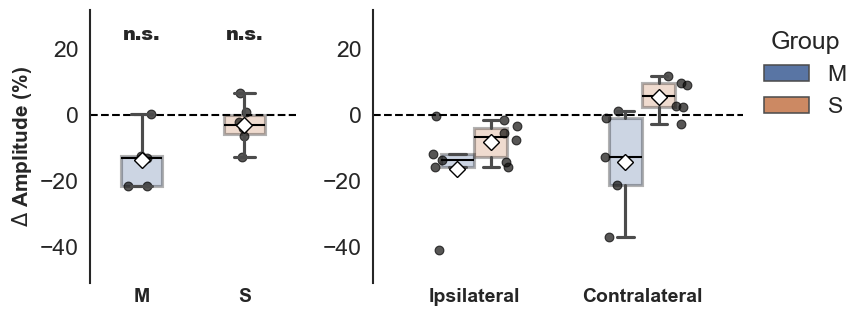

In [312]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import utils

# ----------------------------------------------------
# הגדרות בסיס
# ----------------------------------------------------
base_path = r"D:\Ofer_backup\V6_model"
target_param = "relative_spike_amplitude"

# מיפוי קבוצות לפי התמונה
stim_type_map = {
    '485': 'M',
    '486': 'S',
    '487': 'S',
    '488': 'S',
    '497': 'M',
    '498': 'S',
    '499': 'M',
    '505': 'M',
    '5107': 'M',
    '515': 'S',
    '520': 'S',
    '545': 's',
}

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

def compute_pct_change_pause_vs_stim(data, index_cols, feats):
    cond_order = ["pause_block", "stimuli_block"]
    data_ps = data[data["stimuli_flag"].isin(cond_order)].copy()
    data_ps = data_ps.groupby(index_cols + ["stimuli_flag"])[feats].mean().reset_index()
    df_pivot = data_ps.pivot(index=index_cols, columns="stimuli_flag", values=feats)

    pct_change_df = pd.DataFrame(index=df_pivot.index)

    for feat in feats:
        val_pause = df_pivot[(feat, "pause_block")]
        val_stim  = df_pivot[(feat, "stimuli_block")]

        ok = val_pause.notna() & (val_pause != 0) & val_stim.notna()
        pct_change_df.loc[ok, feat] = ((val_stim[ok] - val_pause[ok]) / val_pause[ok]) * 100

    return pct_change_df.melt(
        var_name="Parameter",
        value_name="Percent_Change",
        ignore_index=False
    ).reset_index()

# ----------------------------------------------------
# 1. עיבוד נתונים
# ----------------------------------------------------
all_data_lat, all_data_all = [], []

subject_ids_to_run = [x for x in subjects if x not in ['5101','541', '544']]

for subj in subject_ids_to_run:
    feat_path = os.path.join(
        base_path,
        f"p{subj}",
        "unichannel_model",
        "min_amplitude_1",
        "features",
        f"p{subj}_flat_features.csv"
    )
    if not os.path.exists(feat_path):
        continue

    df = pd.read_csv(feat_path)
    df = df.drop_duplicates(subset="group", keep="first")

    ann_path = fr"D:\Maya\clean Stim Project\P{subj}\P{subj}_annotations_ms.csv"
    try:
        df = utils.remove_noisy_samples_and_channels(
            subj, df, ann_path,
            ts_col="timestamp",
            channel_col="channel"
        )
    except:
        continue

    df["subject_id"] = str(subj)

    stim = stim_side.get(str(subj))
    df["chan_side"] = df["channel"].astype(str).str[0]

    df_lat = df[df["chan_side"].isin(["R", "L"])].copy()

    if stim:
        df_lat["lat_group"] = np.where(
            df_lat["chan_side"] == stim,
            "ipsi", "contra"
        )

        all_data_lat.append(
            df_lat.groupby(
                ["subject_id", "stimuli_flag", "lat_group"],
                as_index=False
            )[[target_param]].mean()
        )

        all_data_all.append(
            df_lat.groupby(
                ["subject_id", "stimuli_flag"],
                as_index=False
            )[[target_param]].mean()
        )

df_plot_lat = compute_pct_change_pause_vs_stim(
    pd.concat(all_data_lat),
    ["subject_id", "lat_group"],
    [target_param]
)

df_plot_all = compute_pct_change_pause_vs_stim(
    pd.concat(all_data_all),
    ["subject_id"],
    [target_param]
)

# הוספת קבוצות M/S
df_plot_all["stim_type"] = df_plot_all["subject_id"].map(stim_type_map)
df_plot_lat["stim_type"] = df_plot_lat["subject_id"].map(stim_type_map)

# ----------------------------------------------------
# 2. ויזואליזציה
# ----------------------------------------------------
sns.set(style="white", context="talk")

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(9, 3.5),
    gridspec_kw={'width_ratios': [1, 1.8]}
)

min_y = min(df_plot_all["Percent_Change"].min(), df_plot_lat["Percent_Change"].min()) - 10
max_y = max(df_plot_all["Percent_Change"].max(), df_plot_lat["Percent_Change"].max()) + 20

box_style = dict(
    width=0.4,
    color="lightgray",
    showmeans=True,
    showfliers=False,
    zorder=2,
    meanprops={"marker":"D","markerfacecolor":"white","markeredgecolor":"black","markersize":8},
    boxprops=dict(alpha=0.3, edgecolor="black"),
    medianprops=dict(color="black", linewidth=1.5)
)

palette = {"M": "#4C72B0", "S": "#DD8452"}

# --- גרף שמאל ---
ax1.axhline(0, color="black", linestyle="--", linewidth=1.5)

sns.boxplot(
    data=df_plot_all,
    x="stim_type",
    y="Percent_Change",
    order=["M", "S"],
    palette=palette,
    ax=ax1,
    **box_style
)

for i, grp in enumerate(["M", "S"]):
    vals = df_plot_all[df_plot_all["stim_type"] == grp]["Percent_Change"].dropna()
    ax1.scatter(
        np.random.default_rng(6+i).normal(i, 0.05, size=len(vals)),
        vals,
        s=40, c="#100f0d", alpha=0.7,
        edgecolors="black", linewidths=0.8
    )

    if len(vals) > 0:
        _, p = wilcoxon(vals)
        ax1.text(i, max_y - 5, p_to_stars(p),
                 ha="center", va="top", fontsize=14, fontweight='heavy')

ax1.set_xticklabels(["M", "S"], fontsize=14, fontweight='bold')

# --- גרף ימין ---
ax2.axhline(0, color="black", linestyle="--", linewidth=1.5)

sns.boxplot(
    data=df_plot_lat,
    x="lat_group",
    y="Percent_Change",
    hue="stim_type",
    order=["ipsi", "contra"],
    hue_order=["M", "S"],
    palette=palette,
    ax=ax2,
    **box_style
)

for i, lat in enumerate(["ipsi", "contra"]):
    for j, stim in enumerate(["M", "S"]):
        vals = df_plot_lat[
            (df_plot_lat["lat_group"] == lat) &
            (df_plot_lat["stim_type"] == stim)
        ]["Percent_Change"].dropna().values

        if len(vals) == 0:
            continue

        x_pos = i + (-0.2 if stim == "M" else 0.2)

        ax2.scatter(
            np.random.default_rng(10+i+j).normal(x_pos, 0.04, size=len(vals)),
            vals,
            s=40, c="#100f0d", alpha=0.7,
            edgecolors="black", linewidths=0.8
        )

ax2.set_xticklabels(["Ipsilateral", "Contralateral"], fontsize=14, fontweight='bold')

# --- עיצוב ---
for ax_obj in [ax1, ax2]:
    ax_obj.set_ylim(min_y, max_y)
    ax_obj.set_xlabel("")
    ax_obj.set_ylabel("")
    for spine in ['top', 'right', 'bottom']:
        ax_obj.spines[spine].set_visible(False)
    ax_obj.spines['left'].set_linewidth(1.5)

    ax_obj.tick_params(axis='y', which='major', direction='out', length=5, width=1.5)
    ax_obj.tick_params(axis='x', which='major', length=0)

ax1.set_ylabel("$\Delta$ Amplitude (%)", fontsize=15, fontweight='bold')
ax2.legend(title="Group", frameon=False, bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import mne


# ─────────────────────────────────────────────────────────────
# 1.  פונקציה מחודשת – מחזירה df נקי + dict סטטיסטיקות
# ─────────────────────────────────────────────────────────────
def remove_noisy_samples_and_channels(
    subject_id,
    df_features,
    annotations_path,
    recording_duration_sec,          # ← חדש: משך ההקלטה הכולל בשניות
    ts_col="onset_ms",
    channel_col="channel",
    bad_channels_dir=r"D:\Ofer_backup\bad_channels",
):
    """
    מסנן דגימות ועלויות רועשות ומחזיר:
        cleaned_df  – ה-DataFrame לאחר סינון
        stats       – dict עם נתוני דחייה לטבלת סיכום
    """
    df = df_features.copy()
    all_channels = df[channel_col].astype(str).unique()
    n_total_channels = len(all_channels)

    noisy_mask        = np.zeros(len(df), dtype=bool)
    bad_channel_names = set()

    # ── אנוטציות ──────────────────────────────────────────────
    rejected_seconds_annot = 0.0   # נצבור כאן את טווחי הזמן שנדחו

    if annotations_path is not None and os.path.exists(annotations_path):
        if annotations_path.lower().endswith('.fif'):
            raw_info = mne.io.read_raw_fif(annotations_path, preload=False)
            ann = pd.DataFrame({
                "onset":       raw_info.annotations.onset * 1000.0,
                "duration":    raw_info.annotations.duration,
                "description": raw_info.annotations.description,
            })
        else:
            ann = pd.read_csv(annotations_path)
            ann["onset"] = ann["onset"].astype(float)

        ann["start_ms"] = ann["onset"]
        ann["end_ms"]   = ann["start_ms"] + ann["duration"].astype(float) * 1000.0
        channels        = df[channel_col].astype(str).unique()

        for _, row in ann.iterrows():
            start = row["start_ms"]
            end   = row["end_ms"]
            descr = str(row["description"])

            if descr in channels:
                mask = (
                    (df[channel_col].astype(str) == descr) &
                    (df[ts_col] >= start) &
                    (df[ts_col] < end)
                )
            else:
                mask = (df[ts_col] >= start) & (df[ts_col] < end)

            noisy_mask |= mask

        # ── חישוב שניות שנדחו: מאחדים טווחים חופפים ──────────
        # (מתייחסים לאנוטציות גלובליות בלבד, כי channel-specific
        #  אינן בהכרח מכסות את כל הזמן)
        global_ann = ann[~ann["description"].isin(channels)].copy()
        if not global_ann.empty:
            intervals = global_ann[["start_ms", "end_ms"]].values
            intervals = intervals[intervals[:, 0].argsort()]
            merged = []
            cur_start, cur_end = intervals[0]
            for s, e in intervals[1:]:
                if s <= cur_end:
                    cur_end = max(cur_end, e)
                else:
                    merged.append((cur_start, cur_end))
                    cur_start, cur_end = s, e
            merged.append((cur_start, cur_end))
            rejected_seconds_annot = sum((e - s) for s, e in merged) / 1000.0

    elif annotations_path is not None:
        print(f"Warning: annotations file not found: {annotations_path}")

    # ── ערוצים רועשים ─────────────────────────────────────────
    if bad_channels_dir is not None and subject_id is not None:
        bad_channels_path = os.path.join(
            bad_channels_dir, f"p{subject_id}_bad_channels.txt"
        )
        if os.path.exists(bad_channels_path):
            with open(bad_channels_path, "r", encoding="utf-8") as f:
                bad_channel_names = {
                    line.strip() for line in f if line.strip()
                }
            if bad_channel_names:
                bad_mask    = df[channel_col].astype(str).isin(bad_channel_names)
                noisy_mask |= bad_mask
        else:
            print(f"Warning: bad-channels file not found: {bad_channels_path}")

    # ── החלת המסכה ────────────────────────────────────────────
    cleaned = df.loc[~noisy_mask].copy()

    # ── חישוב סטטיסטיקות ─────────────────────────────────────
    n_bad_channels     = len(bad_channel_names & set(all_channels))
    pct_bad_channels   = 100.0 * n_bad_channels / n_total_channels if n_total_channels > 0 else 0.0
    pct_time_rejected  = 100.0 * rejected_seconds_annot / recording_duration_sec if recording_duration_sec > 0 else 0.0

    stats = {
        "subject_id":            subject_id,
        "recording_duration_sec": recording_duration_sec,
        "rejected_seconds":      round(rejected_seconds_annot, 2),
        "rejected_time_pct":     round(pct_time_rejected, 2),
        "n_total_channels":      n_total_channels,
        "n_bad_channels":        n_bad_channels,
        "bad_channels_pct":      round(pct_bad_channels, 2),
        "bad_channel_names":     sorted(bad_channel_names & set(all_channels)),
    }

    return cleaned, stats


# ─────────────────────────────────────────────────────────────
# 2.  פונקציה עזר – טעינת משך ההקלטה מקובץ FIF
# ─────────────────────────────────────────────────────────────
def get_recording_duration_sec(fif_path):
    """מחזיר את משך ההקלטה בשניות מקובץ FIF."""
    raw = mne.io.read_raw_fif(fif_path, preload=False)
    return raw.times[-1]   # הזמן של הדגימה האחרונה


# ─────────────────────────────────────────────────────────────
# 3.  לולאה על שתי הקבוצות → טבלת סיכום
# ─────────────────────────────────────────────────────────────
all_stats = []

# ── קבוצת גירוי ───────────────────────────────────────────────
for subj in stim_subject_ids:
    feat_path = os.path.join(
        base_path, f"p{subj}", "unichannel_model", "min_amplitude_1",
        "features", f"p{subj}_flat_features.csv"
    )
    if not os.path.exists(feat_path):
        print(f"Missing feature file for subject {subj}")
        continue

    df = pd.read_csv(feat_path)
    cols = ["stimuli_flag", "hypnogram_flag", "channel", "group", timestamp_col] + features
    df = df[cols].copy()
    df = df[df["hypnogram_flag"] == "nrem"]
    df = df.drop_duplicates(subset="group", keep="first")

    ann_path = fr"D:\Maya\clean Stim Project\P{subj}\P{subj}_annotations_ms.csv"

    # ← טען את משך ההקלטה בדרך המתאימה לך, למשל:
    # rec_dur = get_recording_duration_sec(fr"D:\Maya\...\P{subj}_raw.fif")
    rec_dur = YOUR_DURATION_LOOKUP[subj]   # dict / פונקציה לפי הצורך

    df, stats = utils.remove_noisy_samples_and_channels(
        subj, df, ann_path,
        recording_duration_sec=rec_dur,
        ts_col="timestamp", channel_col="channel"
    )
    stats["group"] = "stim"
    all_stats.append(stats)

# ── קבוצת קונטרול ─────────────────────────────────────────────
for subj in control_subject_ids:
    feat_path = feat_path_template % (subj, subj)
    if not os.path.exists(feat_path):
        print(f"Missing feature file for subject {subj}")
        continue

    df = pd.read_csv(feat_path)
    cols = ["timestamp", "channel", "amplitude", "duration", "group",
            "group_event_duration", "group_event_size", "group_event_deepest",
            "group_event_shallowest", "group_event_spatial_spread",
            "stimuli_flag", "hypnogram_flag", "angle",
            "relative_spike_amplitude", "relative_spike_duration"]
    df = df[cols].copy()
    df = df.drop_duplicates(subset=["group"], keep="first")

    ann_path = fr"D:\UCLA\{subj}_clean_mtl_annot.fif"
    if subj == '405':
        ann_path = fr"D:\UCLA\{subj}_clean_mtl_annot_cropped.fif"

    rec_dur = get_recording_duration_sec(ann_path)  # FIF → ישירות

    df, stats = utils.remove_noisy_samples_and_channels(
        subj, df, ann_path,
        recording_duration_sec=rec_dur,
        ts_col="timestamp", channel_col="channel"
    )
    stats["group"] = "control"
    all_stats.append(stats)

# ── בניית טבלת סיכום ─────────────────────────────────────────
summary_df = pd.DataFrame(all_stats)[[
    "group", "subject_id",
    "recording_duration_sec",
    "rejected_seconds", "rejected_time_pct",
    "n_total_channels", "n_bad_channels", "bad_channels_pct",
    "bad_channel_names",
]]
summary_df = summary_df.sort_values(["group", "subject_id"]).reset_index(drop=True)

print(summary_df.to_string(index=False))
# summary_df.to_csv("rejection_summary.csv", index=False)  # לשמירה

## old

# time-related analysis

In [7]:
import pandas as pd
import numpy as np

summary_data = []

# Process all subjects in your run
for subj in curr_run_subjects:
    # 1. Get Epochs
    if is_control:
        _, _, stim_epochs = utils.get_nrem_epochs(utils.control_stim[subj])
    else:
        _, _, stim_epochs = utils.get_nrem_epochs(subj)
    
    # 2. Number of stimulation sessions
    num_sessions = len(stim_epochs)
    
    # 3. Total time: (Last End + 5 min) - First Start
    first_stim_start = stim_epochs[0][0]
    last_stim_end = stim_epochs[-1][1]
    total_time_min = ((last_stim_end - first_stim_start) + (5 * 60)) / 60
    avg_session_time = total_time_min / num_sessions 

    # 4. Baseline (Handle the excluded subjects)
    # If the subject was 515 or 545, we don't have a 'natural' baseline recorded in your 'baselines' list
    # We can flag it as NaN so it doesn't break the Mean/Std calculations
    if subj in ['515', '545']:
        subj_baseline = np.nan
    else:
        # We need to find the index in the original 'valid_subjects' list to match 'baselines'
        valid_subs = [x for x in curr_run_subjects if x not in ['515', '545']]
        if subj in valid_subs:
            idx = valid_subs.index(subj)
            subj_baseline = baselines[idx]
        else:
            subj_baseline = np.nan

    summary_data.append({
        'Subject': subj,
        'Baseline_Min': subj_baseline,
        'Num_Sessions': num_sessions,
        'Total_Stim_to_After_Min': total_time_min,
        'Avg_Session_Time_Min': avg_session_time
    })

df_summary = pd.DataFrame(summary_data)

# Calculate stats - .mean() and .std() automatically ignore NaN values
stats = df_summary[['Baseline_Min', 'Num_Sessions', 'Total_Stim_to_After_Min', 'Avg_Session_Time_Min']].agg(['min', 'max', 'mean', 'std']).T

print("--- Per Patient Information (Including 515/545) ---")
print(df_summary)
print("\n--- Aggregate Statistics ---")
print(stats)

--- Per Patient Information (Including 515/545) ---
   Subject  Baseline_Min  Num_Sessions  Total_Stim_to_After_Min  \
0      485     52.176783             4                52.229033   
1      486     43.615217             4                72.061550   
2      487     14.987617             6               114.767500   
3      488     77.243933             7                91.789450   
4      497     16.927700            15               186.056650   
5      498     35.634867            12               134.968867   
6      499      5.871083             8                89.187333   
7      505    106.095467             5                50.051517   
8     5107    119.586633             5                50.146767   
9      515           NaN             6               102.752067   
10     520      9.072658             4                39.901842   
11     545           NaN             5                51.027383   

    Avg_Session_Time_Min  
0              13.057258  
1              18.0153

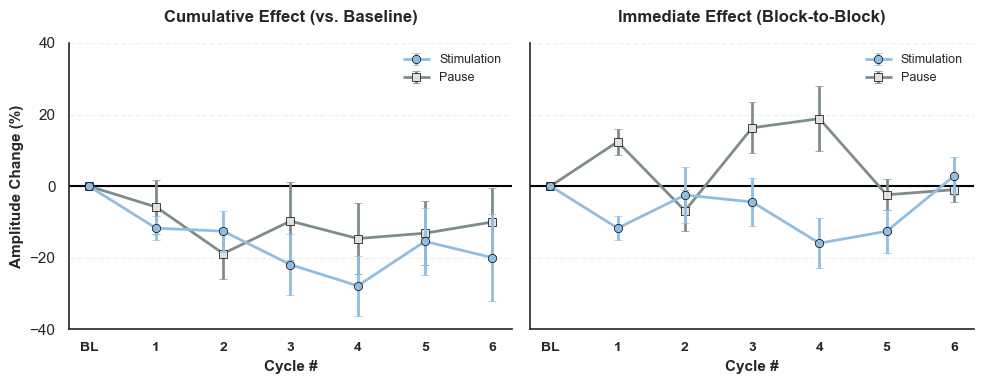

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# --- עיבוד נתונים ---
# (בהנחה ש-mean_cum, mean_imm וכו' כבר קיימים מהשלב הקודם)

# הגדרת אינדקסים (S1=1, P1=2, S2=3, P2=4...)
stim_idx = [i for i in range(1, len(mean_cum)) if i % 2 != 0]
pause_idx = [i for i in range(2, len(mean_cum)) if i % 2 == 0]

# ציר X המשותף (0 ל-Baseline, ואז 1, 2, 3...)
x_axis = np.arange(len(stim_idx) + 1) 

# --- פונקציית עזר לבניית מערך שמתחיל ב-0 ---
def prepare_line(mean_series, sem_series, indices):
    y = [0] + mean_series.iloc[indices].tolist()
    err = [0] + sem_series.iloc[indices].tolist()
    return y, err

# --- יצירת הפיגורה ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# הגדרות צבעים וסטייל (כחול לגירוי, אפור להפסקה)
stim_color = '#91bde1'  # הכחול מהרקע המקורי
pause_color = '#e0e0e0' # האפור מהרקע המקורי

stim_style = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
pause_style = {'fmt': '-s', 'color': '#7f8c8d', 'ecolor': '#7f8c8d', 'capsize': 3, 
               'markersize': 6, 'linewidth': 2, 'markerfacecolor': pause_color, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

titles = ['Cumulative Effect (vs. Baseline)', 'Immediate Effect (Block-to-Block)']
datasets = [(mean_cum, sem_cum), (mean_imm, sem_imm)]

for i, ax in enumerate(axes):
    m_data, s_data = datasets[i]
    
    # הכנת נתוני הקווים (חיבור נקודת ה-0)
    y_stim, err_stim = prepare_line(m_data, s_data, stim_idx)
    y_pause, err_pause = prepare_line(m_data, s_data, pause_idx)
    
    # ציור קו גירוי
    ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation', zorder=5, **stim_style)
    
    # ציור קו הפסקה (מוודאים שאם יש פחות הפסקה מגירוי, המערכים יתאימו)
    ax.errorbar(x_axis[:len(y_pause)], y_pause, yerr=err_pause, label='Pause', zorder=4, **pause_style)
    
    # קו אפס שחור ובולט
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)
    
    # עיצוב צירים
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # הגדרות Y
    ax.set_yticks(np.arange(-40, 50, 20))
    ax.set_ylim(-40, 40)
    
    # הגדרות X
    ax.set_xticks(x_axis)
    ax.set_xticklabels(['BL'] + [f'{j}' for j in x_axis[1:]], fontsize=10, fontweight='bold')
    ax.set_xlabel('Cycle #', fontsize=11, fontweight='bold')
    
    ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=15)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Amplitude Change (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Change in Amplitude Between Consecutive Time Windows (%)
Inter-Window Amplitude Change (%)
Relative Amplitude Change (% from Previous Block)
Amplitude Modulation (% Change)
Amplitude Change Following State Transition (%)
Consecutive Block-to-Block Change (%)

In [83]:
import os
import numpy as np
import pandas as pd
import mne
import utils

# הגדרות בסיס
base_path = r"D:\Ofer_backup\V6_model"
PRE_MS, POST_MS = 200, 200
cases = [
    {"subj": "497", "chan": "LEC1"},
    {"subj": "497", "chan": "LA1"}
]

all_results = {} # כאן יישמרו כל הנתונים המוכנים

for case in cases:
    subj_id, ch_name = case["subj"], case["chan"]
    print(f"Processing Subj {subj_id}...")
    
    # טעינת נתיבים
    edf_path = rf"D:\Maya\p{subj_id}\P{subj_id}_fixed.edf"
    features_csv = os.path.join(base_path, f"p{subj_id}", "unichannel_model", "min_amplitude_1", "features", f"p{subj_id}_flat_features.csv")
    clean_annot_path = rf"D:\Maya\clean Stim Project\P{subj_id}\P{subj_id}_annotations_ms.csv"

    # עיבוד DataFrame
    df = pd.read_csv(features_csv)
    # df = df[df["hypnogram_flag"] == "nrem"].copy()
    df = df.drop_duplicates(subset=["group"], keep="first")
    df = utils.remove_noisy_samples_and_channels(subj_id, df, clean_annot_path, ts_col="timestamp", channel_col="channel")
    df_target = df[(df["channel"] == ch_name) & (df["stimuli_flag"].isin(["stimuli_block", "pause_block"]))]

    # קריאת EDF
    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
    fs = raw.info["sfreq"]
    w_len = int((PRE_MS + POST_MS) * fs / 1000)
    
    waveforms = {"stimuli_block": [], "pause_block": []}
    for _, row in df_target.iterrows():
        t_start = (row["timestamp"] - PRE_MS) / 1000
        t_stop = (row["timestamp"] + POST_MS) / 1000
        try:
            wf = raw.get_data(picks=[ch_name], tmin=t_start, tmax=t_stop, return_times=False)
            wf = np.squeeze(wf) * 1e6 # המרה ל-uV
            if len(wf) >= w_len:
                wf_final = wf[:w_len] - np.mean(wf[:int(PRE_MS * fs / 1000)])
                waveforms[row["stimuli_flag"]].append(wf_final)
        except: continue
        
    all_results[f"{subj_id}_{ch_name}"] = {"data": waveforms, "fs": fs}

print("Data is ready for plotting!")

Processing Subj 497...
Processing Subj 497...
Data is ready for plotting!


Case 497_LEC1: Stim Peak=281.90uV, Pause Peak=331.07uV. Difference: 14.9%
Case 497_LA1: Stim Peak=237.73uV, Pause Peak=268.19uV. Difference: 11.4%


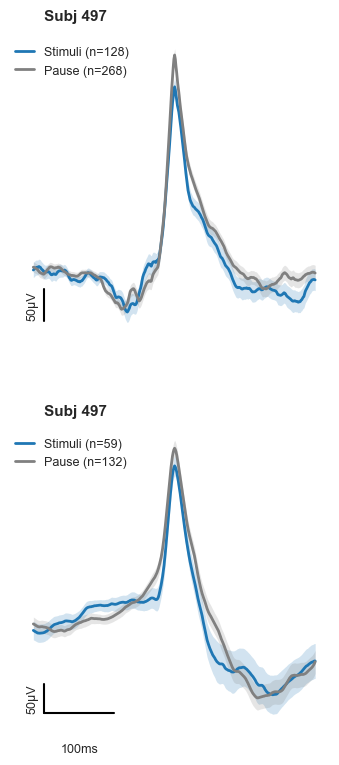

In [87]:
# פרמטרים לציור
SCALE_X = 100        
COLORS = {"stimuli_block": "#1f77b4", "pause_block": "#808080"}
LEGEND_LABELS = {"stimuli_block": "Stimuli", "pause_block": "Pause"}

scale_y_values = [50, 50] 

fig, axes = plt.subplots(2, 1, figsize=(4, 9)) # הגבהתי מעט את הפיגורה ל-9

for i, (key, content) in enumerate(all_results.items()):
    waveforms = content["data"]
    fs = content["fs"]
    ax = axes[i]
    t = np.linspace(-PRE_MS, POST_MS, int((PRE_MS + POST_MS) * fs / 1000))
    current_scale_y = scale_y_values[i]
    
    max_peaks = {} # לאחסון שיאי הגובה
    
    for cond in ["stimuli_block", "pause_block"]:
        wf_list = waveforms[cond]
        if len(wf_list) > 0:
            W = np.vstack(wf_list)
            mean = np.mean(W, axis=0)
            sem = np.std(W, axis=0) / np.sqrt(W.shape[0])
            
            # שמירת שיא הגובה (אבסולוטי) של הממוצע
            max_peaks[cond] = np.max(np.abs(mean))
            
            label_with_n = f"{LEGEND_LABELS[cond]} (n={len(wf_list)})"
            ax.plot(t, mean, color=COLORS[cond], lw=2, label=label_with_n)
            ax.fill_between(t, mean - sem, mean + sem, color=COLORS[cond], alpha=0.2, lw=0)

    # --- חישוב הפרש בשיא הגובה (Peak Amplitude) ---
    if "stimuli_block" in max_peaks and "pause_block" in max_peaks:
        p1, p2 = max_peaks["stimuli_block"], max_peaks["pause_block"]
        pct_diff = abs(p1 - p2) / p2 * 100
        print(f"Case {key}: Stim Peak={p1:.2f}uV, Pause Peak={p2:.2f}uV. Difference: {pct_diff:.1f}%")

    ax.set_axis_off()
    
    # כותרת נבדק - הוספתי pad ויזואלי על ידי העלאת ה-y position
    # ושימוש ב-va='bottom' כדי שיהיה רווח מהסיגנל
    y_max_curr = ax.get_ylim()[1]
    ax.text(-185, y_max_curr * 1.05, f"Subj {key.split('_')[0]}", 
            fontsize=11, fontweight='bold', va='bottom')

    # מקרא - הוספת bbox_to_anchor עם קצת יותר רווח מלמעלה
    ax.legend(loc='upper left', frameon=False, fontsize=9, 
              bbox_to_anchor=(-0.05, 1.0), handlelength=1.5)

    # Scale Bar
    y_min_local, y_max_local = ax.get_ylim()
    y_range = y_max_local - y_min_local
    x_start, y_start = -185, y_min_local + (y_range * 0.05)
    
    ax.plot([x_start, x_start], [y_start, y_start + current_scale_y], color='black', lw=1.5)
    ax.text(x_start - 8, y_start + current_scale_y/2, f'{current_scale_y}µV', 
            ha='right', va='center', rotation=90, fontsize=9)
    
    if i == 1:
        ax.plot([x_start, x_start + SCALE_X], [y_start, y_start], color='black', lw=1.5)
        ax.text(x_start + SCALE_X/2, y_start - (y_range * 0.1), 
                f'{SCALE_X}ms', ha='center', va='top', fontsize=9)

# הגדלת המרווח בין הגרפים כדי למנוע צפיפות בין הכותרת של התחתון ל-Scale Bar של העליון
plt.subplots_adjust(hspace=0.3)
plt.show()

# Rates

Data points per block (after outlier removal):
[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 10]


C:\Users\user\AppData\Local\Temp\ipykernel_44912\2330815547.py:63: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--',


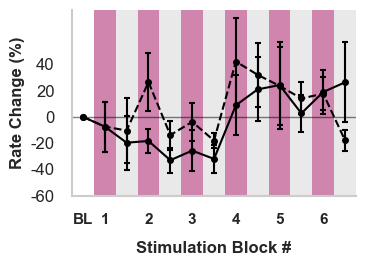

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches

def get_clean_matrix(raw_data_list, mode='baseline', max_points=13, threshold=3):
    all_rows = []
    for subj_rates in raw_data_list:
        subj_rates = np.array(subj_rates)[:max_points]
        if len(subj_rates) < 2: continue
        
        if mode == 'baseline':
            b = subj_rates[0]
            if b == 0: continue
            vals = ((subj_rates - b) / b) * 100
        else: # consecutive
            prev = subj_rates[:-1]
            denom = np.where(prev == 0, 1e-9, prev)
            vals = np.insert(((subj_rates[1:] - prev) / denom) * 100, 0, 0)
        
        padded = np.full(max_points, np.nan)
        padded[:len(vals)] = vals
        all_rows.append(padded)
    
    df_wide = pd.DataFrame(all_rows)
    for col in df_wide.columns[1:]:
        q1, q3 = df_wide[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_wide.loc[(df_wide[col] < q1 - threshold*iqr) | (df_wide[col] > q3 + threshold*iqr), col] = np.nan
    return df_wide

# --- עיבוד נתונים ---
data_list = data_control['rates']['all']  # רשימת רשימות של כל הנבדקים
df_cum = get_clean_matrix(data_list, mode='baseline')   # Cumulative
df_imm = get_clean_matrix(data_list, mode='consecutive') # Immediate

mean_cum = df_cum.mean()
sem_cum = df_cum.sem()
mean_imm = df_imm.mean()
sem_imm = df_imm.sem()
n_counts = df_cum.count() 
print("Data points per block (after outlier removal):")
print(n_counts.tolist())
x_indices = np.arange(len(mean_cum))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(4, 3))

# 1. רקע צבעוני
for j in range(1, len(mean_cum)):
    color = '#bb528c' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.7, linewidth=0)

# 2. הגדרות סטייל זהות
err_style = {'fmt': '-o', 'color': 'black', 'capsize': 2, 'markersize': 4, 
             'linewidth': 1.5, 'elinewidth': 1.5, 'capthick': 1.5}

# ציור הקווים
ax.errorbar(x_indices, mean_cum, yerr=sem_cum, zorder=5, 
            label='Cumulative Effect (vs. BL)', **err_style)

ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--', 
            label='Immediate Effect (Block-to-Block)', **err_style)

# 3. קו אפס
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

# 4. עיצוב צירים ו-Ticks (העדכון שביקשת)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# הגדרת שנתות ציר Y כל 10%
y_ticks = np.arange(-60, 50, 20) # מ-40- עד 40 (כולל) בקפיצות של 10
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks, fontsize=12) # הקטנת פונט מספרים בציר Y
# ax.set_ylim(-45, 40)

# תוויות ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_cum), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_cum), 2)])
ax.set_xticklabels(stim_labels, fontsize=11, fontweight='bold')

ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(mean_cum) - 0.5)
ax.grid(False)

# 5. מקרא (אופציונלי להחזיר אם תרצה)
stim_patch = mpatches.Patch(color='#8db4d3', label='Stimulation Block')
pause_patch = mpatches.Patch(color='#e0e0e0', label='Pause Block')

plt.tight_layout()
plt.show()

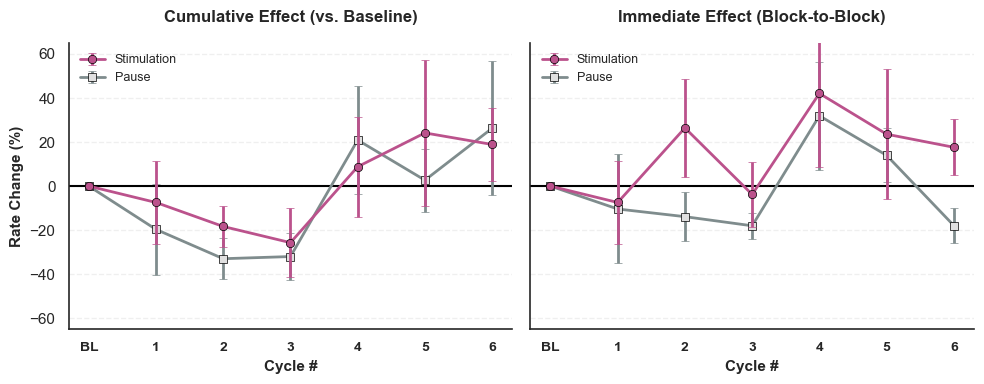

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד הנתונים עבור קצב הירי (Rates) ---
data_list_rates = data_control['rates']['all']
df_cum_rates = get_clean_matrix(data_list_rates, mode='baseline')
df_imm_rates = get_clean_matrix(data_list_rates, mode='consecutive')

mean_cum_r = df_cum_rates.mean()
sem_cum_r = df_cum_rates.sem()
mean_imm_r = df_imm_rates.mean()
sem_imm_r = df_imm_rates.sem()

# הגדרת אינדקסים (S1=1, P1=2, S2=3, P2=4...)
stim_idx = [i for i in range(1, len(mean_cum_r)) if i % 2 != 0]
pause_idx = [i for i in range(2, len(mean_cum_r)) if i % 2 == 0]

# ציר X המשותף (0 ל-Baseline, ואז 1, 2, 3...)
x_axis = np.arange(len(stim_idx) + 1) 

# פונקציית עזר לבניית מערך שמתחיל ב-0
def prepare_line(mean_series, sem_series, indices):
    y = [0] + mean_series.iloc[indices].tolist()
    err = [0] + sem_series.iloc[indices].tolist()
    return y, err

# --- 2. יצירת הפיגורה ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# הגדרות צבעים וסטייל (כחול לגירוי, אפור להפסקה)
stim_color = '#bb528c'  # הכחול מהרקע המקורי
pause_color = '#e0e0e0' # האפור מהרקע המקורי

stim_style = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
pause_style = {'fmt': '-s', 'color': '#7f8c8d', 'ecolor': '#7f8c8d', 'capsize': 3, 
               'markersize': 6, 'linewidth': 2, 'markerfacecolor': pause_color, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

titles = ['Cumulative Effect (vs. Baseline)', 'Immediate Effect (Block-to-Block)']
datasets = [(mean_cum_r, sem_cum_r), (mean_imm_r, sem_imm_r)]

for i, ax in enumerate(axes):
    m_data, s_data = datasets[i]
    
    # הכנת נתוני הקווים (חיבור נקודת ה-0)
    y_stim, err_stim = prepare_line(m_data, s_data, stim_idx)
    y_pause, err_pause = prepare_line(m_data, s_data, pause_idx)
    
    # ציור קו גירוי
    ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation', zorder=5, **stim_style)
    
    # ציור קו הפסקה
    ax.errorbar(x_axis[:len(y_pause)], y_pause, yerr=err_pause, label='Pause', zorder=4, **pause_style)
    
    # קו אפס שחור ובולט
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)
    
    # עיצוב צירים
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # הגדרות Y (ניתן להתאים את הטווח אם קצב הירי משתנה יותר/פחות מאמפליטודה)
    ax.set_yticks(np.arange(-60, 80, 20))
    ax.set_ylim(-65, 65)
    
    # הגדרות X
    ax.set_xticks(x_axis)
    ax.set_xticklabels(['BL'] + [f'{j}' for j in x_axis[1:]], fontsize=10, fontweight='bold')
    ax.set_xlabel('Cycle #', fontsize=11, fontweight='bold')
    
    ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=15)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Rate Change (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

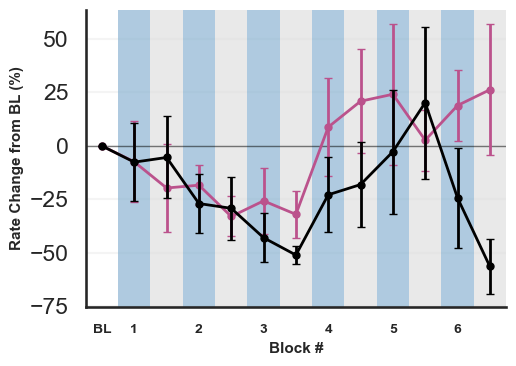

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- עיבוד נתונים (בהנחה שהפונקציה get_clean_matrix הוגדרה קודם) ---
df_stim = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
df_control = get_clean_matrix(data_control['rates']['all'], mode='baseline')

mean_stim = df_stim.mean()
sem_stim = df_stim.sem()
mean_ctrl = df_control.mean()
sem_ctrl = df_control.sem()

x_indices = np.arange(len(mean_stim))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(5.5, 4)) # הגדלתי מעט את הרוחב למקרא

# 1. רקע צבעוני לבלוקים
for j in range(1, len(mean_stim)):
    color = '#8db4d3' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.7, linewidth=0)

# 2. ציור הקווים
# קבוצת הניסוי - כחול עמוק
ax.errorbar(x_indices, mean_stim, yerr=sem_stim, fmt='-o', color='black', 
            capsize=3, markersize=5, linewidth=2, label='Stimulation Group', zorder=5)

# קבוצת הביקורת - ורוד ce84ad
ax.errorbar(x_indices, mean_ctrl, yerr=sem_ctrl, fmt='-o', color='#bb528c', 
            capsize=3, markersize=5, linewidth=2, label='Control Group', zorder=4)

# 3. עיצוב ציר Y
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)
# הגדרה הגיונית לציר Y בהתאם לדאטה (מ-80- עד 60+)
# ax.set_ylim(-60, 40)
# y_ticks = np.arange(-60, 41, 20)
# ax.set_yticks(y_ticks)
# ax.set_yticklabels(y_ticks, fontsize=10)
ax.set_ylabel('Rate Change from BL (%)', fontsize=11, fontweight='bold')

# 4. עיצוב ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_stim), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_stim), 2)])
ax.set_xticklabels(stim_labels, fontsize=10, fontweight='bold')
ax.set_xlabel('Block #', fontsize=11, fontweight='bold')
ax.set_xlim(-0.5, len(mean_stim) - 0.5)

# 5. ניקוי מסגרת
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)

# 6. מקרא - שמאל למעלה
# ax.legend(frameon=True, fontsize=9, loc='upper left', facecolor='white', framealpha=0.8)
plt.tight_layout()
plt.show()

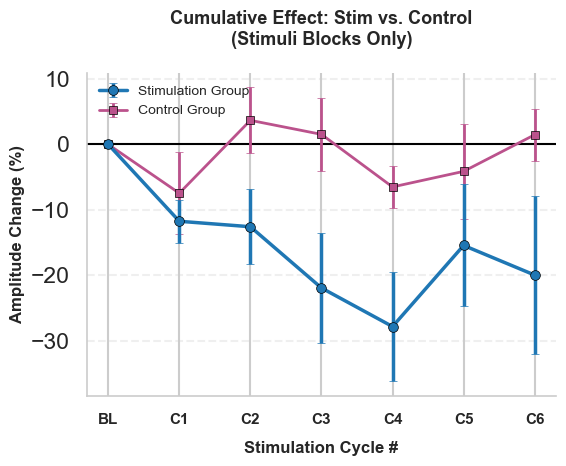

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד נתונים עבור קבוצת הגירוי ---
df_cum_stim = get_clean_matrix(data_stim['relative_spike_amplitude']['all'], mode='baseline')
mean_stim = df_cum_stim.mean()
sem_stim = df_cum_stim.sem()

# --- 2. עיבוד נתונים עבור קבוצת הקונטרול ---
df_cum_ctrl = get_clean_matrix(data_control['relative_spike_amplitude']['all'], mode='baseline')
mean_ctrl = df_cum_ctrl.mean()
sem_ctrl = df_cum_ctrl.sem()

# --- 3. שליפת זמני הגירוי בלבד (אינדקסים 1, 3, 5, 7) ---
stim_idx = [1, 3, 5, 7, 9, 11] # אינדקסים של בלוקי הגירוי בתוך המטריצה

# פונקציה להכנת הקו (הוספת 0 של ה-BL בהתחלה)
def prepare_group_line(mean_s, sem_s, idx_list):
    y = [0] + mean_s.iloc[idx_list].tolist()
    err = [0] + sem_s.iloc[idx_list].tolist()
    return y, err

y_stim, err_stim = prepare_group_line(mean_stim, sem_stim, stim_idx)
y_ctrl, err_ctrl = prepare_group_line(mean_ctrl, sem_ctrl, stim_idx)

# ציר X (BL ואז מחזורים 1 עד 4)
x_axis = np.arange(len(y_stim))

# --- 4. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(6, 5))

# הגדרות סטייל
stim_color = '#1f77b4' # כחול חזק לקבוצת הגירוי
ctrl_color = '#bb528c' # אפור לקבוצת הביקורת

style_stim = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 7, 'linewidth': 2.5, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
style_ctrl = {'fmt': '-s', 'color': ctrl_color, 'ecolor': ctrl_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markerfacecolor': '#bb528c', 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

# ציור הקווים
ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation Group', zorder=5, **style_stim)
ax.errorbar(x_axis, y_ctrl, yerr=err_ctrl, label='Control Group', zorder=4, **style_ctrl)

# קו אפס שחור
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# עיצוב צירים
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# הגדרות Y
ax.set_ylabel('Amplitude Change (%)', fontsize=12, fontweight='bold')

# הגדרות X
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'], fontsize=11, fontweight='bold')
ax.set_xlabel('Stimulation Cycle #', fontsize=12, fontweight='bold', labelpad=10)

ax.set_title('Cumulative Effect: Stim vs. Control\n(Stimuli Blocks Only)', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

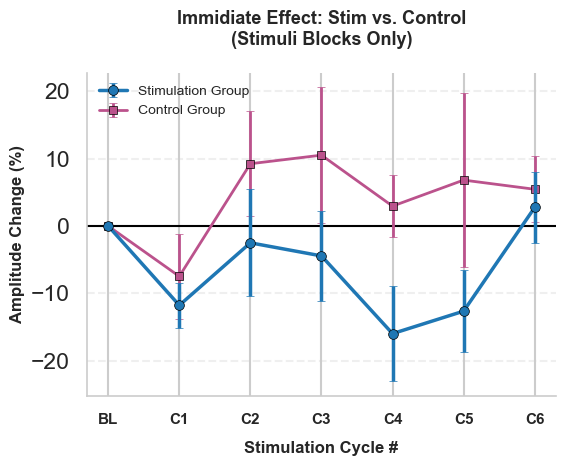

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד נתונים עבור קבוצת הגירוי ---
df_cum_stim = get_clean_matrix(data_stim['relative_spike_amplitude']['all'], mode='consecutive')
mean_stim = df_cum_stim.mean()
sem_stim = df_cum_stim.sem()

# --- 2. עיבוד נתונים עבור קבוצת הקונטרול ---
df_cum_ctrl = get_clean_matrix(data_control['relative_spike_amplitude']['all'], mode='consecutive')
mean_ctrl = df_cum_ctrl.mean()
sem_ctrl = df_cum_ctrl.sem()

# --- 3. שליפת זמני הגירוי בלבד (אינדקסים 1, 3, 5, 7) ---
stim_idx = [1, 3, 5, 7, 9, 11] # אינדקסים של בלוקי הגירוי בתוך המטריצה

# פונקציה להכנת הקו (הוספת 0 של ה-BL בהתחלה)
def prepare_group_line(mean_s, sem_s, idx_list):
    y = [0] + mean_s.iloc[idx_list].tolist()
    err = [0] + sem_s.iloc[idx_list].tolist()
    return y, err

y_stim, err_stim = prepare_group_line(mean_stim, sem_stim, stim_idx)
y_ctrl, err_ctrl = prepare_group_line(mean_ctrl, sem_ctrl, stim_idx)

# ציר X (BL ואז מחזורים 1 עד 4)
x_axis = np.arange(len(y_stim))

# --- 4. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(6, 5))

# הגדרות סטייל
stim_color = '#1f77b4' # כחול חזק לקבוצת הגירוי
ctrl_color = '#bb528c' # אפור לקבוצת הביקורת

style_stim = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 7, 'linewidth': 2.5, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
style_ctrl = {'fmt': '-s', 'color': ctrl_color, 'ecolor': ctrl_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markerfacecolor': '#bb528c', 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

# ציור הקווים
ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation Group', zorder=5, **style_stim)
ax.errorbar(x_axis, y_ctrl, yerr=err_ctrl, label='Control Group', zorder=4, **style_ctrl)

# קו אפס שחור
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# עיצוב צירים
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# הגדרות Y
ax.set_ylabel('Amplitude Change (%)', fontsize=12, fontweight='bold')

# הגדרות X
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'], fontsize=11, fontweight='bold')
ax.set_xlabel('Stimulation Cycle #', fontsize=12, fontweight='bold', labelpad=10)

ax.set_title('Immidiate Effect: Stim vs. Control\n(Stimuli Blocks Only)', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

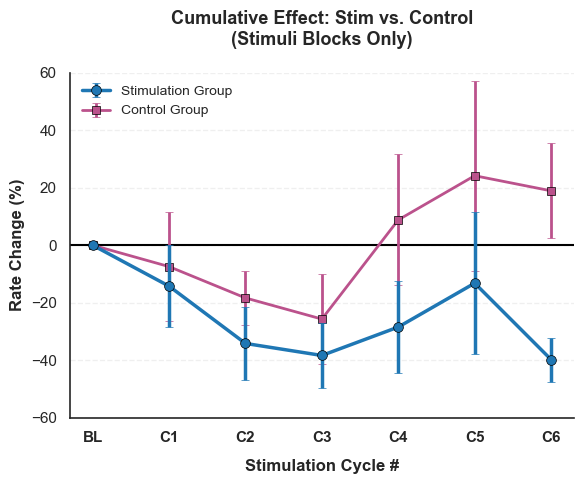

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד נתונים עבור קבוצת הגירוי ---
df_cum_stim = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
mean_stim = df_cum_stim.mean()
sem_stim = df_cum_stim.sem()

# --- 2. עיבוד נתונים עבור קבוצת הקונטרול ---
df_cum_ctrl = get_clean_matrix(data_control['rates']['all'], mode='baseline')
mean_ctrl = df_cum_ctrl.mean()
sem_ctrl = df_cum_ctrl.sem()

# --- 3. שליפת זמני הגירוי בלבד (אינדקסים 1, 3, 5, 7) ---
stim_idx = [1, 3, 5, 7, 9, 11] # אינדקסים של בלוקי הגירוי בתוך המטריצה

# פונקציה להכנת הקו (הוספת 0 של ה-BL בהתחלה)
def prepare_group_line(mean_s, sem_s, idx_list):
    y = [0] + mean_s.iloc[idx_list].tolist()
    err = [0] + sem_s.iloc[idx_list].tolist()
    return y, err

y_stim, err_stim = prepare_group_line(mean_stim, sem_stim, stim_idx)
y_ctrl, err_ctrl = prepare_group_line(mean_ctrl, sem_ctrl, stim_idx)

# ציר X (BL ואז מחזורים 1 עד 4)
x_axis = np.arange(len(y_stim))

# --- 4. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(6, 5))

# הגדרות סטייל
stim_color = '#1f77b4' # כחול חזק לקבוצת הגירוי
ctrl_color = '#bb528c' # אפור לקבוצת הביקורת

style_stim = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 7, 'linewidth': 2.5, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
style_ctrl = {'fmt': '-s', 'color': ctrl_color, 'ecolor': ctrl_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markerfacecolor': '#bb528c', 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

# ציור הקווים
ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation Group', zorder=5, **style_stim)
ax.errorbar(x_axis, y_ctrl, yerr=err_ctrl, label='Control Group', zorder=4, **style_ctrl)

# קו אפס שחור
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# עיצוב צירים
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# הגדרות Y
ax.set_yticks(np.arange(-60, 80, 20))
ax.set_ylim(-60, 60)
ax.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')

# הגדרות X
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'], fontsize=11, fontweight='bold')
ax.set_xlabel('Stimulation Cycle #', fontsize=12, fontweight='bold', labelpad=10)

ax.set_title('Cumulative Effect: Stim vs. Control\n(Stimuli Blocks Only)', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

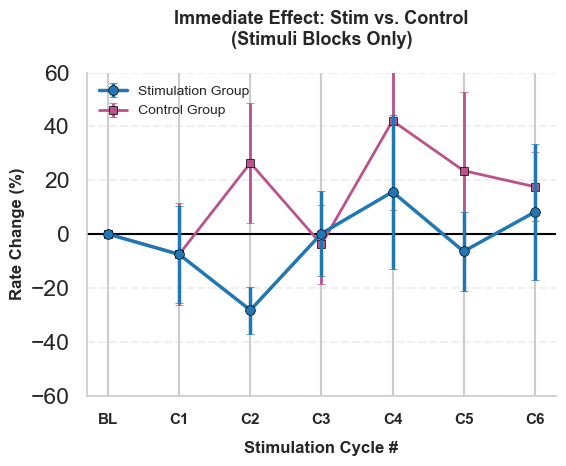

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד נתונים עבור קבוצת הגירוי ---
df_cum_stim = get_clean_matrix(data_stim['rates']['all'], mode='consecutive')
mean_stim = df_cum_stim.mean()
sem_stim = df_cum_stim.sem()

# --- 2. עיבוד נתונים עבור קבוצת הקונטרול ---
df_cum_ctrl = get_clean_matrix(data_control['rates']['all'], mode='consecutive')
mean_ctrl = df_cum_ctrl.mean()
sem_ctrl = df_cum_ctrl.sem()

# --- 3. שליפת זמני הגירוי בלבד (אינדקסים 1, 3, 5, 7) ---
stim_idx = [1, 3, 5, 7, 9, 11] # אינדקסים של בלוקי הגירוי בתוך המטריצה

# פונקציה להכנת הקו (הוספת 0 של ה-BL בהתחלה)
def prepare_group_line(mean_s, sem_s, idx_list):
    y = [0] + mean_s.iloc[idx_list].tolist()
    err = [0] + sem_s.iloc[idx_list].tolist()
    return y, err

y_stim, err_stim = prepare_group_line(mean_stim, sem_stim, stim_idx)
y_ctrl, err_ctrl = prepare_group_line(mean_ctrl, sem_ctrl, stim_idx)

# ציר X (BL ואז מחזורים 1 עד 4)
x_axis = np.arange(len(y_stim))

# --- 4. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(6, 5))

# הגדרות סטייל
stim_color = '#1f77b4' # כחול חזק לקבוצת הגירוי
ctrl_color = '#bb528c' # אפור לקבוצת הביקורת

style_stim = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 7, 'linewidth': 2.5, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
style_ctrl = {'fmt': '-s', 'color': ctrl_color, 'ecolor': ctrl_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markerfacecolor': '#bb528c', 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

# ציור הקווים
ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation Group', zorder=5, **style_stim)
ax.errorbar(x_axis, y_ctrl, yerr=err_ctrl, label='Control Group', zorder=4, **style_ctrl)

# קו אפס שחור
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# עיצוב צירים
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# הגדרות Y
ax.set_yticks(np.arange(-60, 80, 20))
ax.set_ylim(-60, 60)
ax.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')

# הגדרות X
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'], fontsize=11, fontweight='bold')
ax.set_xlabel('Stimulation Cycle #', fontsize=12, fontweight='bold', labelpad=10)

ax.set_title('Immediate Effect: Stim vs. Control\n(Stimuli Blocks Only)', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
for subj_idx, subj in enumerate(subject_ids):
    print(f"  {subj}: {data_stim['rates']['all'][subj_idx][0]:.2f} spikes/min")


  485: 12.61 spikes/min
  486: 6.17 spikes/min
  487: 8.14 spikes/min
  488: 18.94 spikes/min
  497: 5.14 spikes/min
  498: 1.48 spikes/min
  499: 24.58 spikes/min
  505: 15.43 spikes/min
  5107: 2.21 spikes/min
  515: 9.53 spikes/min
  520: 0.67 spikes/min
  545: 24.91 spikes/min


In [44]:
for subj_idx, subj in enumerate(controls):
    print(f"  {subj}: {data_control['rates']['all'][subj_idx][0]:.2f} spikes/min")


  394: 26.06 spikes/min
  396: 4.90 spikes/min
  398: 5.02 spikes/min
  402: 1.65 spikes/min
  404: 0.93 spikes/min
  406: 2.83 spikes/min
  415: 8.42 spikes/min
  416: 1.79 spikes/min
  417: 22.74 spikes/min
  423: 4.82 spikes/min
